### From fimo results to per variant identification of TFBS
- FIMO.tsv => correct names => element metadata 
- FIMO corrected names => variant table 
- Variant overlapping results
- PLOT1: for all variants / for significant variants: proprotion of at least one TFBS overlapping a variant

In [2]:
import pandas as pd
import numpy as np
import yaml
import os
from collections import defaultdict
from importlib import reload
import math # check for nan
import matplotlib.pyplot as plt # plt.show()

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
reload(hf)
# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()


col_name = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class' # SNV
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'

write_unified_variant_map_again = False
write_output = False

In [3]:
# helpful functions
import ast

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x

### FIMO.tsv => correct names => variant metadata

In [4]:
input_elements = "element_metadata_with_bcalm_2025_02_bbmap_scrambled"
input_elements = "NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled"
input_elements_path = "NGN2_element_metadata_with_bcalm_2025_04_normalized_counts_bbmap_vs_scrambled.tsv.gz"
input_elements_path = config['files']['creating'][input_elements]
# use results of bbmap
element_bcalm_metadata_df = pd.read_csv(input_elements_path, low_memory=False, sep="\t")

# list columns col_variant_class, col_variant_pos, col_SPDI, col_allele
list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

# Apply the safe_eval function to the specified columns
for col in list_columns:
    element_bcalm_metadata_df[col] = element_bcalm_metadata_df[col].apply(safe_eval)

element_bcalm_metadata_df = element_bcalm_metadata_df.loc[element_bcalm_metadata_df[col_name].str.contains("cardiac_neuro_cava_random")]
element_bcalm_metadata_df

# start end to int
element_bcalm_metadata_df[col_start] = element_bcalm_metadata_df[col_start].astype(int)
element_bcalm_metadata_df[col_end] = element_bcalm_metadata_df[col_end].astype(int)

element_bcalm_metadata_df

,name,sequence,category,class,source,ref,chr,start,end,strand,...,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl
2287,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843,2182113,+,...,None,None,NaN,1.000000,-0.074506,True,cardiac_neuro_cava_random,-0.074506,0.255056,-1.534950
2288,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439,2182709,+,...,None,None,NaN,1.000000,0.024747,True,cardiac_neuro_cava_random,0.024747,3.065142,1.031757
2289,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830,2183100,+,...,None,None,NaN,1.000000,0.058800,True,cardiac_neuro_cava_random,0.058800,4.029274,1.912386
2290,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027,2185297,+,...,None,None,NaN,1.000000,-0.071544,True,cardiac_neuro_cava_random,-0.071544,0.338923,-1.458346
2291,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389,2188659,+,...,None,None,NaN,1.000000,-0.044408,True,cardiac_neuro_cava_random,-0.044408,1.107215,-0.756596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76222,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000,154545270,-,...,[NC_000023.11:154545205:A:G],[alt],NaN,0.451154,0.065547,True,cardiac_neuro_cava_random,0.065547,4.220287,2.086855
76223,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802,154550072,-,...,[NC_000023.11:154549922:T:G],[alt],NaN,0.091747,-0.090558,True,cardiac_neuro_cava_random,-0.090558,-0.199415,-1.950059
76224,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,variant,test,NaN,GRCh38,chrX,154552145,154552415,-,...,[NC_000023.11:154552288:C:T],[alt],NaN,0.436290,0.052674,True,cardiac_neuro_cava_random,0.052674,3.855845,1.753977
76225,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,variant,test,NaN,GRCh38,chrX,154552145,154552415,-,...,[NC_000023.11:154552370:G:A],[alt],NaN,1.000000,0.016824,True,cardiac_neuro_cava_random,0.016824,2.840822,0.826865


In [5]:
element_bcalm_exists_metadata_df = element_bcalm_metadata_df.loc[element_bcalm_metadata_df["bcalm_data_exists"]].copy()
print("Number of elements with BCalm data: ", element_bcalm_exists_metadata_df.shape[0])
print("Number of significant elements (compared to negative controls): ", element_bcalm_exists_metadata_df.loc[element_bcalm_exists_metadata_df['bcalm_element_adjusted_p_value'] < 0.1].shape[0])
print("Fraction of active elements: ", element_bcalm_exists_metadata_df.loc[element_bcalm_exists_metadata_df['bcalm_element_adjusted_p_value'] < 0.1].shape[0]/element_bcalm_exists_metadata_df.shape[0])

Number of elements with BCalm data:  68241
Number of significant elements (compared to negative controls):  4277
Fraction of active elements:  0.06267493149279758


In [6]:
input_variants = "variants_metadata_bcalm_2025_bbmap_scrambled"
input_variants = "NGN2_variants_metadata_bcalm_2025_bbmap_normalized_counts"
input_variants_path = "NGN2_variants_metadata_with_bcalm_2025_02_bbmap_scrambled.tsv.gz"
input_variants_path = config['files']['creating'][input_variants]
variant_bcalm_metadata_df = pd.read_csv(input_variants_path, sep="\t", low_memory=False)
# use results of bbmap
variant_bcalm_metadata_df = variant_bcalm_metadata_df.loc[variant_bcalm_metadata_df['ALT'].str.contains("cardiac_neuro_cava_random")]
# Apply the safe_eval function to the specified columns
variant_bcalm_metadata_df[col_variant_pos] = variant_bcalm_metadata_df[col_variant_pos].apply(safe_eval)

In [7]:
variant_bcalm_metadata_df.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label'],
      dtype='object')

In [8]:
variant_bcalm_exists_metadata_df = variant_bcalm_metadata_df.loc[variant_bcalm_metadata_df["bcalm_variant_effect_data_exists"]].copy()
print("Number of variants with BCalm data: ", variant_bcalm_exists_metadata_df.shape[0])
n_significant_variants = variant_bcalm_exists_metadata_df.loc[variant_bcalm_exists_metadata_df['bcalm_variant_effect_adjusted_p_value'] < 0.1].shape[0]
print("Number of significant variants: ", n_significant_variants)
n_variants = variant_bcalm_exists_metadata_df.shape[0]

Number of variants with BCalm data:  37870
Number of significant variants:  1304


#### Load Fimo results

In [8]:
fimo_input = "/home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_h13_clustered_all_useful_sequences_neuro_ctrls_scrambled_tested/all_neuro_ctrls_scrambled_tested_h13"
fimo_file_name = "subsampled_h13_80k_tested_neuro_ctrl_TFBS_fimo_202504.tsv"
fimo_file_name = "fimo.tsv.gz"
# fimo_result_df_raw = pd.read_csv(os.path.join(fimo_input, fimo_file_name), sep="\t", comment='#', header=None)
# fimo_result_df_raw.columns = column_names
fimo_result_df_raw_element = pd.read_csv(os.path.join(fimo_input, fimo_file_name), sep="\t", comment='#')
column_names_element = ["motif_id", "motif_alt_id", "sequence_name", "fimo_start", "fimo_stop", "fimo_strand", "fimo_score", "fimo_p-value", "fimo_q-value", "fimo_matched_sequence"]
column_names = ["motif_id", "motif_alt_id", "sequence_name", "start", "stop", "strand", "score", "p-value", "q-value", "matched_sequence"]
fimo_result_df_raw_element.columns = column_names_element

KeyboardInterrupt: 

In [ ]:
fimo_result_df_element = fimo_result_df_raw_element[["motif_id", "sequence_name", "fimo_start", "fimo_stop", "fimo_strand", "fimo_score", "fimo_p-value", "fimo_q-value", "fimo_matched_sequence"]].copy()
# fimo_result_df = fimo_result_df_raw[["motif_id", "sequence_name", "start", "stop", "strand", "score", "p-value", "q-value", "matched_sequence"]].copy()

### Get the correct names to the results from fimo using the design file
- NOTE: fimo is in some way interacting with the headers and some sequences can not matched back (not too important because mostly control sequences)

In [ ]:
fimo_design_file = "/home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_h13_clustered_all_useful_sequences_neuro_ctrls_scrambled_tested/80K_tested_neuro_ctrls_scrambled_fimo_input.fa"
fimo_design = hf.fasta_to_dataframe(fimo_design_file, columns=["sequence_name", "sequence"])

# fimo_results_sequence_left = fimo_result_df.merge(fimo_design, on="sequence_name", how="left")
# fimo_results_sequence = fimo_result_df.merge(fimo_design, on="sequence_name", how="inner")
fimo_results_sequence_left = fimo_result_df_element.merge(fimo_design, on="sequence_name", how="left")
fimo_results_sequence = fimo_result_df_element.merge(fimo_design, on="sequence_name", how="inner")

In [ ]:
# all_motifs = fimo_results_sequence[["motif_id"]].drop_duplicates(subset="motif_id").copy()
# all_motifs.to_csv("/home/kisa/coding/80K_MPRA/element_variant_analysis_output/tfbs_analysis/lasso_regression_only_motifs_used.tsv", sep="\t", index=False)

Fimo has changed the sequence names: 

In [ ]:
fimo_results_sequence_left['sequence'].isna().sum() # 4124
not_matchable_sequences = fimo_results_sequence_left.loc[fimo_results_sequence_left['sequence'].isna()].copy()
not_matchable_sequences.head()

KeyboardInterrupt: 

#### Add the correct header

In [12]:
n_unfiltered = fimo_results_sequence.shape[0]
n_unfiltered

7041988

In [ ]:
# fimo_results_sequence = fimo_results_sequence.loc[fimo_results_sequence['q-value'] < q_value_threshold]

In [ ]:
n_filtered = fimo_results_sequence.shape[0] # 1: 0.5: 294463 2: 0.05: 76898

In [ ]:
n_filtered

In [ ]:
n_filtered/n_unfiltered

In [ ]:
element_bcalm_exists_metadata_df

In [ ]:
# we do an inner join because we only care for the elements with a bcalm readout and only tested elements anyway
element_metadata_fimo_results_df = fimo_results_sequence.merge(element_bcalm_exists_metadata_df[[col_name, col_sequence, col_chr, col_start, col_end, col_strand]], on=col_sequence, how="inner")

In [263]:
element_metadata_fimo_results_df

,motif_id,sequence_name,fimo_start,fimo_stop,fimo_strand,fimo_score,fimo_p-value,fimo_q-value,fimo_matched_sequence,sequence,name,chr,start,end,strand
0,ZN441.H13CORE.1.P.C,DOCK7|ENSG00000116641.18|EH38E2815969_rev_tile1-1,1,31,+,59.01020,7.690000e-20,1.660000e-13,TTGAGACGGAGTCTCGCTCTGTCGCCCAGGC,TTGAGACGGAGTCTCGCTCTGTCGCCCAGGCTGGAGTGCAGTGACG...,cardiac_neuro_cava_random:DOCK7|ENSG0000011664...,chr1,62480740,62481010,-
1,ZN441.H13CORE.1.P.C,ALT_NLGN2|ENSG00000169992.10|EH38E3206963_fwd_...,21,51,+,59.01020,7.690000e-20,1.660000e-13,TTGAGACGGAGTCTCGCTCTGTCGCCCAGGC,TTTATTCATTTATTTATTTTTTGAGACGGAGTCTCGCTCTGTCGCC...,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,chr17,7400764,7401034,+
2,ZN441.H13CORE.1.P.C,REF_NLGN2|ENSG00000169992.10|EH38E3206963_fwd_...,21,51,+,59.01020,7.690000e-20,1.660000e-13,TTGAGACGGAGTCTCGCTCTGTCGCCCAGGC,TTTATTCATTTATTTATTTTTTGAGACGGAGTCTCGCTCTGTCGCC...,cardiac_neuro_cava_random:REF_NLGN2|ENSG000001...,chr17,7400764,7401034,+
3,ZN441.H13CORE.1.P.C,REF_HRAS|ENSG00000174775.18|EH38E1513710_rev_t...,8,38,-,59.01020,7.690000e-20,1.660000e-13,TTGAGACGGAGTCTCGCTCTGTCGCCCAGGC,GCACTCAGCCTGGGCGACAGAGCGAGACTCCGTCTCAAAAAAGAAA...,cardiac_neuro_cava_random:REF_HRAS|ENSG0000017...,chr11,582309,582579,-
4,ZN441.H13CORE.1.P.C,ALT_HRAS|ENSG00000174775.18|EH38E1513710_rev_t...,8,38,-,59.01020,7.690000e-20,1.660000e-13,TTGAGACGGAGTCTCGCTCTGTCGCCCAGGC,GCACTCAGCCTGGGCGACAGAGCGAGACTCCGTCTCAAAAAAGAAA...,cardiac_neuro_cava_random:ALT_HRAS|ENSG0000017...,chr11,582309,582579,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5662049,ZFP14.H13CORE.0.P.C,REF_SCN3A|ENSG00000153253.20|EH38E2047845_rev_...,250,267,+,8.33333,1.000000e-04,2.300000e-01,TCCTGCCTTGGCCTCCCA,ATTAAAATGCAACTTTTTTTTTCCTGAGATAGAGTCTCTCTATCGC...,cardiac_neuro_cava_random:REF_SCN3A|ENSG000001...,chr2,165079468,165079738,-
5662050,ZFP14.H13CORE.0.P.C,ALT_SCN3A|ENSG00000153253.20|EH38E2047845_rev_...,250,267,+,8.33333,1.000000e-04,2.300000e-01,TCCTGCCTTGGCCTCCCA,ATTAAAATGCAACTTTTTTTTTCCTGAGATAGAGTCTCTCTATCGC...,cardiac_neuro_cava_random:ALT_SCN3A|ENSG000001...,chr2,165079468,165079738,-
5662051,ZFP14.H13CORE.0.P.C,FBN1|ENSG00000166147.15|EH38E1760204_rev_tile1-1,253,270,+,8.33333,1.000000e-04,2.300000e-01,GGGCTCTTGTCCCCCCAC,TTTTTTCAATAATCTCTTAATTGGTCTCCCTGCTTCTTGGCTTCTC...,cardiac_neuro_cava_random:FBN1|ENSG00000166147...,chr15,48525501,48525771,-
5662052,ZFP14.H13CORE.0.P.C,ALT_PLEKHM2|ENSG00000116786.13|EH38E2788868_fw...,243,260,-,8.33333,1.000000e-04,2.300000e-01,GCCTCCCAGCTCCTTCCT,AGAGAGAAGTGATTTGCCCAAGGCTGGCAAGTGGCAGAGCTGGAAT...,cardiac_neuro_cava_random:ALT_PLEKHM2|ENSG0000...,chr1,15755698,15755968,+


In [ ]:
element_metadata_fimo_results_df[["motelement_metadata_fimo_results_dfif_id"]]

In [1]:
lasso_regression_input_table_path = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/tfbs_analysis/lasso_regression_sequence_motif_table.tsv.gz"


In [266]:
all_motifs = set(element_metadata_fimo_results_df['motif_id'].to_list())
all_motifs
print(len(all_motifs))

652


In [34]:
# Step 1: Count motif occurrences for each sequence_name
# We use groupby on 'sequence_name' and 'motif_id' and then count.
motif_counts = element_metadata_fimo_results_df.groupby(['name', 'motif_id']).size().reset_index(name='count')

# Step 2: Pivot the table to have motif_id as columns
# The index will be 'sequence_name', columns will be 'motif_id', and values will be 'count'.
motif_pivot = motif_counts.pivot_table(
    index='name',
    columns='motif_id',
    values='count',
    fill_value=0  # Fill missing motif counts with 0
)

# Step 3: (Optional but recommended) Merge back relevant sequence information
# Since 'sequence_name' is not unique in the original DataFrame, we need to decide
# how to handle columns like 'sequence', 'name', 'chr', 'start', 'end', 'strand'.
# If you expect these to be consistent for a given 'sequence_name', you can
# drop duplicates based on 'sequence_name' and then merge.
unique_sequence_info = element_metadata_fimo_results_df.drop_duplicates(subset=['name'])[
    ['name', 'chr']
]

# Merge the motif counts with the unique sequence information
final_df = pd.merge(motif_pivot, unique_sequence_info, on='name', how='left')

# Reset the index to make 'sequence_name' a regular column if desired
final_df = final_df.reset_index()

print(final_df)

       index                                               name  \
0          0  cardiac_neuro_cava_random:AARS1|ENSG0000009086...   
1          1  cardiac_neuro_cava_random:AARS1|ENSG0000009086...   
2          2  cardiac_neuro_cava_random:AARS1|ENSG0000009086...   
3          3  cardiac_neuro_cava_random:AARS1|ENSG0000009086...   
4          4  cardiac_neuro_cava_random:AARS1|ENSG0000009086...   
...      ...                                                ...   
68236  68236  cardiac_neuro_cava_random:ZNF462|ENSG000001481...   
68237  68237  cardiac_neuro_cava_random:ZNF462|ENSG000001481...   
68238  68238  cardiac_neuro_cava_random:ZNF462|ENSG000001481...   
68239  68239  cardiac_neuro_cava_random:ZNF462|ENSG000001481...   
68240  68240  cardiac_neuro_cava_random:ZNF462|ENSG000001481...   

       AHR.H13CORE.0.P.B  ALX1.H13CORE.0.SM.B  ANDR.H13CORE.1.S.C  \
0                    0.0                  0.0                 1.0   
1                    0.0                  0.0            

In [35]:
final_df.head()

,index,name,AHR.H13CORE.0.P.B,ALX1.H13CORE.0.SM.B,ANDR.H13CORE.1.S.C,ANDR.H13CORE.2.P.B,AP2A.H13CORE.0.PSM.A,ARNT.H13CORE.0.P.B,ARNT2.H13CORE.0.P.B,ATF1.H13CORE.1.P.B,...,ZSC29.H13CORE.0.P.B,ZSC29.H13CORE.1.M.C,ZSC31.H13CORE.0.P.C,ZSCA1.H13CORE.0.SM.B,ZSCAN12.H13CORE.0.P.B,ZSCAN2.H13CORE.0.PG.A,ZSCAN25.H13CORE.0.PSG.A,ZXDA.H13CORE.0.PSI.A,ZXDC.H13CORE.0.PI.A,chr
0,0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,chr16
1,1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,chr16
2,2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,chr16
3,3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,chr16
4,4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,chr16


In [37]:
element_bcalm_exists_metadata_df.columns


Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl'],
      dtype='object')

In [36]:
final_df_element_readout = final_df.merge(element_bcalm_exists_metadata_df[[col_name, "bcalm_element_log_ratio_activity"]], on="name", how="inner")

In [38]:
final_df_element_readout.shape

(68241, 656)

In [39]:
final_df_element_readout.columns

Index(['index', 'name', 'AHR.H13CORE.0.P.B', 'ALX1.H13CORE.0.SM.B',
       'ANDR.H13CORE.1.S.C', 'ANDR.H13CORE.2.P.B', 'AP2A.H13CORE.0.PSM.A',
       'ARNT.H13CORE.0.P.B', 'ARNT2.H13CORE.0.P.B', 'ATF1.H13CORE.1.P.B',
       ...
       'ZSC29.H13CORE.1.M.C', 'ZSC31.H13CORE.0.P.C', 'ZSCA1.H13CORE.0.SM.B',
       'ZSCAN12.H13CORE.0.P.B', 'ZSCAN2.H13CORE.0.PG.A',
       'ZSCAN25.H13CORE.0.PSG.A', 'ZXDA.H13CORE.0.PSI.A',
       'ZXDC.H13CORE.0.PI.A', 'chr', 'bcalm_element_log_ratio_activity'],
      dtype='object', length=656)

In [ ]:
# final_df_element_readout.to_csv("/home/kisa/coding/80K_MPRA/element_variant_analysis_output/element_fimo_results_202507_motif_hits_per_sequence.tsv.gz", sep="\t", index=False)

### Generate Lasso regression model

In [41]:
# generate chromosome hold out
import numpy as np
import json

# Define the proportion of chromosomes to be held out for the test set
TEST_CHROMOSOME_PROPORTION = 0.2
# Define a random seed for reproducibility
RANDOM_SEED = 42
CHROMOSOME_SPLIT_FILE = os.path.join("/home/kisa/coding/80K_MPRA/element_variant_analysis_output", 'chromosome_split.json')
print("\nGenerating new chromosome split...")
feature_columns = [col for col in final_df_element_readout.columns if col not in
                    ['index', 'chr', 'name']]
X = final_df_element_readout[feature_columns]
y = final_df_element_readout['bcalm_element_log_ratio_activity']
chromosomes = final_df_element_readout['chr'].unique()
# Randomly select chromosomes for the test set
np.random.seed(RANDOM_SEED) # Ensure reproducibility of the shuffle
np.random.shuffle(chromosomes)
num_test_chromosomes = max(1, int(len(chromosomes) * TEST_CHROMOSOME_PROPORTION))
test_chroms = chromosomes[:num_test_chromosomes].tolist() # Convert to list for JSON serialization
train_chroms = chromosomes[num_test_chromosomes:].tolist() # Convert to list

# Save the split to a file for consistency
with open(CHROMOSOME_SPLIT_FILE, 'w') as f:
    json.dump({'train_chroms': train_chroms, 'test_chroms': test_chroms}, f)
print(f"Chromosome split saved to {CHROMOSOME_SPLIT_FILE}")




Generating new chromosome split...
Chromosome split saved to /home/kisa/coding/80K_MPRA/element_variant_analysis_output/chromosome_split.json


In [ ]:
print(f"\nTotal chromosomes: {len(chromosomes)}")
print(f"Chromosomes for training: {len(train_chroms)} - {train_chroms}")
print(f"Chromosomes for testing: {len(test_chroms)} - {test_chroms}")

# Create training and testing sets based on chromosome membership
X_train = X[df['chr'].isin(train_chroms)]
y_train = y[df['chr'].isin(train_chroms)]
X_test = X[df['chr'].isin(test_chroms)]
y_test = y[df['chr'].isin(test_chroms)]

# Ensure the order of indices is preserved for X and y
# This is important if you later need to link predictions back to original rows
X_train = X_train.reindex(df[df['chr'].isin(train_chroms)].index)
y_train = y_train.reindex(df[df['chr'].isin(train_chroms)].index)
X_test = X_test.reindex(df[df['chr'].isin(test_chroms)].index)
y_test = y_test.reindex(df[df['chr'].isin(test_chroms)].index)

print(f"\nTraining set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Test set shape: X={X_test.shape}, y={y_test.shape}")

# --- Feature Scaling ---
# It's important to scale features for Lasso regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier inspection (optional, but good for understanding)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_columns, index=X_test.index)

In [ ]:
# lasso_regression_script.py

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error
import joblib # For saving and loading models
import os # For path manipulation
import json # For saving/loading the chromosome split
from sklearn.linear_model import LassoCV

# --- Configuration ---
# Define the proportion of chromosomes to be held out for the test set
TEST_CHROMOSOME_PROPORTION = 0.2
# Define a random seed for reproducibility
RANDOM_SEED = 42
# Output directory for saving models and results
OUTPUT_DIR = '/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/projects/80K_MPRA/learn_motiv_sequence'
OUTPUT_DIR = '/home/kisa/coding/80K_MPRA/element_variant_analysis_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
# File to save/load the chromosome split to ensure consistency across runs/scripts
CHROMOSOME_SPLIT_FILE = os.path.join(OUTPUT_DIR, 'chromosome_split.json')

# --- Data Loading and Preprocessing Function ---
def load_and_prepare_data(df_path=None, measurement_col='bcalm_element_log_ratio_activity'):
    """
    Loads the DataFrame and prepares it for model training.
    If df_path is None, generates a sample DataFrame.

    Args:
        df_path (str, optional): Path to the input DataFrame CSV. Defaults to None.

    Returns:
        tuple: X_train, X_test, y_train, y_test, scaler, feature_columns
    """
    if df_path:
        # Load your actual DataFrame
        df = pd.read_csv(df_path, sep="\t", low_memory=False)
        print(f"Loaded DataFrame from {df_path} with shape: {df.shape}")
    else:
        raise ValueError("No DataFrame path provided. Please specify a valid path to your DataFrame.")

    # Identify feature columns (motif counts)
    # Assuming motif columns are all columns except 'sequence_name', 'chr', 'start', 'end', 'measurement'
    # You might need to adjust this based on your actual DataFrame structure
    feature_columns = [col for col in df.columns if col not in
                        ['index', 'chr', 'name', 'bcalm_element_log_ratio_activity']]

    if not feature_columns:
        raise ValueError("No motif columns found. Please ensure your DataFrame has motif count columns.")

    X = df[feature_columns]
    y = df[measurement_col]
    chromosomes = df['chr'].unique()

    # --- Chromosome Hold-out Split ---
    # Check if a pre-defined split file exists
    if os.path.exists(CHROMOSOME_SPLIT_FILE):
        print(f"\nLoading chromosome split from {CHROMOSOME_SPLIT_FILE}...")
        with open(CHROMOSOME_SPLIT_FILE, 'r') as f:
            split_data = json.load(f)
            train_chroms = split_data['train_chroms']
            test_chroms = split_data['test_chroms']
    else:
        raise FileNotFoundError(f"Chromosome split file not found: {CHROMOSOME_SPLIT_FILE}. Please generate the split first.")

    print(f"\nTotal chromosomes: {len(chromosomes)}")
    print(f"Chromosomes for training: {len(train_chroms)} - {train_chroms}")
    print(f"Chromosomes for testing: {len(test_chroms)} - {test_chroms}")

    # Create training and testing sets based on chromosome membership
    X_train = X[df['chr'].isin(train_chroms)]
    y_train = y[df['chr'].isin(train_chroms)]
    X_test = X[df['chr'].isin(test_chroms)]
    y_test = y[df['chr'].isin(test_chroms)]

    # Ensure the order of indices is preserved for X and y
    # This is important if you later need to link predictions back to original rows
    X_train = X_train.reindex(df[df['chr'].isin(train_chroms)].index)
    y_train = y_train.reindex(df[df['chr'].isin(train_chroms)].index)
    X_test = X_test.reindex(df[df['chr'].isin(test_chroms)].index)
    y_test = y_test.reindex(df[df['chr'].isin(test_chroms)].index)

    print(f"\nTraining set shape: X={X_train.shape}, y={y_train.shape}")
    print(f"Test set shape: X={X_test.shape}, y={y_test.shape}")

    # --- Feature Scaling ---
    # It's important to scale features for Lasso regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Convert back to DataFrame for easier inspection (optional, but good for understanding)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_columns, index=X_test.index)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, feature_columns

# --- Model Training and Evaluation Function ---
def train_evaluate_lasso(X_train, X_test, y_train, y_test, feature_columns):
    """
    Trains a Lasso Regression model and evaluates its performance.

    Args:
        X_train (pd.DataFrame): Scaled training features.
        X_test (pd.DataFrame): Scaled test features.
        y_train (pd.Series): Training target variable.
        y_test (pd.Series): Test target variable.
        feature_columns (list): List of feature column names.

    Returns:
        sklearn.linear_model.Lasso: Trained Lasso model.
    """
    print("\n--- Training Lasso Regression Model ---")

    # Initialize Lasso Regression model
    # Alpha is the regularization strength. A higher alpha means stronger regularization.
    # You might want to tune this using GridSearchCV if running on a cluster.
    # lasso_model = Lasso(alpha=0.001, random_state=RANDOM_SEED)
    lasso_model = Lasso(alpha=0.00028096, random_state=RANDOM_SEED)
    # lasso_model = LassoCV(cv=5, random_state=RANDOM_SEED, n_jobs=-1).fit(X_train, y_train)

    # print(f"Optimal alpha found by LassoCV: {lasso_model.alpha_}")


    # Train the model
    lasso_model.fit(X_train, y_train)
    print("Lasso model training complete.")

    # Make predictions
    y_train_pred = lasso_model.predict(X_train)
    y_test_pred = lasso_model.predict(X_test)

    # Evaluate the model on training set
    train_r2 = r2_score(y_train, y_train_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    print(f"\nTraining R-squared: {train_r2:.4f}")
    print(f"Training Mean Squared Error: {train_mse:.4f}")

    # Evaluate the model on test set
    test_r2 = r2_score(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    print(f"Test R-squared: {test_r2:.4f}")
    print(f"Test Mean Squared Error: {test_mse:.4f}")

    # Display coefficients (useful for understanding feature importance)
    print("\nLasso Coefficients (after scaling):")
    coefficients = pd.Series(lasso_model.coef_, index=feature_columns)
    print(coefficients[coefficients != 0].sort_values(ascending=False)) # Show non-zero coefficients

    # --- Save Model and Results ---
    model_path = os.path.join(OUTPUT_DIR, 'lasso_model.joblib')
    joblib.dump(lasso_model, model_path)
    print(f"\nLasso model saved to: {model_path}")

    results_path = os.path.join(OUTPUT_DIR, 'lasso_results.txt')
    with open(results_path, 'w') as f:
        f.write(f"Lasso Regression Results:\n")
        f.write(f"Alpha: {lasso_model.alpha}\n")
        f.write(f"Training R-squared: {train_r2:.4f}\n")
        f.write(f"Training Mean Squared Error: {train_mse:.4f}\n")
        f.write(f"Test R-squared: {test_r2:.4f}\n")
        f.write(f"Test Mean Squared Error: {test_mse:.4f}\n")
        f.write("\nNon-zero Coefficients:\n")
        f.write(coefficients[coefficients != 0].sort_values(ascending=False).to_string())
    print(f"Lasso results saved to: {results_path}")

    writing = False
    if writing:
        # Optionally save predictions
        test_predictions_path = os.path.join(OUTPUT_DIR, 'lasso_test_predictions_2507.csv')
        pd.DataFrame({'actual': y_test, 'predicted': y_test_pred}).to_csv(test_predictions_path, index=True)
        print(f"Test predictions saved to: {test_predictions_path}")

    return lasso_model

# --- Main execution block ---
if __name__ == "__main__":
    # Replace 'your_dataframe.csv' with the actual path to your DataFrame
    # If you don't provide a path, a sample DataFrame will be generated.
    # df_path = 'your_dataframe.csv'
    df_path = None # Using sample data for demonstration
    df_path = "/data/cephfs-1/scratch/groups/kircher/MPRA/IGVF_Y1_design/projects/80K_MPRA/learn_motiv_sequence/element_fimo_results_202507_motif_hits_per_sequence.tsv.gz" # Using sample data for demonstration
    df_path = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/element_fimo_results_202507_motif_hits_per_sequence.tsv.gz" # Using sample data for demonstration

    X_train_scaled, X_test_scaled, y_train, y_test, scaler, feature_columns = load_and_prepare_data(df_path)
    trained_lasso_model = train_evaluate_lasso(X_train_scaled, X_test_scaled, y_train, y_test, feature_columns)

    print("\nLasso Regression script finished.")
    print(f"All outputs saved to the '{OUTPUT_DIR}' directory.")

Loaded DataFrame from /home/kisa/coding/80K_MPRA/element_variant_analysis_output/element_fimo_results_202507_motif_hits_per_sequence.tsv.gz with shape: (68241, 656)

Loading chromosome split from /home/kisa/coding/80K_MPRA/element_variant_analysis_output/chromosome_split.json...

Total chromosomes: 23
Chromosomes for training: 19 - ['chr17', 'chr4', 'chr12', 'chr10', 'chr1', 'chr9', 'chr6', 'chr14', 'chr7', 'chr15', 'chr13', 'chr11', 'chr5', 'chr21', 'chr3', 'chrX', 'chr19', 'chr8', 'chr2']
Chromosomes for testing: 4 - ['chr18', 'chr22', 'chr16', 'chr20']

Training set shape: X=(58085, 652), y=(58085,)
Test set shape: X=(10156, 652), y=(10156,)

--- Training Lasso Regression Model ---
Lasso model training complete.

Training R-squared: 0.1281
Training Mean Squared Error: 0.0021
Test R-squared: 0.0791
Test Mean Squared Error: 0.0022

Lasso Coefficients (after scaling):
VEZF1.H13CORE.0.P.C      0.004383
SP1.H13CORE.2.P.B        0.003791
NFYC.H13CORE.0.P.B       0.003341
HNF6.H13CORE.0.PM

In [ ]:
coefficients = pd.Series(trained_lasso_model.coef_, index=feature_columns)

# Filter out zero coefficients (or very close to zero due to floating point precision)
# non-zero threshold: 1e-9
non_zero_threshold = 1e-5
non_zero_threshold = 1e-4
non_zero_threshold = 1e-9
non_zero_coefficients = coefficients[coefficients.abs() > non_zero_threshold] # Using a small threshold
non_zero_coefficients
# 361 tfbs with non-zero coefficients

# add index as column
non_zero_coefficients_df = non_zero_coefficients.reset_index()
non_zero_coefficients_df.columns = ['motif_id', 'coefficient']
# Save the non-zero coefficients to a file
non_zero_coefficients_file = os.path.join("/home/kisa/coding/80K_MPRA/element_variant_analysis_output/tfbs_analysis", 'lasso_regression_a_00028096_non_zero_coefficients.tsv.gz')
# non_zero_coefficients_df.to_csv(non_zero_coefficients_file, sep="\t", index=False)
print(f"Non-zero coefficients saved to: {non_zero_coefficients_file}")

Non-zero coefficients saved to: /home/kisa/coding/80K_MPRA/element_variant_analysis_output/tfbs_analysis/lasso_regression_a_00028096_non_zero_coefficients.tsv.gz


In [241]:
import pandas as pd
non_zero_coefficients_file = os.path.join("/home/kisa/coding/80K_MPRA/element_variant_analysis_output/tfbs_analysis", 'lasso_regression_a_00028096_non_zero_coefficients.tsv.gz')

lasso_model_coefficients = pd.read_csv(non_zero_coefficients_file, sep="\t", low_memory=False)

In [242]:
lasso_model_coefficients

,motif_id,coefficient
0,ANDR.H13CORE.1.S.C,-0.000170
1,ANDR.H13CORE.2.P.B,-0.000116
2,AP2A.H13CORE.0.PSM.A,-0.000027
3,ARNT.H13CORE.0.P.B,-0.000464
4,BARH2.H13CORE.0.SM.B,0.000210
...,...,...
356,ZSC21.H13CORE.0.P.C,-0.000041
357,ZSC22.H13CORE.0.P.C,-0.000146
358,ZSC29.H13CORE.1.M.C,0.000172
359,ZSCA1.H13CORE.0.SM.B,0.001388


In [248]:
lasso_model_coefficients.loc[lasso_model_coefficients["coefficient"] != 0]['coefficient'].sort_values(ascending=False)

160    0.004383
135    0.003791
87     0.003341
54     0.002586
159    0.002147
         ...   
13    -0.001194
130   -0.001252
55    -0.001254
48    -0.001320
191   -0.001572
Name: coefficient, Length: 361, dtype: float64

In [129]:
coefficients[coefficients != 0].sort_values(ascending=False)

NameError: name 'coefficients' is not defined

In [131]:
import seaborn as sns
# --- Visualization Function ---
def visualize_lasso_coefficients(model, feature_names, top_n=20):
    """
    Visualizes the coefficients of a Lasso Regression model.

    Args:
        model (sklearn.linear_model.Lasso): The trained Lasso model.
        feature_names (list): A list of the names of the features (TFBS motifs).
        top_n (int): Number of top (by absolute value) coefficients to display.
                     Set to None to display all non-zero coefficients.
    """
    print("\n--- Visualizing Lasso Coefficients ---")

    coefficients = pd.Series(model.coef_, index=feature_names)

    # Filter out zero coefficients (or very close to zero due to floating point precision)
    non_zero_coefficients = coefficients[coefficients.abs() > 1e-9] # Using a small threshold

    if non_zero_coefficients.empty:
        print("No non-zero coefficients found. All features were shrunk to zero by Lasso.")
        return

    # Sort by absolute value to get the most impactful features
    sorted_coefficients = non_zero_coefficients.sort_values(key=abs, ascending=False)

    # Select top N coefficients if specified
    if top_n is not None and len(sorted_coefficients) > top_n:
        display_coefficients = sorted_coefficients.head(top_n)
        plot_title = f'Top {top_n} Lasso Coefficients (by absolute value)'
    else:
        display_coefficients = sorted_coefficients
        plot_title = 'Lasso Coefficients (Non-Zero)'

    # Sort again for plotting, by value (positive to negative)
    display_coefficients = display_coefficients.sort_values(ascending=True)

    plt.figure(figsize=(10, max(6, len(display_coefficients) * 0.4))) # Adjust figure size dynamically
    sns.barplot(x=display_coefficients.values, y=display_coefficients.index, palette='viridis')
    plt.title(plot_title, fontsize=16)
    plt.xlabel('Coefficient Value', fontsize=12)
    plt.ylabel('TFBS Motif', fontsize=12)
    plt.axvline(x=0, color='grey', linestyle='--', linewidth=0.8) # Add a vertical line at 0 for reference
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("\nCoefficients displayed in the plot:")
    print(display_coefficients)

In [60]:
import seaborn as sns


--- Visualizing Lasso Coefficients ---


/tmp/ipykernel_3879/1316791608.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=display_coefficients.values, y=display_coefficients.index, palette='viridis')


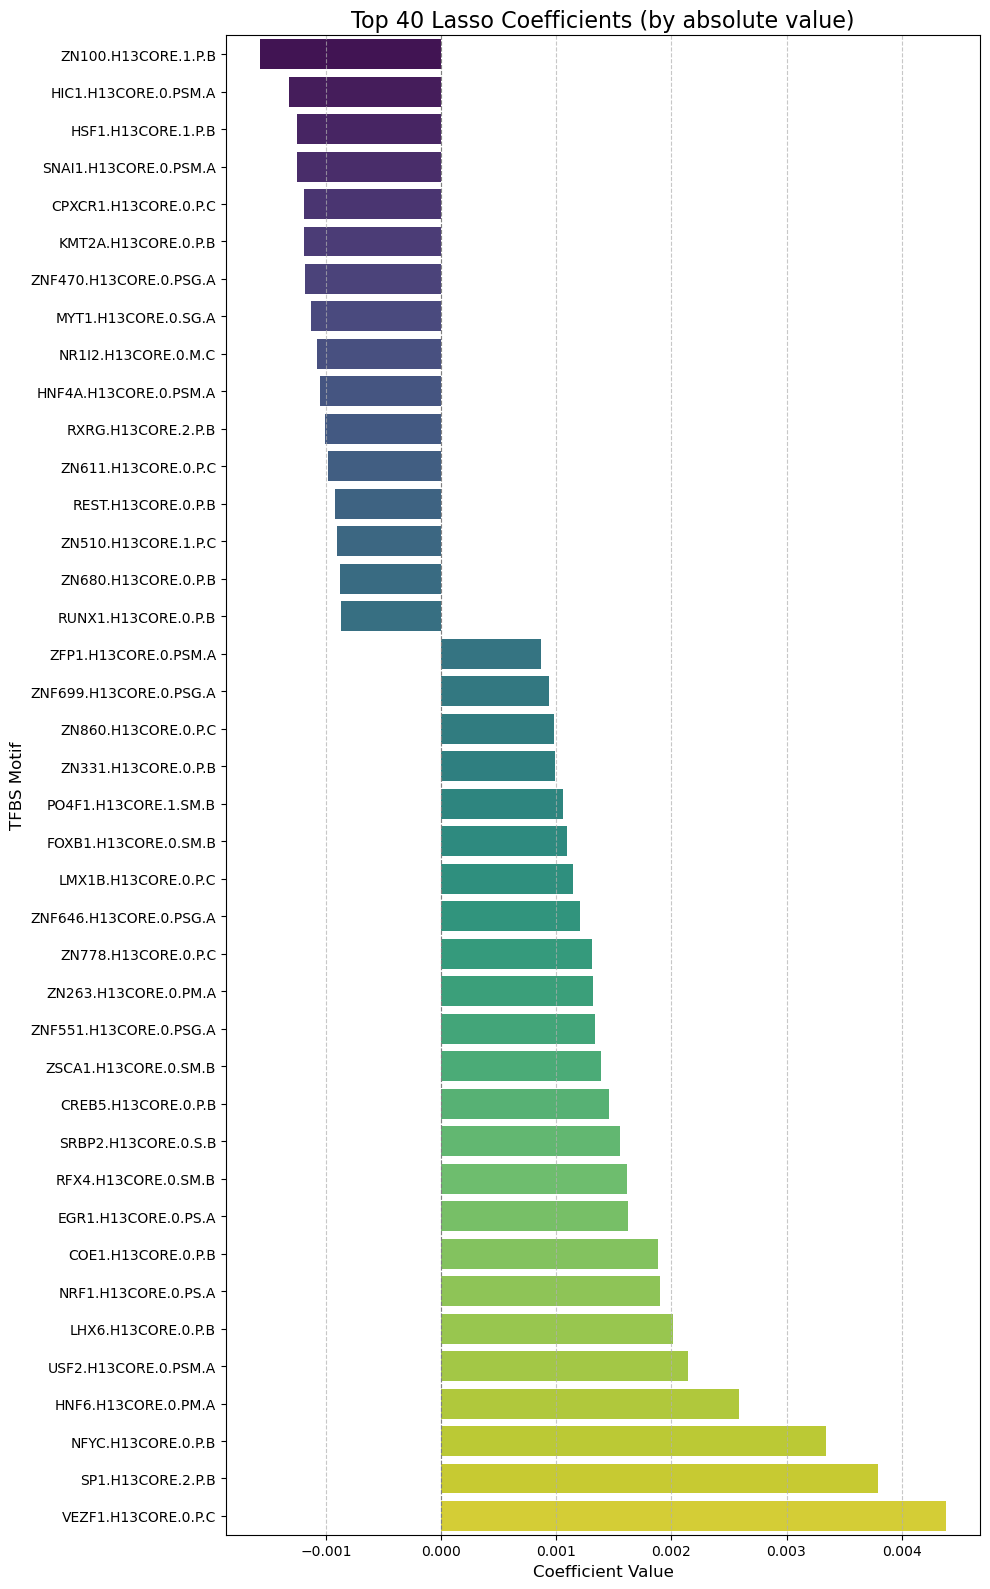


Coefficients displayed in the plot:
ZN100.H13CORE.1.P.B      -0.001572
HIC1.H13CORE.0.PSM.A     -0.001320
HSF1.H13CORE.1.P.B       -0.001254
SNAI1.H13CORE.0.PSM.A    -0.001252
CPXCR1.H13CORE.0.P.C     -0.001194
KMT2A.H13CORE.0.P.B      -0.001191
ZNF470.H13CORE.0.PSG.A   -0.001183
MYT1.H13CORE.0.SG.A      -0.001134
NR1I2.H13CORE.0.M.C      -0.001081
HNF4A.H13CORE.0.PSM.A    -0.001053
RXRG.H13CORE.2.P.B       -0.001010
ZN611.H13CORE.0.P.C      -0.000984
REST.H13CORE.0.P.B       -0.000922
ZN510.H13CORE.1.P.C      -0.000903
ZN680.H13CORE.0.P.B      -0.000879
RUNX1.H13CORE.0.P.B      -0.000871
ZFP1.H13CORE.0.PSM.A      0.000866
ZNF699.H13CORE.0.PSG.A    0.000935
ZN860.H13CORE.0.P.C       0.000984
ZN331.H13CORE.0.P.B       0.000991
PO4F1.H13CORE.1.SM.B      0.001059
FOXB1.H13CORE.0.SM.B      0.001091
LMX1B.H13CORE.0.P.C       0.001149
ZNF646.H13CORE.0.PSG.A    0.001204
ZN778.H13CORE.0.P.C       0.001312
ZN263.H13CORE.0.PM.A      0.001320
ZNF551.H13CORE.0.PSG.A    0.001332
ZSCA1.H13CORE.0.SM

In [135]:
visualize_lasso_coefficients(trained_lasso_model, feature_columns, top_n=40) # Adjust top_n as needed

In [ ]:
# elastic_net_regression_script.py

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_squared_error
import joblib # For saving and loading models
import os # For path manipulation

# --- Configuration ---
# Define the proportion of chromosomes to be held out for the test set
TEST_CHROMOSOME_PROPORTION = 0.2
# Define a random seed for reproducibility
RANDOM_SEED = 42
# Output directory for saving models and results
OUTPUT_DIR = 'elastic_net_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Configuration ---
# Define the proportion of chromosomes to be held out for the test set
TEST_CHROMOSOME_PROPORTION = 0.2
# Define a random seed for reproducibility
RANDOM_SEED = 42
# Output directory for saving models and results
OUTPUT_DIR = '/home/kisa/coding/80K_MPRA/element_variant_analysis_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
# File to save/load the chromosome split to ensure consistency across runs/scripts
CHROMOSOME_SPLIT_FILE = os.path.join(OUTPUT_DIR, 'chromosome_split.json')


# --- Model Training and Evaluation Function ---
def train_evaluate_elastic_net(X_train, X_test, y_train, y_test, feature_columns):
    """
    Trains an Elastic Net Regression model and evaluates its performance.

    Args:
        X_train (pd.DataFrame): Scaled training features.
        X_test (pd.DataFrame): Scaled test features.
        y_train (pd.Series): Training target variable.
        y_test (pd.Series): Test target variable.
        feature_columns (list): List of feature column names.

    Returns:
        sklearn.linear_model.ElasticNet: Trained Elastic Net model.
    """
    print("\n--- Training Elastic Net Regression Model with Cross-Validation ---")

    # Initialize Elastic Net Regression model with cross-validation for hyperparameter tuning
    # l1_ratio: The ElasticNet mixing parameter, with 0 <= l1_ratio <= 1.
    #           For l1_ratio = 1, it's equivalent to Lasso. For l1_ratio = 0, it's equivalent to Ridge.
    #           ElasticNetCV will search over a range of l1_ratio values.
    # alphas: List of alphas to try. If None, a default path is used.
    # cv: number of folds in K-fold cross-validation.
    # n_jobs: number of CPU cores to use. -1 means use all available cores.
    elastic_net_model = ElasticNetCV(
        l1_ratio=[.1, .5, .7, .9, .95, .99, 1], # Common l1_ratio values to search
        cv=5,                                 # 5-fold cross-validation
        random_state=RANDOM_SEED,
        n_jobs=-1                             # Use all available CPU cores
    ).fit(X_train, y_train)

    print(f"Optimal alpha found by ElasticNetCV: {elastic_net_model.alpha_:.4f}")
    print(f"Optimal l1_ratio found by ElasticNetCV: {elastic_net_model.l1_ratio_:.4f}")
    print("Elastic Net model training complete.")

    # Make predictions
    y_train_pred = elastic_net_model.predict(X_train)
    y_test_pred = elastic_net_model.predict(X_test)

    # Evaluate the model on training set
    train_r2 = r2_score(y_train, y_train_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    print(f"\nTraining R-squared: {train_r2:.4f}")
    print(f"Training Mean Squared Error: {train_mse:.4f}")

    # Evaluate the model on test set
    test_r2 = r2_score(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    print(f"Test R-squared: {test_r2:.4f}")
    print(f"Test Mean Squared Error: {test_mse:.4f}")

    # Display coefficients (useful for understanding feature importance)
    print("\nElastic Net Coefficients (after scaling):")
    coefficients = pd.Series(elastic_net_model.coef_, index=feature_columns)
    print(coefficients[coefficients != 0].sort_values(ascending=False)) # Show non-zero coefficients

    # --- Save Model and Results ---
    model_path = os.path.join(OUTPUT_DIR, 'elastic_net_model.joblib')
    joblib.dump(elastic_net_model, model_path)
    print(f"\nElastic Net model saved to: {model_path}")

    results_path = os.path.join(OUTPUT_DIR, 'elastic_net_results.txt')
    with open(results_path, 'w') as f:
        f.write(f"Elastic Net Regression Results:\n")
        f.write(f"Optimal Alpha: {elastic_net_model.alpha_:.4f}\n") # Use optimal alpha
        f.write(f"Optimal L1 Ratio: {elastic_net_model.l1_ratio_:.4f}\n") # Use optimal l1_ratio
        f.write(f"Training R-squared: {train_r2:.4f}\n")
        f.write(f"Training Mean Squared Error: {train_mse:.4f}\n")
        f.write(f"Test R-squared: {test_r2:.4f}\n")
        f.write(f"Test Mean Squared Error: {test_mse:.4f}\n")
        f.write("\nNon-zero Coefficients:\n")
        f.write(coefficients[coefficients != 0].sort_values(ascending=False).to_string())
    print(f"Elastic Net results saved to: {results_path}")

    writing=False
    if writing:
        # Optionally save predictions
        test_predictions_path = os.path.join(OUTPUT_DIR, 'elastic_net_test_predictions.csv')
        pd.DataFrame({'actual': y_test, 'predicted': y_test_pred}).to_csv(test_predictions_path, index=True)
        print(f"Test predictions saved to: {test_predictions_path}")

    return elastic_net_model

# --- Main execution block ---
if __name__ == "__main__":
    # Replace 'your_dataframe.csv' with the actual path to your DataFrame
    # If you don't provide a path, a sample DataFrame will be generated.
    # df_path = 'your_dataframe.csv'
    df_path = None # Using sample data for demonstration

    X_train_scaled, X_test_scaled, y_train, y_test, scaler, feature_columns = load_and_prepare_data(df_path)
    trained_elastic_net_model = train_evaluate_elastic_net(X_train_scaled, X_test_scaled, y_train, y_test, feature_columns)

    print("\nElastic Net Regression script finished.")
    print(f"All outputs saved to the '{OUTPUT_DIR}' directory.")

# --- Main execution block ---
if __name__ == "__main__":
    # Replace 'your_dataframe.csv' with the actual path to your DataFrame
    # If you don't provide a path, a sample DataFrame will be generated.
    # df_path = 'your_dataframe.csv'
    df_path = None # Using sample data for demonstration
    df_path = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/element_fimo_results_202507_motif_hits_per_sequence.tsv.gz" # Using sample data for demonstration

    X_train_scaled, X_test_scaled, y_train, y_test, scaler, feature_columns = load_and_prepare_data(df_path)
    trained_elastic_net_model = train_evaluate_elastic_net(X_train_scaled, X_test_scaled, y_train, y_test, feature_columns)

    print("\nElastic Net Regression script finished.")
    print(f"All outputs saved to the '{OUTPUT_DIR}' directory.")



Loaded DataFrame from /home/kisa/coding/80K_MPRA/element_variant_analysis_output/element_fimo_results_202507_motif_hits_per_sequence.tsv.gz with shape: (68241, 656)

Loading chromosome split from /home/kisa/coding/80K_MPRA/element_variant_analysis_output/chromosome_split.json...

Total chromosomes: 23
Chromosomes for training: 19 - ['chr17', 'chr4', 'chr12', 'chr10', 'chr1', 'chr9', 'chr6', 'chr14', 'chr7', 'chr15', 'chr13', 'chr11', 'chr5', 'chr21', 'chr3', 'chrX', 'chr19', 'chr8', 'chr2']
Chromosomes for testing: 4 - ['chr18', 'chr22', 'chr16', 'chr20']

Training set shape: X=(58085, 653), y=(58085,)
Test set shape: X=(10156, 653), y=(10156,)

--- Training Elastic Net Regression Model ---
Elastic Net model training complete.

Training R-squared: 0.0000
Training Mean Squared Error: 0.0024
Test R-squared: -0.0002
Test Mean Squared Error: 0.0024

Elastic Net Coefficients (after scaling):
Series([], dtype: float64)

Elastic Net model saved to: /home/kisa/coding/80K_MPRA/element_variant_a

In [ ]:
# pd.read_csv("/home/kisa/coding/80K_MPRA/element_variant_analysis_output/element_fimo_results_202507_motif_hits_per_sequence.tsv.gz", sep="\t", low_memory=False)

ParserError: Error tokenizing data. C error: Expected 1 fields in line 52, saw 2


In [16]:
element_metadata_fimo_results_df['sequence_name'].nunique() # 4124

68241

In [15]:
element_metadata_fimo_results_df.columns

Index(['motif_id', 'sequence_name', 'fimo_start', 'fimo_stop', 'fimo_strand',
       'fimo_score', 'fimo_p-value', 'fimo_q-value', 'fimo_matched_sequence',
       'sequence', 'name', 'chr', 'start', 'end', 'strand'],
      dtype='object')

In [ ]:
element_metadata_fimo_results_df_no_alt = element_metadata_fimo_results_df.loc[~element_metadata_fimo_results_df['name'].str.contains("cardiac_neuro_cava_random:ALT_")].copy()
element_metadata_fimo_results_df_no_alt # 226093
element_metadata_fimo_results_df_no_alt["name"].nunique() # 26539 # 24124

In [ ]:
element_metadata_fimo_results_df['name'].nunique() # subsample: 60340 sequences with TFBS found
n_seq_with_motif = element_metadata_fimo_results_df['name'].nunique()
print(f"Number of sequences with at least on Motif: {n_seq_with_motif}")

In [ ]:
element_metadata_fimo_results_df_no_alt['name'].nunique() # subsample: 24124 sequences with TFBS found
n_seq_with_motif = element_metadata_fimo_results_df_no_alt['name'].nunique()
print(f"Number of sequences with at least on Motif: {n_seq_with_motif}")

In [ ]:
element_metadata_fimo_results_df_no_alt.columns

fimo_columns = ['name', 'motif_id', 'fimo_start', 'fimo_stop', 'fimo_strand',
       'fimo_score', 'fimo_p-value', 'fimo_q-value', 'fimo_matched_sequence']

### Element based investigation: 


In [ ]:
# read the file
df_elements_bcalm_groups = pd.read_csv(config['files']['creating']['element_info_ngn2_undiffwtc11_202506'], sep='\t')
df_elements_bcalm_groups

In [ ]:
df_elements_bcalm_groups

In [ ]:
element_metadata_fimo_results_df_no_alt

In [ ]:
df_elements_bcalm_groups_fimo_info = df_elements_bcalm_groups.merge(element_metadata_fimo_results_df_no_alt[fimo_columns], on='name', how='inner').copy()
df_elements_bcalm_groups_fimo_info

- Remove all sequences with no_effect 
- Remove all TFBS predictions based on their local-bit score
- Check if overlapping TFBS predictions exist for each sequence
- Testing for each TFBS if it is enriched in the group of increasing vs decreasing
  - Get TFBS of interest
  - Get the number of decreasing occurrences (n_decreasing)
  - Get the number of increasing occurrences (n_increasing)
  - Get the total number of decreasing sequences without this TFBS (n_decreasing_no_tfbs_of_interest)
  - Get the total number of increasing sequences without this TFBS (n_increasing_no_tfbs_of_interest)
  - Chi-square test for enrichment

##### Compute the local bit score for each sequence

In [ ]:
from Bio import motifs

# function used to compute the local bitscore
def extract_motif_names(meme_file):
    motif_names = []
    with open(meme_file, "r") as f:
        for line in f:
            if line.startswith("MOTIF"):
                motif_name = line.split(" ", 1)[1].strip()
                motif_names.append(motif_name)
    return motif_names


# read the used motif file and extract the motifs
meme_file = "/home/kisa/coding/80K_MPRA/fimo_data//H13CORE_meme_format.meme"
motif_names = extract_motif_names(meme_file)

# Add the name while loading the file using biopython
hocomoco_motif_dict = {}
with open(meme_file) as handle:
    motif_list = motifs.parse(handle, "pfm-four-columns")
    i = 0
    for motif in motif_list:
        motif.name = motif_names[i]
        hocomoco_motif_dict[motif.name] = motif
        i += 1


def reverse_complement(seq):
    complement = str.maketrans("ACGTacgt", "TGCAtgca")
    return seq.translate(complement)[::-1]


def local_bitscore_tfbs(motif, sequence, motif_start, motif_end, variant_pos, strand, take_midpoint=False):
    """
    Calculate the local bitscore for a given motif and sequence, using a window of 5 bases around the variant position.
    """
    zero_based_motif_start = motif_start - 1 # start should be 0-based and end 1-based
    pwm = motif.pwm
    if not take_midpoint:
        zero_based_variant_pos = variant_pos[0]
    else:
        # if take midpoint, we use the midpoint of the motif as the variant position
        zero_based_variant_pos = int((motif_start + motif_end) / 2) - 1


    # Get only subset of sequence which is overlapped with the motif
    sequence_of_interest_start = max(zero_based_motif_start, zero_based_variant_pos - 5)
    sequence_of_interest_end = min(motif_end, zero_based_variant_pos + 5)


    motif_related_start = max(0, sequence_of_interest_start - zero_based_motif_start)
    motif_related_end = min(motif_end - zero_based_motif_start, sequence_of_interest_end - zero_based_motif_start)

    # normalize the score for the length of the motif
    additional_score = 10 - (motif_related_end - motif_related_start)
    motif_sequence = sequence[zero_based_motif_start:motif_end]
    # use the reverse complement sequence if the hit is on the "-" strand
    if strand == "-":
        motif_sequence = reverse_complement(motif_sequence)
    motif_part = motif_sequence[motif_related_start:motif_related_end]
    # crop the pwm to the motif related part:
    modified_pwm = {nuc: scores[motif_related_start:motif_related_end] for nuc, scores in pwm.items()}

    return additional_score + round(sum(modified_pwm[nuc][i] for i, nuc in enumerate(motif_part)), 4)

In [ ]:
df_elements_bcalm_groups_fimo_info

In [ ]:
df_elements_bcalm_groups_fimo_info['fimo_start'] = df_elements_bcalm_groups_fimo_info['fimo_start'].astype(int)
df_elements_bcalm_groups_fimo_info['fimo_stop'] = df_elements_bcalm_groups_fimo_info['fimo_stop'].astype(int)


In [ ]:
df_elements_bcalm_groups_fimo_info['local_bit_score'] = df_elements_bcalm_groups_fimo_info.apply(
    lambda row: local_bitscore_tfbs(
        motif=hocomoco_motif_dict[row["motif_id"]],
        sequence=row['sequence'],
        motif_start=row['fimo_start'],
        motif_end=row['fimo_stop'],
        variant_pos=[0],
        strand=row['strand'],
        take_midpoint=True
    ),
    axis=1
)

In [ ]:
local_bitscore_threshold = df_elements_bcalm_groups_fimo_info['local_bit_score'].quantile(0.8)
local_bitscore_threshold = 0
print(local_bitscore_threshold)
df_elements_bcalm_groups_fimo_info_filtered = df_elements_bcalm_groups_fimo_info.loc[df_elements_bcalm_groups_fimo_info['local_bit_score'] >= local_bitscore_threshold].copy()
df_elements_bcalm_groups_fimo_info_filtered_effect = df_elements_bcalm_groups_fimo_info_filtered.loc[df_elements_bcalm_groups_fimo_info_filtered["bcalm_effect_NGN2"] != "no_effect"].copy()
df_elements_bcalm_groups_fimo_info_filtered_effect

# remove filtering:
# df_elements_bcalm_groups_fimo_info_filtered_effect = df_elements_bcalm_groups_fimo_info_filtered

In [ ]:
df_elements_bcalm_groups_fimo_info_filtered_effect["motif_id"].value_counts()

In [ ]:
# calculate the chi-squared statistic and p-value
from scipy.stats import chi2_contingency
def analyze_motif(df, motif_id, bcalm_effect_col='bcalm_effect_NGN2'):
    test_motif_df = df.loc[df["motif_id"] == motif_id].copy()
    not_test_motif_df = df.loc[df["motif_id"] != motif_id].copy()
    if test_motif_df.shape[0] == 0 or not_test_motif_df.shape[0] == 0:
        return np.nan, np.nan, np.nan, np.nan
    # print(test_motif_df.shape[0], not_test_motif_df.shape[0])
    # print(test_motif_df[interesting_columns])

    # number of hits on decreasing sequences
    n_decreasing = test_motif_df.loc[test_motif_df[bcalm_effect_col] == "decreasing"].shape[0]
    n_increasing = test_motif_df.loc[test_motif_df[bcalm_effect_col] == "increasing"].shape[0]

    # number of increasing sequences without this TFBS
    n_decreasing_not_test_motif = not_test_motif_df.loc[not_test_motif_df[bcalm_effect_col] == "decreasing"].shape[0]
    n_increasing_not_test_motif = not_test_motif_df.loc[not_test_motif_df[bcalm_effect_col] == "increasing"].shape[0]

    # print the contingency table
    contingency_table = np.array([[n_decreasing, n_increasing],
                                    [n_decreasing_not_test_motif, n_increasing_not_test_motif]])

    # print("Contingency table:")
    # print(contingency_table)

    # calculate the chi-squared statistic and p-value
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    return chi2, p, n_increasing / (n_increasing + n_decreasing), n_increasing, n_decreasing, n_increasing_not_test_motif, n_decreasing_not_test_motif

# interpretation: inc / (inc + dec) = 0.5 means no effect, > 0.5 means increasing, < 0.5 means decreasing



In [ ]:
df_elements_bcalm_groups_fimo_info_filtered_effect.columns

interesting_columns = ['name', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'motif_id', 'fimo_start', 'fimo_stop',
       'fimo_strand', 'local_bit_score']

In [ ]:
df_elements_bcalm_groups_fimo_info_filtered_effect

In [ ]:
# all_tfbs = df_elements_bcalm_groups_fimo_info_filtered_effect['motif_id'].unique()

# generate new dataframe with only unique motifs which have a regulatory effect
unique_motifs = df_elements_bcalm_groups_fimo_info_filtered_effect.loc[df_elements_bcalm_groups_fimo_info_filtered_effect["bcalm_effect_NGN2"] != "no_effect"].drop_duplicates(subset=['motif_id']).copy()
unique_motifs = unique_motifs[['motif_id']].copy()


In [ ]:
unique_motifs[['chi2', 'p_value', 'inc_dec_ratio', 'n_increasing', 'n_decreasing', 'n_increasing_not_motif', 'n_decreasing_not_motif']] = unique_motifs.apply(
    lambda row: analyze_motif(df_elements_bcalm_groups_fimo_info_filtered_effect, row['motif_id']), axis=1, result_type='expand'
)

In [ ]:
unique_motifs
# frag mal ob es eine andere Metrik gibt (anstatt increasing / increasing + decreasing)
# 1. increased 0 und decreased kann so hoch sein wie es will => wird immer 0 sein
# 2. increased 10 und decreased 15 (TFBS oft gesehen) vs 0 zu 5 gleiches Ergebnis


In [ ]:
# Welches sind die TFBS die hauptsächlich in increasing oder decreasing sequenzen vorkommen?
# Welche metrik auch immer aber diese die kleine oder großen Quotienten haben

In [ ]:
df_elements_bcalm_groups_fimo_info['name'].nunique() # 24124

In [ ]:
df_elements_bcalm_groups_fimo_info.columns

In [ ]:
df_elements_bcalm_groups

In [ ]:
element_metadata_fimo_results_df

### Combine the fimo results with the variant metadata
- add the metadata information to the ref and alt sequences respectively

In [ ]:
variant_bcalm_exists_metadata_df.columns

In [ ]:
variant_bcalm_exists_metadata_df

In [ ]:
important_cols_for_matching = ['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos']

In [ ]:
element_metadata_fimo_results_df

In [ ]:
# for all variants :
variant_bcalm_exists_metadata_df

# Merge FIMO with variants based on alternative and reference sequence names
fimo_alt = element_metadata_fimo_results_df.merge(variant_bcalm_exists_metadata_df[important_cols_for_matching], left_on=col_name, right_on="ALT", how="inner")
fimo_ref = element_metadata_fimo_results_df.merge(variant_bcalm_exists_metadata_df[important_cols_for_matching], left_on=col_name, right_on="REF", how="inner")

# Rename columns to distinguish ALT and REF q-values
fimo_alt = fimo_alt.rename(columns={"q-value": "ALT_q-value", col_name: "ALT_name"})
fimo_ref = fimo_ref.rename(columns={"q-value": "REF_q-value", col_name: "REF_name"})

# Merge ALT and REF results on ID, motif_id, start, stop, strand
combined_fimo_df = pd.merge(
    fimo_alt[['ID', 'motif_id', 'start', 'stop', 'strand', 'ALT_name', 'ALT_q-value']],
    fimo_ref[['ID', 'motif_id', 'start', 'stop', 'strand', 'REF_name', 'REF_q-value']],
    on=['ID', 'motif_id', 'start', 'stop', 'strand'],
    how='outer'  # Ensure we include all motif occurrences
)

# Display the result
combined_fimo_df

### Note this combined fimo df is unfiltered for cases that the ref or alt is not occuring in the bcalm result table we can ensure that by having them filtered out


In [ ]:
print(combined_fimo_df.shape[0])
print("Number of motif to variant associations which are within ref and alt:", combined_fimo_df.loc[(~combined_fimo_df['REF_q-value'].isna()) & (~combined_fimo_df['ALT_q-value'].isna())].shape[0]) # 10869
print("Number of motif to variant associations which are within ref but are not within alt:", combined_fimo_df.loc[(~combined_fimo_df['REF_q-value'].isna()) & (combined_fimo_df['ALT_q-value'].isna())].shape[0]) # 57,161
print("Number of motif to variant associations which are not within ref but are within alt:", combined_fimo_df.loc[(combined_fimo_df['REF_q-value'].isna()) & (~combined_fimo_df['ALT_q-value'].isna())].shape[0]) # 725


In [ ]:
combined_fimo_df

### Add variant information to the combined fimo df 

In [ ]:
variant_bcalm_infos = ['ID', 'variant_pos', 'bcalm_variant_effect_data_exists', 'bcalm_variant_effect_adjusted_p_value', 'bcalm_variant_effect_log_ratio_activity', 'bcalm_reference_adjusted_p_value', 'bcalm_reference_log_ratio_activity', 'bcalm_alternative_adjusted_p_value', 'bcalm_alternative_log_ratio_activity']

In [ ]:
variant_metadata_fimo_combined_df = combined_fimo_df.merge(variant_bcalm_exists_metadata_df[variant_bcalm_infos], on="ID", how="inner")

In [ ]:
variant_metadata_fimo_combined_df

#### Filter vor variant overlapping TFBS

In [ ]:
def motif_overlaps_variant(row, fimo_start_col='start', fimo_stop_col='stop', col_variant_pos='variant_pos'):
    """Iterate over each variant pos and return true if the start stop coordinates are overlapping the variant position"""

    if isinstance(row[col_variant_pos], list):
        for variant_position in row[col_variant_pos]:
            if (int(row[fimo_start_col]) <= int(variant_position) & int(row[fimo_stop_col]) >= int(variant_position)):
                return True
    elif isinstance(row[col_variant_pos], int):
        if (int(row[fimo_start_col]) <= row[col_variant_pos] & int(row[fimo_stop_col]) >= row[col_variant_pos]):
                return True
    else:
        raise ValueError("Variant position has an unexpected data type")
    return False

variant_metadata_fimo_combined_df["is_variant_overlapping"] = variant_metadata_fimo_combined_df.apply(lambda row: motif_overlaps_variant(row, fimo_start_col='start', fimo_stop_col='stop', col_variant_pos='variant_pos'), axis=1)
# variant_overlapping_metadata_fimo_combined_df = variant_metadata_fimo_combined_df.loc[variant_metadata_fimo_combined_df.apply(lambda row: motif_overlaps_variant(row, fimo_start_col='start', fimo_stop_col='stop', col_variant_pos='variant_pos'), axis=1)].copy()

In [ ]:
sig_level = 0.1
variant_metadata_fimo_combined_df['is_significant'] = variant_metadata_fimo_combined_df['bcalm_variant_effect_adjusted_p_value'] < sig_level

In [ ]:
variant_metadata_fimo_combined_df['is_variant_overlapping'].sum()

### Plot the proportions using chatgpt code
- wrong code because we do not want to normalize using all the observations but rather using the the unique number of sequences
 

In [ ]:
variant_metadata_fimo_combined_df.loc[variant_metadata_fimo_combined_df['is_significant']]['ID'].nunique() # number of significant variants with a motif: 887

variant_metadata_fimo_combined_df.loc[variant_metadata_fimo_combined_df['is_significant'] & variant_metadata_fimo_combined_df['is_variant_overlapping']]['ID'].nunique() # number of significant variants with at least one overlaping tfbs 139


variant_metadata_fimo_combined_df.loc[variant_metadata_fimo_combined_df['is_significant'] & variant_metadata_fimo_combined_df['is_variant_overlapping']]['ID'].nunique()/variant_metadata_fimo_combined_df.loc[variant_metadata_fimo_combined_df['is_significant']]['ID'].nunique()

In [ ]:
# number of variant overlapping motifs
variant_metadata_fimo_combined_df['is_variant_overlapping'].sum()/46000

# number of all variants
# n_variants



In [ ]:
import seaborn as sns

In [ ]:
variant_metadata_fimo_combined_df['is_significant'].sum()

In [ ]:
variant_metadata_fimo_combined_df[variant_metadata_fimo_combined_df['is_significant']]['is_variant_overlapping'].sum()/variant_metadata_fimo_combined_df['is_significant'].sum()

In [ ]:
# variant_metadata_fimo_combined_df['is_variant_overlapping'].sum()/variant_metadata_fimo_combined_df

In [ ]:
variant_metadata_fimo_combined_df[variant_metadata_fimo_combined_df['is_significant']]['is_variant_overlapping'].sum() # 186

In [ ]:
variant_metadata_fimo_combined_df['is_variant_overlapping'].sum()

In [ ]:
variant_metadata_fimo_combined_df.loc[variant_metadata_fimo_combined_df['is_significant'] & variant_metadata_fimo_combined_df['is_variant_overlapping']]['ID'].nunique()

In [ ]:
variant_metadata_fimo_combined_df.loc[variant_metadata_fimo_combined_df['is_significant']]['ID'].nunique()

In [ ]:
variant_metadata_fimo_combined_df.loc[(variant_metadata_fimo_combined_df["REF_q-value"] < 0.05) | (variant_metadata_fimo_combined_df["REF_q-value"].isna())]

In [ ]:
asdfasdf

In [ ]:
# variant_metadata_fimo_combined_df.to_csv("subsampled_variant_metadata_fimo_h13_tfbs_overlapping_variants.tsv.gz", sep="\t", index=None)

# variant_metadata_fimo_combined_df = pd.read_csv("subsampled_variant_metadata_fimo_h13_tfbs_overlapping_variants.tsv.gz", sep="\t")


In [ ]:
gnomad_info_df = pd.read_csv(config["files"]["creating"]["gnomad_data_all_variants_local"], sep="\t")
gnomad_info_df.columns

In [ ]:
gnomad_info_df

In [ ]:
import pandas as pd
variant_metadata_fimo_combined_df_all = pd.read_csv("/home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_h13_clustered_all_useful_sequences_neuro_ctrls_scrambled_tested/NGN2_variant_metadata_fimo_h13_tfbs_overlapping_variants.tsv.gz", sep="\t")


In [ ]:
# add the sequences of the metadata file to the variant metadata file:
element_bcalm_metadata_df.columns

In [ ]:
variant_metadata_fimo_combined_df_all.columns

In [ ]:
variant_bcalm_metadata_df.columns


In [ ]:
variant_metadata_fimo_combined_df_all = variant_metadata_fimo_combined_df_all.merge(variant_bcalm_metadata_df[['ID', 'ref_sequence', 'alt_sequence']], on="ID").copy()

In [ ]:
variant_metadata_fimo_combined_df_all_AFs = variant_metadata_fimo_combined_df_all.merge(gnomad_info_df, left_on="ALT_name", right_on="header", how="inner")

In [ ]:
variant_metadata_fimo_combined_df_all_AFs

In [ ]:
variant_metadata_fimo_combined_df_all[variant_metadata_fimo_combined_df_all['ALT_name'].isna()]

In [ ]:
# some alt values are not found:
variant_metadata_fimo_combined_df_all['ALT_name'].nunique()
all_fimo_alt_names = set(variant_metadata_fimo_combined_df_all['ALT_name'].to_list())

all_fimo_alt_names

In [ ]:
variant_metadata_fimo_combined_df_all.columns

In [ ]:
import seaborn as sns
for q_value_threshold in [1, 0.75, 0.5, 0.2, 0.1, 0.05]:
    variant_metadata_fimo_combined_df_filtered = variant_metadata_fimo_combined_df.loc[(variant_metadata_fimo_combined_df['ALT_q-value'] < q_value_threshold) | (variant_metadata_fimo_combined_df['ALT_q-value'].isna())].copy()
    variant_metadata_fimo_combined_df_filtered = variant_metadata_fimo_combined_df_filtered.loc[(variant_metadata_fimo_combined_df_filtered['REF_q-value'] < q_value_threshold) | (variant_metadata_fimo_combined_df_filtered['REF_q-value'].isna())].copy()

    # Calculate proportions
    total_prop = variant_metadata_fimo_combined_df_filtered.loc[variant_metadata_fimo_combined_df_filtered['is_variant_overlapping']]['ID'].nunique()/46374 * 100
    significant_prop = variant_metadata_fimo_combined_df_filtered.loc[variant_metadata_fimo_combined_df_filtered['is_significant'] & variant_metadata_fimo_combined_df_filtered['is_variant_overlapping']]['ID'].nunique()/890 * 100

    # Prepare for plotting
    plot_data = pd.DataFrame({
        'Group': ['All Variants', 'Significant Variants'],
        'Proportion Overlapping TFBS': [total_prop, significant_prop]
    })

    # Plot using seaborn
    sns.set(style='whitegrid')
    plt.figure(figsize=(6, 4))
    ax = sns.barplot(x='Group', y='Proportion Overlapping TFBS', data=plot_data, palette='pastel')

    # Add data labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', label_type='edge')

    plt.ylim(0, 100)
    plt.title(f'Proportion of Variants Overlapping TFBS (q-value threshold: {q_value_threshold})')
    plt.ylabel('Proportion (%)')
    plt.xlabel('')
    plt.tight_layout()
    # plt.savefig(f"proportion_tfbs_overlapping_variants_{q_value_threshold}.png")
    plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
for q_value_threshold in [1, 0.5, 0.1, 0.05]:
    # variant_metadata_fimo_combined_df_filtered = variant_metadata_fimo_combined_df.loc[(variant_metadata_fimo_combined_df['ALT_q-value'] < q_value_threshold) | (variant_metadata_fimo_combined_df['ALT_q-value'].isna())].copy()
    variant_metadata_fimo_combined_df_filtered = variant_metadata_fimo_combined_df_all.loc[(variant_metadata_fimo_combined_df_all['ALT_q-value'] < q_value_threshold) | (variant_metadata_fimo_combined_df_all['ALT_q-value'].isna())].copy()
    variant_metadata_fimo_combined_df_filtered = variant_metadata_fimo_combined_df_filtered.loc[(variant_metadata_fimo_combined_df_filtered['REF_q-value'] < q_value_threshold) | (variant_metadata_fimo_combined_df_filtered['REF_q-value'].isna())].copy()

    # Calculate proportions
    # total_prop = variant_metadata_fimo_combined_df_filtered.loc[variant_metadata_fimo_combined_df_filtered['is_variant_overlapping']]['ID'].nunique()/46374 * 100
    total_prop = variant_metadata_fimo_combined_df_filtered.loc[variant_metadata_fimo_combined_df_filtered['is_variant_overlapping']]['ID'].nunique()/37948 * 100
    significant_prop = variant_metadata_fimo_combined_df_filtered.loc[variant_metadata_fimo_combined_df_filtered['is_significant'] & variant_metadata_fimo_combined_df_filtered['is_variant_overlapping']]['ID'].nunique()/896 * 100

    # Prepare for plotting
    plot_data = pd.DataFrame({
        'Group': ['All Variants', 'Significant Variants'],
        'Proportion Overlapping TFBS': [total_prop, significant_prop]
    })
    print("Number of different regions with TFBS variant overlap: ", variant_metadata_fimo_combined_df_filtered['REF_name'].nunique())

    # Plot using seaborn
    sns.set(style='whitegrid')
    plt.figure(figsize=(6, 4))
    ax = sns.barplot(x='Group', y='Proportion Overlapping TFBS', data=plot_data, palette='pastel')

    # Add data labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', label_type='edge')

    plt.ylim(0, 100)
    plt.title(f'Proportion of Variants Overlapping TFBS (q-value threshold: {q_value_threshold})')
    plt.ylabel('Proportion (%)')
    plt.xlabel('')
    plt.tight_layout()
    plt.savefig(f"proportion_tfbs_overlapping_variants_{q_value_threshold}.png")
    plt.show()

In [ ]:
variant_metadata_fimo_combined_df_all.columns

In [ ]:
variant_metadata_fimo_combined_df_all['REF_name'].nunique()

In [ ]:
variant_metadata_fimo_combined_df_all

In [ ]:
variant_metadata_fimo_combined_df_all_AFs

In [ ]:
from Bio import motifs

# function used to compute the local bitscore
def extract_motif_names(meme_file):
    motif_names = []
    with open(meme_file, "r") as f:
        for line in f:
            if line.startswith("MOTIF"):
                motif_name = line.split(" ", 1)[1].strip()
                motif_names.append(motif_name)
    return motif_names


# read the used motif file and extract the motifs
meme_file = "/home/kisa/coding/ISMB-2025_IGVF-MPRA-Tutorial/06_variant_effects_and_motifs/resources/hocomoco_v13/H13CORE_meme_format.meme"
motif_names = extract_motif_names(meme_file)

# Add the name while loading the file using biopython
hocomoco_motif_dict = {}
with open(meme_file) as handle:
    motif_list = motifs.parse(handle, "pfm-four-columns")
    i = 0
    for motif in motif_list:
        motif.name = motif_names[i]
        hocomoco_motif_dict[motif.name] = motif
        i += 1


def reverse_complement(seq):
    complement = str.maketrans("ACGTacgt", "TGCAtgca")
    return seq.translate(complement)[::-1]


def local_bitscore_tfbs(motif, sequence, motif_start, motif_end, variant_pos, strand):
    """
    Calculate the local bitscore for a given motif and sequence, using a window of 5 bases around the variant position.
    """
    zero_based_motif_start = motif_start - 1 # start should be 0-based and end 1-based
    pwm = motif.pwm
    zero_based_variant_pos = int(variant_pos[0])

    # Get only subset of sequence which is overlapped with the motif
    sequence_of_interest_start = max(zero_based_motif_start, zero_based_variant_pos - 5)
    sequence_of_interest_end = min(motif_end, zero_based_variant_pos + 5)


    motif_related_start = max(0, sequence_of_interest_start - zero_based_motif_start)
    motif_related_end = min(motif_end - zero_based_motif_start, sequence_of_interest_end - zero_based_motif_start)

    # normalize the score for the length of the motif
    additional_score = 10 - (motif_related_end - motif_related_start)
    motif_sequence = sequence[zero_based_motif_start:motif_end]
    # use the reverse complement sequence if the hit is on the "-" strand
    if strand == "-":
        motif_sequence = reverse_complement(motif_sequence)
    motif_part = motif_sequence[motif_related_start:motif_related_end]
    # crop the pwm to the motif related part:
    modified_pwm = {nuc: scores[motif_related_start:motif_related_end] for nuc, scores in pwm.items()}

    return additional_score + round(sum(modified_pwm[nuc][i] for i, nuc in enumerate(motif_part)), 4)

In [ ]:
variant_metadata_fimo_combined_df_all_AFs.columns

In [ ]:
variant_metadata_fimo_combined_df_all_AFs.columns

In [ ]:
variant_metadata_fimo_combined_df_all_AFs['start'] = variant_metadata_fimo_combined_df_all_AFs['start'].astype(int)
variant_metadata_fimo_combined_df_all_AFs['stop'] = variant_metadata_fimo_combined_df_all_AFs['stop'].astype(int)

list_columns = ["variant_pos"]

# Apply the safe_eval function to the specified columns
for col in list_columns:
    variant_metadata_fimo_combined_df_all_AFs[col] = variant_metadata_fimo_combined_df_all_AFs[col].apply(safe_eval)


In [ ]:
variant_metadata_fimo_combined_df_all_AFs.head()

In [ ]:
def motif_overlaps_variant(row, fimo_start_col='start', fimo_stop_col='stop', col_variant_pos='variant_pos'):
    """
    Iterate over each variant pos and return true if the start stop coordinates are overlapping the variant position
    NOTE: start and stop are 1-based while variant position from the metadata format is 0-based
    """

    if isinstance(row[col_variant_pos], list):
        for variant_position in row[col_variant_pos]:
            # make the variant position 1-based
            variant_pos_1_based = int(variant_position) + 1
            if (int(row[fimo_start_col]) <= variant_pos_1_based & int(row[fimo_stop_col]) >= variant_pos_1_based):
                return True
    elif isinstance(row[col_variant_pos], int):
        # make the variant position 1-based
        variant_pos_1_based = row[col_variant_pos] + 1
        if (int(row[fimo_start_col]) <= variant_pos_1_based & int(row[fimo_stop_col]) >= variant_pos_1_based):
            return True
    else:
        print(row)
        print(type(row[col_variant_pos]))
        raise ValueError("Variant position has an unexpected data type")
    return False

variant_metadata_fimo_combined_df_all_AFs["is_variant_overlapping"] = variant_metadata_fimo_combined_df_all_AFs.apply(lambda row: motif_overlaps_variant(row, fimo_start_col='start', fimo_stop_col='stop', col_variant_pos='variant_pos'), axis=1)


In [ ]:
variant_metadata_fimo_combined_df_all_AFs_variant_overlapping = variant_metadata_fimo_combined_df_all_AFs.loc[variant_metadata_fimo_combined_df_all_AFs["is_variant_overlapping"]].copy()

In [ ]:
variant_metadata_fimo_combined_df_all_AFs_variant_overlapping_head = variant_metadata_fimo_combined_df_all_AFs_variant_overlapping.head(1000).copy()

In [ ]:
variant_metadata_fimo_combined_df_all_AFs_variant_overlapping_head['REF_bit_score'] = variant_metadata_fimo_combined_df_all_AFs_variant_overlapping_head.apply(
    lambda row: local_bitscore_tfbs(
        motif=hocomoco_motif_dict[row["motif_id"]],
        sequence=row['ref_sequence'],
        motif_start=row['start'],
        motif_end=row['stop'],
        variant_pos=row['variant_pos'],
        strand=row['strand']
    ),
    axis=1
)

variant_metadata_fimo_combined_df_all_AFs_variant_overlapping_head['ALT_bit_score'] = variant_metadata_fimo_combined_df_all_AFs_variant_overlapping_head.apply(
    lambda row: local_bitscore_tfbs(
        motif=hocomoco_motif_dict[row["motif_id"]],
        sequence=row['alt_sequence'],
        motif_start=row['start'],
        motif_end=row['stop'],
        variant_pos=row['variant_pos'],
        strand=row['strand']
    ),
    axis=1
)

In [ ]:
variant_metadata_fimo_combined_df_all_AFs_head['ALT_bit_score']

In [ ]:
variant_metadata_fimo_combined_df_all_AFs_head

In [ ]:
variant_metadata_fimo_combined_df_all_AFs.columns

In [ ]:
variant_metadata_fimo_combined_df_all_AFs['variant_pos'].isna().sum()

In [ ]:
variant_metadata_fimo_combined_df_all_AFs_variant_overlapping['REF_bit_score'] = variant_metadata_fimo_combined_df_all_AFs_variant_overlapping.apply(
    lambda row: local_bitscore_tfbs(
        motif=hocomoco_motif_dict[row["motif_id"]],
        sequence=row['ref_sequence'],
        motif_start=row['start'],
        motif_end=row['stop'],
        variant_pos=row['variant_pos'],
        strand=row['strand']
    ),
    axis=1
)

variant_metadata_fimo_combined_df_all_AFs_variant_overlapping['ALT_bit_score'] = variant_metadata_fimo_combined_df_all_AFs_variant_overlapping.apply(
    lambda row: local_bitscore_tfbs(
        motif=hocomoco_motif_dict[row["motif_id"]],
        sequence=row['alt_sequence'],
        motif_start=row['start'],
        motif_end=row['stop'],
        variant_pos=row['variant_pos'],
        strand=row['strand']
    ),
    axis=1
)

In [ ]:
writing = False
if writing:
    variant_metadata_fimo_combined_df_all_AFs_variant_overlapping.to_csv("/home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_h13_clustered_all_useful_sequences_neuro_ctrls_scrambled_tested/NGN2_variant_metadata_fimo_h13_tfbs_overlapping_variants_local_bitscore_filtered.tsv.gz", sep="\t", index=None)

In [29]:
variant_metadata_fimo_combined_df_all_AFs_variant_overlapping = pd.read_csv("/home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_h13_clustered_all_useful_sequences_neuro_ctrls_scrambled_tested/NGN2_variant_metadata_fimo_h13_tfbs_overlapping_variants_local_bitscore_filtered.tsv.gz", sep="\t")

# list columns col_variant_class, col_variant_pos, col_SPDI, col_allele
list_columns = [col_variant_pos]

# Apply the safe_eval function to the specified columns
for col in list_columns:
    variant_metadata_fimo_combined_df_all_AFs_variant_overlapping[col] = variant_metadata_fimo_combined_df_all_AFs_variant_overlapping[col].apply(safe_eval)


In [30]:
variant_metadata_fimo_combined_df_all_AFs_variant_overlapping

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,variant_pos,...,AF,AF_popmax,AF_eas,AF_nfe,AF_fin,AF_afr,AF_asj,REF_bit_score,ALT_bit_score,max_bit_score
0,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,ATMIN.H13CORE.0.P.B,135,155,-,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,0.0126,cardiac_neuro_cava_random:REF_NLGN2|ENSG000001...,0.0168,[146],...,0.000007,0.000015,0.0,0.000015,0.0,0.0,0.0,4.1990,4.3810,4.381
1,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,ZF69B.H13CORE.0.P.C,130,147,-,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,0.1760,cardiac_neuro_cava_random:REF_NLGN2|ENSG000001...,0.1860,[146],...,0.000007,0.000015,0.0,0.000015,0.0,0.0,0.0,6.0100,6.0100,6.010
2,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,ZNF800.H13CORE.0.PSG.A,127,147,-,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,0.0402,NaN,NaN,[146],...,0.000007,0.000015,0.0,0.000015,0.0,0.0,0.0,6.9627,6.9627,6.963
3,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,ZN681.H13CORE.0.P.C,131,151,+,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,0.0550,cardiac_neuro_cava_random:REF_NLGN2|ENSG000001...,0.0730,[146],...,0.000007,0.000015,0.0,0.000015,0.0,0.0,0.0,6.4885,6.6573,6.657
4,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,ZNF705EP.H13CORE.0.P.B,135,155,-,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,0.0273,NaN,NaN,[146],...,0.000007,0.000015,0.0,0.000015,0.0,0.0,0.0,6.6780,7.6340,7.634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70283,cardiac_neuro_cava_random:ALT_PKP2|ENSG0000005...,FOSL2.H13CORE.0.P.B,121,132,-,cardiac_neuro_cava_random:ALT_PKP2|ENSG0000005...,0.2640,NaN,NaN,[127],...,0.000020,0.000044,0.0,0.000044,0.0,0.0,0.0,5.9141,6.8791,6.879
70284,cardiac_neuro_cava_random:ALT_PKP2|ENSG0000005...,ZN329.H13CORE.0.P.C,120,141,+,cardiac_neuro_cava_random:ALT_PKP2|ENSG0000005...,0.3940,NaN,NaN,[127],...,0.000020,0.000044,0.0,0.000044,0.0,0.0,0.0,5.2664,5.6946,5.695
70285,cardiac_neuro_cava_random:ALT_PKP2|ENSG0000005...,ZN251.H13CORE.0.P.C,124,142,-,cardiac_neuro_cava_random:ALT_PKP2|ENSG0000005...,0.8310,NaN,NaN,[127],...,0.000020,0.000044,0.0,0.000044,0.0,0.0,0.0,6.1503,6.1503,6.150
70286,cardiac_neuro_cava_random:ALT_CTNNA3|ENSG00000...,ZN248.H13CORE.0.P.B,200,222,-,cardiac_neuro_cava_random:ALT_CTNNA3|ENSG00000...,0.9510,NaN,NaN,[219],...,0.000020,0.000196,0.0,0.000000,0.0,0.0,0.0,5.4832,5.4832,5.483


#### Add gene information and the specificity information

In [31]:
# Functions to get the information about considered expressed transcription factors
def from_masterlist_info_2_gene_symbol(masterlist_info):
    """Expects to get a dict as input and tried to read the human gene_symbol"""
    try:
        gene_symbol = masterlist_info['species']['HUMAN']['gene_symbol']
        uniprot_id =  masterlist_info['species']['HUMAN']['uniprot_id']
        uniprot_accession_num =  masterlist_info['species']['HUMAN']['uniprot_ac']
    except:
        print("Problem during finding gene symbol of the following masterlist info: ", masterlist_info)
        gene_symbol = pd.NA
    return pd.Series({'gene_symbol': gene_symbol, 'uniprot_id': uniprot_id, 'uniprot_accession_num': uniprot_accession_num})

In [32]:
hocomoco_annotation_info_path = "/home/kisa/coding/ISMB-2025_IGVF-MPRA-Tutorial/06_variant_effects_and_motifs/resources/hocomoco_v13/H13CORE-CLUSTERED_annotation.jsonl"
hocomoco_annotation_info_all = pd.read_json(path_or_buf=hocomoco_annotation_info_path, lines=True)
hocomoco_annotation_info_all

# rename name
hocomoco_annotation_info = hocomoco_annotation_info_all.rename(columns={"name": "motif_id"}).copy()

hocomoco_annotation_info[['gene_symbol', 'uniprot_id', 'uniprot_accession_num']] = hocomoco_annotation_info["masterlist_info"].apply(from_masterlist_info_2_gene_symbol)
hocomoco_annotation_info
# only name and tf name
hocomoco_annotation_info = hocomoco_annotation_info[['motif_id', 'gene_symbol', 'uniprot_id', 'uniprot_accession_num', 'cluster_motifs']].copy()
# add gene info
variant_metadata_fimo_combined_df_all_AFs_variant_overlapping = variant_metadata_fimo_combined_df_all_AFs_variant_overlapping.merge(hocomoco_annotation_info[['motif_id', 'gene_symbol']], on="motif_id", how="inner").copy()


binary_gene_activity_matrix_path = "/home/kisa/coding/ISMB-2025_IGVF-MPRA-Tutorial/06_variant_effects_and_motifs/resources/gene_matrix_specificity_by_percentage.tsv.gz"
binary_gene_activity_matrix_df = pd.read_csv(binary_gene_activity_matrix_path, sep="\t", low_memory=False)
binary_gene_activity_matrix_df_specificity = binary_gene_activity_matrix_df[["gene_symbol", "Excitatory neurons", "Inhibitory neurons", "SpecificityLabel"]]
binary_gene_activity_matrix_df_specificity

variant_metadata_fimo_combined_df_all_AFs_variant_overlapping = variant_metadata_fimo_combined_df_all_AFs_variant_overlapping.merge(binary_gene_activity_matrix_df_specificity, on="gene_symbol", how="left")

In [33]:
variant_metadata_fimo_combined_df_all_AFs_variant_overlapping['SpecificityLabel'].isna().sum() # 986

986

For 5 genes we have no information if they are specific or not

In [34]:
unique_genes = variant_metadata_fimo_combined_df_all_AFs_variant_overlapping.drop_duplicates(subset=["gene_symbol"]).copy()
unique_genes["Excitatory neurons"].isna().sum() # 5 # 5 different genes

5

In [35]:
variant_metadata_fimo_combined_df_all_AFs_variant_overlapping.shape[0] # first: 70288

70288

In [36]:
variant_metadata_fimo_combined_df_all_AFs_variant_overlapping

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,variant_pos,...,AF_fin,AF_afr,AF_asj,REF_bit_score,ALT_bit_score,max_bit_score,gene_symbol,Excitatory neurons,Inhibitory neurons,SpecificityLabel
0,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,ATMIN.H13CORE.0.P.B,135,155,-,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,0.0126,cardiac_neuro_cava_random:REF_NLGN2|ENSG000001...,0.0168,[146],...,0.0,0.0,0.0,4.1990,4.3810,4.381,ATMIN,1.0,1.0,Broad
1,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,ZF69B.H13CORE.0.P.C,130,147,-,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,0.1760,cardiac_neuro_cava_random:REF_NLGN2|ENSG000001...,0.1860,[146],...,0.0,0.0,0.0,6.0100,6.0100,6.010,ZFP69B,1.0,1.0,Broad
2,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,ZNF800.H13CORE.0.PSG.A,127,147,-,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,0.0402,NaN,NaN,[146],...,0.0,0.0,0.0,6.9627,6.9627,6.963,ZNF800,1.0,1.0,Broad
3,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,ZN681.H13CORE.0.P.C,131,151,+,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,0.0550,cardiac_neuro_cava_random:REF_NLGN2|ENSG000001...,0.0730,[146],...,0.0,0.0,0.0,6.4885,6.6573,6.657,ZNF681,1.0,1.0,Broad
4,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,ZNF705EP.H13CORE.0.P.B,135,155,-,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,0.0273,NaN,NaN,[146],...,0.0,0.0,0.0,6.6780,7.6340,7.634,ZNF705EP,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70283,cardiac_neuro_cava_random:ALT_PKP2|ENSG0000005...,FOSL2.H13CORE.0.P.B,121,132,-,cardiac_neuro_cava_random:ALT_PKP2|ENSG0000005...,0.2640,NaN,NaN,[127],...,0.0,0.0,0.0,5.9141,6.8791,6.879,FOSL2,1.0,1.0,Broad
70284,cardiac_neuro_cava_random:ALT_PKP2|ENSG0000005...,ZN329.H13CORE.0.P.C,120,141,+,cardiac_neuro_cava_random:ALT_PKP2|ENSG0000005...,0.3940,NaN,NaN,[127],...,0.0,0.0,0.0,5.2664,5.6946,5.695,ZNF329,1.0,1.0,Broad
70285,cardiac_neuro_cava_random:ALT_PKP2|ENSG0000005...,ZN251.H13CORE.0.P.C,124,142,-,cardiac_neuro_cava_random:ALT_PKP2|ENSG0000005...,0.8310,NaN,NaN,[127],...,0.0,0.0,0.0,6.1503,6.1503,6.150,ZNF251,1.0,1.0,Broad
70286,cardiac_neuro_cava_random:ALT_CTNNA3|ENSG00000...,ZN248.H13CORE.0.P.B,200,222,-,cardiac_neuro_cava_random:ALT_CTNNA3|ENSG00000...,0.9510,NaN,NaN,[219],...,0.0,0.0,0.0,5.4832,5.4832,5.483,ZNF248,1.0,1.0,Broad


In [37]:
variant_metadata_fimo_combined_df_all_AFs_variant_overlapping['is_significant'].value_counts()

is_significant
False    68579
True      1709
Name: count, dtype: int64

In [38]:
variant_metadata_fimo_combined_df_all_AFs_variant_overlapping.loc[variant_metadata_fimo_combined_df_all_AFs_variant_overlapping['is_significant']]['ID'].nunique() # 529

531

#### Compute the maximum local bit score for each sequence

In [39]:
variant_metadata_fimo_combined_df_all_AFs_variant_overlapping.head()

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,variant_pos,...,AF_fin,AF_afr,AF_asj,REF_bit_score,ALT_bit_score,max_bit_score,gene_symbol,Excitatory neurons,Inhibitory neurons,SpecificityLabel
0,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,ATMIN.H13CORE.0.P.B,135,155,-,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,0.0126,cardiac_neuro_cava_random:REF_NLGN2|ENSG000001...,0.0168,[146],...,0.0,0.0,0.0,4.1990,4.3810,4.381,ATMIN,1.0,1.0,Broad
1,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,ZF69B.H13CORE.0.P.C,130,147,-,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,0.1760,cardiac_neuro_cava_random:REF_NLGN2|ENSG000001...,0.1860,[146],...,0.0,0.0,0.0,6.0100,6.0100,6.010,ZFP69B,1.0,1.0,Broad
2,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,ZNF800.H13CORE.0.PSG.A,127,147,-,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,0.0402,NaN,NaN,[146],...,0.0,0.0,0.0,6.9627,6.9627,6.963,ZNF800,1.0,1.0,Broad
3,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,ZN681.H13CORE.0.P.C,131,151,+,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,0.0550,cardiac_neuro_cava_random:REF_NLGN2|ENSG000001...,0.0730,[146],...,0.0,0.0,0.0,6.4885,6.6573,6.657,ZNF681,1.0,1.0,Broad
4,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,ZNF705EP.H13CORE.0.P.B,135,155,-,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,0.0273,NaN,NaN,[146],...,0.0,0.0,0.0,6.6780,7.6340,7.634,ZNF705EP,NaN,NaN,NaN


In [40]:
variant_metadata_fimo_combined_df_all_AFs_variant_overlapping['max_bit_score'] = variant_metadata_fimo_combined_df_all_AFs_variant_overlapping[['REF_bit_score', 'ALT_bit_score']].max(axis=1).round(3)

In [42]:
print("Number of Motif predictions within the given sequences", variant_metadata_fimo_combined_df_all_AFs_variant_overlapping.shape[0])
print("Number of different variants we found at least one TFBS", variant_metadata_fimo_combined_df_all_AFs_variant_overlapping['ID'].nunique())

Number of Motif predictions within the given sequences 70288
Number of different variants we found at least one TFBS 23087


<Axes: >

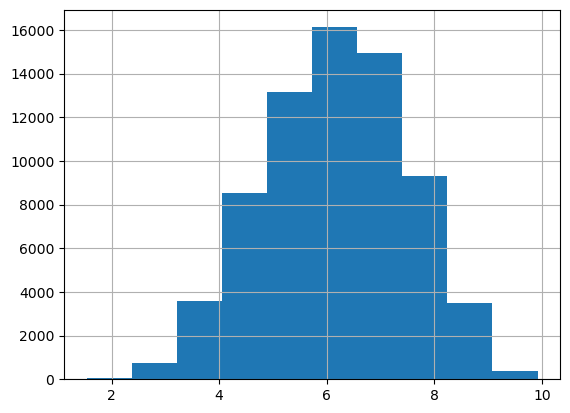

In [43]:
variant_metadata_fimo_combined_df_all_AFs_variant_overlapping['max_bit_score'].hist()
# variant_metadata_fimo_combined_df_all_AFs_variant_overlapping['max_bit_score'].describe()

In [44]:
# optional stringent filtering based on the maximal bit score
bitscore_threshold = 8
bitscore_threshold = variant_metadata_fimo_combined_df_all_AFs_variant_overlapping['max_bit_score'].quantile(0.8)
print(bitscore_threshold)

variant_metadata_fimo_combined_overlap_bitscore_filtered = variant_metadata_fimo_combined_df_all_AFs_variant_overlapping.loc[variant_metadata_fimo_combined_df_all_AFs_variant_overlapping['max_bit_score'] >= bitscore_threshold].copy()

7.342600000000005


In [45]:
print("Number of Motif predictions within the given sequences", variant_metadata_fimo_combined_overlap_bitscore_filtered.shape[0])
print("Number of different variants we found at least one TFBS", variant_metadata_fimo_combined_overlap_bitscore_filtered['ID'].nunique())
print("Number of different motifs found: ", variant_metadata_fimo_combined_overlap_bitscore_filtered['motif_id'].nunique())

Number of Motif predictions within the given sequences 14058
Number of different variants we found at least one TFBS 9924
Number of different motifs found:  619


#### Increasing Confidence: Use Cell-type Expression Data

In [46]:
# Functions to get the information about considered expressed transcription factors
def from_masterlist_info_2_gene_symbol(masterlist_info):
    """Expects to get a dict as input and tried to read the human gene_symbol"""
    try:
        gene_symbol = masterlist_info['species']['HUMAN']['gene_symbol']
        uniprot_id =  masterlist_info['species']['HUMAN']['uniprot_id']
        uniprot_accession_num =  masterlist_info['species']['HUMAN']['uniprot_ac']
    except:
        print("Problem during finding gene symbol of the following masterlist info: ", masterlist_info)
        gene_symbol = pd.NA
    return pd.Series({'gene_symbol': gene_symbol, 'uniprot_id': uniprot_id, 'uniprot_accession_num': uniprot_accession_num})


def get_neuro_activity_info(variant_metadata_df):
    """
    Loads the hocomoco annotations and gets gene_symbol for each motif_id before it merged the information about which motif
    is expressed either in Excitatory neurons or Inhibitory Neurons
    """
    binary_gene_activity_matrix_path = "/home/kisa/coding/ISMB-2025_IGVF-MPRA-Tutorial/06_variant_effects_and_motifs/resources/gene_matrix_specificity_by_percentage.tsv.gz"
    binary_gene_activity_matrix_df = pd.read_csv(binary_gene_activity_matrix_path, sep="\t", low_memory=False)
    # get all genes which are considered active within neurons:
    binary_gene_activity_matrix_df['neuron_active'] = (binary_gene_activity_matrix_df["Excitatory neurons"] == 1) | (binary_gene_activity_matrix_df["Inhibitory neurons"] == 1)

    hocomoco_annotation_info_path = "/home/kisa/coding/ISMB-2025_IGVF-MPRA-Tutorial/06_variant_effects_and_motifs/resources/hocomoco_v13/H13CORE-CLUSTERED_annotation.jsonl"
    hocomoco_annotation_info_all = pd.read_json(path_or_buf=hocomoco_annotation_info_path, lines=True)
    hocomoco_annotation_info_all
    # rename name
    hocomoco_annotation_info = hocomoco_annotation_info_all.rename(columns={"name": "motif_id"}).copy()

    hocomoco_annotation_info[['gene_symbol', 'uniprot_id', 'uniprot_accession_num']] = hocomoco_annotation_info["masterlist_info"].apply(from_masterlist_info_2_gene_symbol)
    hocomoco_annotation_info
    # only name and tf name
    hocomoco_annotation_info = hocomoco_annotation_info[['motif_id', 'gene_symbol', 'uniprot_id', 'uniprot_accession_num', 'cluster_motifs']].copy()

    # add gene info
    variant_metadata_fimo_combined_overlap_bitscore_filtered_gene_info_df = variant_metadata_df.merge(hocomoco_annotation_info[['motif_id', 'gene_symbol']], on="motif_id", how="inner").copy()
    # add gene activity
    variant_metadata_fimo_combined_overlap_filtered_seq_gene_info_activity = variant_metadata_fimo_combined_overlap_bitscore_filtered_gene_info_df.merge(binary_gene_activity_matrix_df[["gene_symbol", "neuron_active"]], on="gene_symbol", how="inner").copy()
    return variant_metadata_fimo_combined_overlap_filtered_seq_gene_info_activity

In [95]:
# significant_variant_overlapping_tfbs_neuro_activity = get_neuro_activity_info(variant_metadata_fimo_combined_overlap_bitscore_filtered)
# significant_variant_overlapping_tfbs_neuro_activity = significant_variant_overlapping_tfbs_neuro_activity.loc[significant_variant_overlapping_tfbs_neuro_activity['neuron_active']].copy()

In [97]:
# print("Number of Motif predictions within the given sequences", significant_variant_overlapping_tfbs_neuro_activity.shape[0])
# print("Number of different variants we found at least one TFBS", significant_variant_overlapping_tfbs_neuro_activity['ID'].nunique())

#### TODO: 
- remove the TFBS which does not seem to be doing anything
- get the gene name for the motif_ids => list of motifs
- should we use the additional data to increase the motif knowledge?

In [47]:
def classify_tfbs_change(row, ref_bit_score_col='REF_bit_score', alt_bit_score_col='ALT_bit_score'):
    """
    Classifies the tfbs change based on the bitscore differences
    """
    if row[alt_bit_score_col] > row[ref_bit_score_col]:
        return 'gain'
    elif row[alt_bit_score_col] < row[ref_bit_score_col]:
        return 'loss'
    else:
        return 'no_change'

In [48]:
# significant_variant_overlapping_tfbs_neuro_activity['tfbs_change_class'] = significant_variant_overlapping_tfbs_neuro_activity.apply(
#     lambda row: classify_tfbs_change(row, ref_bit_score_col='REF_bit_score', alt_bit_score_col='ALT_bit_score'),
#     axis=1
# )
variant_metadata_fimo_combined_overlap_bitscore_filtered['tfbs_change_class'] = variant_metadata_fimo_combined_overlap_bitscore_filtered.apply(
    lambda row: classify_tfbs_change(row, ref_bit_score_col='REF_bit_score', alt_bit_score_col='ALT_bit_score'),
    axis=1
)

In [49]:
# significant_variant_overlapping_tfbs_neuro_activity['tfbs_change_class'].value_counts()
variant_metadata_fimo_combined_overlap_bitscore_filtered['tfbs_change_class'].value_counts()

tfbs_change_class
gain         6184
no_change    5701
loss         2173
Name: count, dtype: int64

In [50]:
variant_metadata_fimo_combined_overlap_bitscore_filtered = variant_metadata_fimo_combined_overlap_bitscore_filtered.loc[variant_metadata_fimo_combined_overlap_bitscore_filtered['tfbs_change_class'] != "no_change"].copy()
variant_metadata_fimo_combined_overlap_bitscore_filtered

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,variant_pos,...,AF_afr,AF_asj,REF_bit_score,ALT_bit_score,max_bit_score,gene_symbol,Excitatory neurons,Inhibitory neurons,SpecificityLabel,tfbs_change_class
4,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,ZNF705EP.H13CORE.0.P.B,135,155,-,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,0.0273,NaN,NaN,[146],...,0.000000,0.000000,6.6780,7.6340,7.634,ZNF705EP,NaN,NaN,NaN,gain
29,cardiac_neuro_cava_random:ALT_HRAS|ENSG0000017...,ZN823.H13CORE.0.P.C,35,57,+,cardiac_neuro_cava_random:ALT_HRAS|ENSG0000017...,0.1010,NaN,NaN,[55],...,0.000000,0.000000,7.0472,7.9957,7.996,ZNF823,1.0,1.0,Broad,gain
34,cardiac_neuro_cava_random:ALT_MYOM1|ENSG000001...,ZN441.H13CORE.0.P.C,179,188,+,cardiac_neuro_cava_random:ALT_MYOM1|ENSG000001...,0.9560,NaN,NaN,[179],...,0.164737,0.002880,7.4947,7.8826,7.883,ZNF441,1.0,1.0,Broad,gain
39,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,ZN296.H13CORE.0.S.C,225,235,-,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,0.5980,NaN,NaN,[231],...,0.270033,0.639931,6.4612,7.4569,7.457,ZNF296,1.0,1.0,Broad,gain
41,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,ZNF587B.H13CORE.0.SG.A,226,239,+,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,0.3840,NaN,NaN,[231],...,0.270033,0.639931,6.4442,7.4117,7.412,ZNF587B,1.0,1.0,Broad,gain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70256,cardiac_neuro_cava_random:ALT_TANC2|ENSG000001...,ZN716.H13CORE.1.P.C,181,191,-,cardiac_neuro_cava_random:ALT_TANC2|ENSG000001...,0.3330,NaN,NaN,[187],...,0.000000,0.000000,7.1125,7.7562,7.756,ZNF716,0.0,0.0,Moderately Specific,gain
70262,cardiac_neuro_cava_random:ALT_CTNNA3|ENSG00000...,SMAD3.H13CORE.1.P.B,167,175,-,cardiac_neuro_cava_random:ALT_CTNNA3|ENSG00000...,0.3480,NaN,NaN,[172],...,0.000000,0.000000,7.5560,8.2600,8.260,SMAD3,1.0,1.0,Broad,gain
70273,cardiac_neuro_cava_random:ALT_CTNNA3|ENSG00000...,ZFP82.H13CORE.0.P.C,63,87,+,cardiac_neuro_cava_random:ALT_CTNNA3|ENSG00000...,0.2040,cardiac_neuro_cava_random:REF_CTNNA3|ENSG00000...,0.223,[86],...,0.000000,0.000000,7.8280,8.1078,8.108,ZFP82,1.0,1.0,Broad,gain
70278,cardiac_neuro_cava_random:ALT_CREBBP|ENSG00000...,SPI1.H13CORE.0.P.B,210,223,-,cardiac_neuro_cava_random:ALT_CREBBP|ENSG00000...,0.2100,NaN,NaN,[215],...,0.000000,0.000000,6.3447,7.3437,7.344,SPI1,1.0,1.0,Broad,gain


In [51]:
print("Number of Motif predictions within the given sequences", variant_metadata_fimo_combined_overlap_bitscore_filtered.shape[0])
print("Number of different variants we found at least one TFBS", variant_metadata_fimo_combined_overlap_bitscore_filtered['ID'].nunique())
print("Number of different motifs found: ", variant_metadata_fimo_combined_overlap_bitscore_filtered['motif_id'].nunique())

Number of Motif predictions within the given sequences 8357
Number of different variants we found at least one TFBS 6478
Number of different motifs found:  602


In [52]:
variant_metadata_fimo_combined_overlap_bitscore_filtered['motif_id'].value_counts()

motif_id
FOSL2.H13CORE.0.P.B        186
ZN362.H13CORE.0.P.C        145
ZNF705EP.H13CORE.0.P.B     138
VEZF1.H13CORE.0.P.C        137
ZNF646.H13CORE.0.PSG.A     122
                          ... 
ZN383.H13CORE.0.P.C          1
TF7L1.H13CORE.2.S.C          1
ZN197.H13CORE.0.P.C          1
ZBTB8A.H13CORE.0.PSGI.A      1
ZN662.H13CORE.0.P.C          1
Name: count, Length: 602, dtype: int64

### Interprete the results

In [53]:
def interprete_TFBS_findings(row, variant_effect_col="bcalm_variant_effect_log_ratio_activity", bit_score_difference_col="alt_ref_bitscore_diff", new_interpretation_col="TFBS_interpretation", cell_type_tested="neural progenitors derived from WTC11"):
    """Iterate over each motif variant association and interprete the effect of the identified TFBS as follows:
        Activating TFBS:
            - if REF binds better and negative effect logfc => motif is predicted to be activating in this cell type
            - if ALT binds better and positive effect logfc => motif is predicted to be activating in this cell type
        Repressing TFBS:
            - if ALT binds better and negative effect logfc => motif is predicted to be repressing in this cell type
            - if REF binds better and positive effect logfc => motif is predicted to be repressing in this cell type
    """
    bit_score_diff = row[bit_score_difference_col] # since alt - ref if alt > ref => alt binds better than ref => it is positive if ref binds better it is negative
    variant_effect = row[variant_effect_col] # assume alt - ref
    interpretation=""
    if bit_score_diff > 0: # alt binds better
        if variant_effect > 0: # variant is activating
            interpretation = f"predicted to be a transcriptional increasing motif in {cell_type_tested}"
        elif variant_effect < 0: # variant is repressing
            interpretation = f"predicted to be a transcriptional decreasing motif in {cell_type_tested}"
        else:
            raise ValueError("Did not expect a variant with 0 variant effect: please sanity check")
    elif bit_score_diff < 0: # ref binds better
        if variant_effect > 0: # variant is activating
            interpretation = f"predicted to be a transcriptional decreasing motif in {cell_type_tested}"
        elif variant_effect < 0: # variant is repressing
            interpretation = f"predicted to be a transcriptional increasing motif in {cell_type_tested}"
        else:
            raise ValueError("Did not expect a variant with 0 variant effect: please sanity check")
    else:
        interpretation="Ref and Alt have same bit score => unimportant base hit => motif does not seem to be causal"
        print(f"{row['motif_id']} REF and ALT have same bit score => motif is not causal")
    row[new_interpretation_col] = interpretation
    return row

In [54]:
variant_metadata_fimo_combined_overlap_bitscore_filtered["bit_score_change"] = variant_metadata_fimo_combined_overlap_bitscore_filtered["ALT_bit_score"] - variant_metadata_fimo_combined_overlap_bitscore_filtered["REF_bit_score"]

In [55]:
variant_metadata_fimo_combined_overlap_bitscore_filtered = variant_metadata_fimo_combined_overlap_bitscore_filtered.apply(lambda row: interprete_TFBS_findings(row, variant_effect_col="bcalm_variant_effect_log_ratio_activity", bit_score_difference_col="bit_score_change", new_interpretation_col="TFBS_interpretation", cell_type_tested="Neurons derived from WTC11"), axis=1)

In [56]:
variant_metadata_fimo_combined_overlap_bitscore_filtered['TFBS_interpretation'].value_counts()

TFBS_interpretation
predicted to be a transcriptional decreasing motif in Neurons derived from WTC11    4294
predicted to be a transcriptional increasing motif in Neurons derived from WTC11    4063
Name: count, dtype: int64

#### Focus on significant variants: 

In [57]:
sig_level = 0.1
variant_metadata_fimo_combined_overlap_bitscore_filtered_sig = variant_metadata_fimo_combined_overlap_bitscore_filtered.loc[variant_metadata_fimo_combined_overlap_bitscore_filtered['bcalm_variant_effect_adjusted_p_value'] < sig_level].copy()

variant_metadata_fimo_combined_overlap_bitscore_filtered_sig['TFBS_interpretation'].value_counts()

TFBS_interpretation
predicted to be a transcriptional increasing motif in Neurons derived from WTC11    106
predicted to be a transcriptional decreasing motif in Neurons derived from WTC11     89
Name: count, dtype: int64

##### Filter the multiple TFBS predictions for the same variant

In [58]:
variant_fimo_prediction_best_motif = variant_metadata_fimo_combined_overlap_bitscore_filtered_sig.sort_values(by='max_bit_score', ascending=False)

# Drop duplicate 'ID' values, keeping the first occurrence (which is now the one
# with the highest max_bit_score due to the sorting)
variant_fimo_prediction_best_motif = variant_fimo_prediction_best_motif.drop_duplicates(subset='ID', keep='first')

In [59]:
variant_fimo_prediction_best_motif['TFBS_interpretation'].value_counts()

TFBS_interpretation
predicted to be a transcriptional increasing motif in Neurons derived from WTC11    78
predicted to be a transcriptional decreasing motif in Neurons derived from WTC11    69
Name: count, dtype: int64

In [60]:
variant_fimo_prediction_best_motif['motif_id'].value_counts()

motif_id
FOSL2.H13CORE.0.P.B        5
GABPA.H13CORE.0.PSM.A      4
ZNF229.H13CORE.0.SG.A      3
ZFP14.H13CORE.0.P.C        3
ETV7.H13CORE.1.P.C         3
                          ..
ZN789.H13CORE.0.P.C        1
SCRT1.H13CORE.0.PSM.A      1
ZN257.H13CORE.0.P.B        1
THB.H13CORE.0.P.B          1
ZNF648.H13CORE.0.PSGI.A    1
Name: count, Length: 115, dtype: int64

#### Write the best TFBS overlapping significant variants to file:
- one file predicted to be increasing
- one file predicted to be decreasing

In [61]:
variant_fimo_prediction_best_motif

variant_based_increasing_tfbs_motifs_path = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/tfbs_analysis/NGN2_best_sig_variant_based_increasing_tfbs_motifs.tsv.gz"

increasing_motif_df = variant_fimo_prediction_best_motif.loc[variant_fimo_prediction_best_motif['TFBS_interpretation'].str.contains("increasing")].copy()
increasing_motif_set = set(increasing_motif_df['motif_id'].to_list())
increasing_motif_df

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,variant_pos,...,REF_bit_score,ALT_bit_score,max_bit_score,gene_symbol,Excitatory neurons,Inhibitory neurons,SpecificityLabel,tfbs_change_class,bit_score_change,TFBS_interpretation
63172,cardiac_neuro_cava_random:ALT_FLCN|ENSG0000015...,SMAD3.H13CORE.1.P.B,91,99,+,cardiac_neuro_cava_random:ALT_FLCN|ENSG0000015...,0.3330,NaN,NaN,[98],...,8.8350,9.2970,9.297,SMAD3,1.0,1.0,Broad,gain,0.4620,predicted to be a transcriptional increasing m...
13197,cardiac_neuro_cava_random:ALT_FHL2|ENSG0000011...,ZNF646.H13CORE.0.PSG.A,34,58,+,cardiac_neuro_cava_random:ALT_FHL2|ENSG0000011...,0.0021,cardiac_neuro_cava_random:REF_FHL2|ENSG0000011...,0.0117,[33],...,7.9529,8.8453,8.845,ZNF646,1.0,1.0,Broad,gain,0.8924,predicted to be a transcriptional increasing m...
51197,cardiac_neuro_cava_random:ALT_CDH1|ENSG0000003...,GABPA.H13CORE.0.PSM.A,116,127,+,cardiac_neuro_cava_random:ALT_CDH1|ENSG0000003...,0.6090,NaN,NaN,[119],...,7.6302,8.6300,8.630,GABPA,1.0,1.0,Broad,gain,0.9998,predicted to be a transcriptional increasing m...
67043,cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...,ZFTA.H13CORE.0.PSGIB.A,33,43,+,cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...,0.2190,cardiac_neuro_cava_random:REF_SRC|ENSG00000197...,0.2310,[32],...,8.3880,8.5920,8.592,ZFTA,1.0,1.0,Broad,gain,0.2040,predicted to be a transcriptional increasing m...
9906,cardiac_neuro_cava_random:ALT_CUX1|ENSG0000025...,FOSL2.H13CORE.0.P.B,18,29,+,cardiac_neuro_cava_random:ALT_CUX1|ENSG0000025...,0.1810,cardiac_neuro_cava_random:REF_CUX1|ENSG0000025...,0.1810,[27],...,8.4436,8.5594,8.559,FOSL2,1.0,1.0,Broad,gain,0.1158,predicted to be a transcriptional increasing m...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27331,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,IRF9.H13CORE.0.PSM.A,79,94,-,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.4930,NaN,NaN,[85],...,6.4230,7.4037,7.404,IRF9,1.0,1.0,Broad,gain,0.9807,predicted to be a transcriptional increasing m...
66987,cardiac_neuro_cava_random:ALT_JPH2|ENSG0000014...,OLIG1.H13CORE.0.S.B,176,191,+,cardiac_neuro_cava_random:ALT_JPH2|ENSG0000014...,1.0000,NaN,NaN,[186],...,6.3954,7.3954,7.395,OLIG1,1.0,1.0,Moderately Specific,gain,1.0000,predicted to be a transcriptional increasing m...
45099,cardiac_neuro_cava_random:ALT_CDK19|ENSG000001...,ZN787.H13CORE.1.S.C,80,91,+,cardiac_neuro_cava_random:ALT_CDK19|ENSG000001...,0.7260,cardiac_neuro_cava_random:REF_CDK19|ENSG000001...,0.7260,[90],...,7.3875,7.3043,7.388,ZNF787,1.0,1.0,Broad,loss,-0.0832,predicted to be a transcriptional increasing m...
3991,cardiac_neuro_cava_random:ALT_JAG1|ENSG0000010...,ZNF746.H13CORE.0.PSG.A,198,223,+,cardiac_neuro_cava_random:ALT_JAG1|ENSG0000010...,0.0168,cardiac_neuro_cava_random:REF_JAG1|ENSG0000010...,0.0168,[221],...,7.3616,7.3858,7.386,ZNF746,1.0,1.0,Broad,gain,0.0242,predicted to be a transcriptional increasing m...


In [62]:
variant_based_decreasing_tfbs_motifs_path = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/tfbs_analysis/NGN2_best_sig_variant_based_decreasing_tfbs_motifs.tsv.gz"

decreasing_motif_df = variant_fimo_prediction_best_motif.loc[variant_fimo_prediction_best_motif['TFBS_interpretation'].str.contains("decreasing")].copy()
decreasing_motif_set = set(decreasing_motif_df['motif_id'].to_list())
decreasing_motif_df
writing =False
if writing:
    increasing_motif_df.to_csv(variant_based_increasing_tfbs_motifs_path, sep="\t", index=None)
    decreasing_motif_df.to_csv(variant_based_decreasing_tfbs_motifs_path, sep="\t", index=None)

In [63]:
variant_metadata_fimo_combined_overlap_bitscore_filtered.head()

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,variant_pos,...,REF_bit_score,ALT_bit_score,max_bit_score,gene_symbol,Excitatory neurons,Inhibitory neurons,SpecificityLabel,tfbs_change_class,bit_score_change,TFBS_interpretation
4,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,ZNF705EP.H13CORE.0.P.B,135,155,-,cardiac_neuro_cava_random:ALT_NLGN2|ENSG000001...,0.0273,NaN,NaN,[146],...,6.6780,7.6340,7.634,ZNF705EP,NaN,NaN,NaN,gain,0.9560,predicted to be a transcriptional increasing m...
29,cardiac_neuro_cava_random:ALT_HRAS|ENSG0000017...,ZN823.H13CORE.0.P.C,35,57,+,cardiac_neuro_cava_random:ALT_HRAS|ENSG0000017...,0.1010,NaN,NaN,[55],...,7.0472,7.9957,7.996,ZNF823,1.0,1.0,Broad,gain,0.9485,predicted to be a transcriptional decreasing m...
34,cardiac_neuro_cava_random:ALT_MYOM1|ENSG000001...,ZN441.H13CORE.0.P.C,179,188,+,cardiac_neuro_cava_random:ALT_MYOM1|ENSG000001...,0.9560,NaN,NaN,[179],...,7.4947,7.8826,7.883,ZNF441,1.0,1.0,Broad,gain,0.3879,predicted to be a transcriptional increasing m...
39,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,ZN296.H13CORE.0.S.C,225,235,-,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,0.5980,NaN,NaN,[231],...,6.4612,7.4569,7.457,ZNF296,1.0,1.0,Broad,gain,0.9957,predicted to be a transcriptional decreasing m...
41,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,ZNF587B.H13CORE.0.SG.A,226,239,+,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,0.3840,NaN,NaN,[231],...,6.4442,7.4117,7.412,ZNF587B,1.0,1.0,Broad,gain,0.9675,predicted to be a transcriptional decreasing m...


### Sanity check the results here by looking if the common variants are more likely to hit binding sites of cell-type specific TFBS

In [ ]:
def get_variant_AF_group(row, af_col='AF', ac_col='AC'):
    """
    Classify the variant into different AF groups based on the AF and AC values.
    """
    if pd.isna(row[af_col]) or pd.isna(row[ac_col]):
        raise ValueError("AF or AC column contains NaN values, please check the input data.")
    af = row[af_col]
    ac = row[ac_col]
    if ac == 1:
        return "singleton"
    elif af <= 0.01:
        return "ultra-rare"
    elif af > 0.01 and af < 0.05:
        return "rare"
    else:
        return "common"

In [66]:
variant_fimo_prediction_best_motif['variant_group'] = variant_fimo_prediction_best_motif.apply(lambda row: get_variant_AF_group(row, af_col='AF', ac_col='AC'), axis=1)
variant_fimo_prediction_best_motif['variant_group'].value_counts()
variant_metadata_fimo_combined_overlap_bitscore_filtered['variant_group'] = variant_metadata_fimo_combined_overlap_bitscore_filtered.apply(lambda row: get_variant_AF_group(row, af_col='AF', ac_col='AC'), axis=1)
variant_metadata_fimo_combined_overlap_bitscore_filtered['variant_group'].value_counts()

variant_group
singleton     2264
common        2176
ultra-rare    2176
rare          1741
Name: count, dtype: int64

In [67]:
variant_metadata_fimo_combined_overlap_bitscore_filtered["SpecificityLabel"].value_counts()

SpecificityLabel
Broad                  7571
Moderately Specific     454
Cell-Specific           160
Name: count, dtype: int64

In [68]:
variant_fimo_prediction_best_motif = variant_metadata_fimo_combined_overlap_bitscore_filtered.sort_values(by='max_bit_score', ascending=False)

# Drop duplicate 'ID' values, keeping the first occurrence (which is now the one
# with the highest max_bit_score due to the sorting)
variant_fimo_prediction_best_motif = variant_fimo_prediction_best_motif.drop_duplicates(subset='ID', keep='first')

In [69]:
variant_fimo_prediction_best_motif.columns

Index(['ID', 'motif_id', 'start', 'stop', 'strand', 'ALT_name', 'ALT_q-value',
       'REF_name', 'REF_q-value', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'is_variant_overlapping',
       'is_significant', 'ref_sequence', 'alt_sequence', 'header', 'chrom',
       'pos', 'ref', 'alt', 'AC', 'AF', 'AF_popmax', 'AF_eas', 'AF_nfe',
       'AF_fin', 'AF_afr', 'AF_asj', 'REF_bit_score', 'ALT_bit_score',
       'max_bit_score', 'gene_symbol', 'Excitatory neurons',
       'Inhibitory neurons', 'SpecificityLabel', 'tfbs_change_class',
       'bit_score_change', 'TFBS_interpretation', 'variant_group'],
      dtype='object')

In [70]:
variant_fimo_prediction_best_motif

,ID,motif_id,start,stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,variant_pos,...,ALT_bit_score,max_bit_score,gene_symbol,Excitatory neurons,Inhibitory neurons,SpecificityLabel,tfbs_change_class,bit_score_change,TFBS_interpretation,variant_group
21906,cardiac_neuro_cava_random:ALT_SMAD3|ENSG000001...,ZN611.H13CORE.1.P.C,199,223,+,cardiac_neuro_cava_random:ALT_SMAD3|ENSG000001...,0.273000,cardiac_neuro_cava_random:REF_SMAD3|ENSG000001...,0.229000,[222],...,8.9169,9.878,ZNF611,1.0,1.0,Broad,loss,-0.9615,predicted to be a transcriptional decreasing m...,common
8041,cardiac_neuro_cava_random:ALT_R3HDML|ENSG00000...,ZN611.H13CORE.1.P.C,152,176,+,cardiac_neuro_cava_random:ALT_R3HDML|ENSG00000...,0.226000,cardiac_neuro_cava_random:REF_R3HDML|ENSG00000...,0.271000,[175],...,9.8784,9.878,ZNF611,1.0,1.0,Broad,gain,0.9702,predicted to be a transcriptional increasing m...,rare
13234,cardiac_neuro_cava_random:ALT_SHANK2|ENSG00000...,ZN649.H13CORE.0.P.C,181,205,-,cardiac_neuro_cava_random:ALT_SHANK2|ENSG00000...,1.000000,cardiac_neuro_cava_random:REF_SHANK2|ENSG00000...,1.000000,[192],...,9.8728,9.873,ZNF649,1.0,1.0,Broad,gain,0.9887,predicted to be a transcriptional increasing m...,common
19553,cardiac_neuro_cava_random:ALT_SMAD6|ENSG000001...,ZN578.H13CORE.0.P.C,217,240,+,cardiac_neuro_cava_random:ALT_SMAD6|ENSG000001...,0.485000,NaN,NaN,[239],...,9.8099,9.810,ZNF578,1.0,1.0,Broad,gain,0.9543,predicted to be a transcriptional increasing m...,common
1097,cardiac_neuro_cava_random:ALT_GATA4|ENSG000001...,ZNF646.H13CORE.0.PSG.A,131,155,+,cardiac_neuro_cava_random:ALT_GATA4|ENSG000001...,0.000014,cardiac_neuro_cava_random:REF_GATA4|ENSG000001...,0.000157,[130],...,9.8027,9.803,ZNF646,1.0,1.0,Broad,gain,0.8924,predicted to be a transcriptional increasing m...,rare
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67378,cardiac_neuro_cava_random:ALT_H1-3|ENSG0000012...,FOXB1.H13CORE.0.SM.B,203,221,+,cardiac_neuro_cava_random:ALT_H1-3|ENSG0000012...,0.490000,NaN,NaN,[211],...,7.3428,7.343,FOXB1,0.0,0.0,Moderately Specific,gain,0.9964,predicted to be a transcriptional decreasing m...,common
35735,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,ZN787.H13CORE.1.S.C,99,110,+,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,0.726000,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,0.726000,[107],...,6.7045,7.343,ZNF787,1.0,1.0,Broad,loss,-0.6389,predicted to be a transcriptional decreasing m...,singleton
3202,cardiac_neuro_cava_random:ALT_R3HDML|ENSG00000...,ZIK1.H13CORE.0.P.C,57,79,+,cardiac_neuro_cava_random:ALT_R3HDML|ENSG00000...,0.156000,cardiac_neuro_cava_random:REF_R3HDML|ENSG00000...,0.244000,[67],...,7.3426,7.343,ZIK1,1.0,1.0,Broad,gain,0.8793,predicted to be a transcriptional decreasing m...,ultra-rare
59234,cardiac_neuro_cava_random:ALT_LINC01033|ENSG00...,ZN418.H13CORE.0.P.B,61,78,+,cardiac_neuro_cava_random:ALT_LINC01033|ENSG00...,0.343000,NaN,NaN,[63],...,7.3427,7.343,ZNF418,1.0,1.0,Broad,gain,0.3964,predicted to be a transcriptional increasing m...,singleton


In [71]:
variant_fimo_prediction_best_motif["Excitatory neurons"].isna().sum()
variant_fimo_prediction_best_motif_no_na = variant_fimo_prediction_best_motif.loc[variant_fimo_prediction_best_motif["Excitatory neurons"].notna()].copy()

In [72]:
variant_fimo_prediction_best_motif_no_na['ID'].nunique() # 6478

6377

In [73]:
sig_level = 0.1
variant_fimo_prediction_best_motif_no_na_sig = variant_fimo_prediction_best_motif_no_na.loc[variant_fimo_prediction_best_motif_no_na['bcalm_variant_effect_adjusted_p_value'] < sig_level].copy()

In [ ]:
# which of these variants are more common and rare?
# Which tfbs are cell-type specific and cell-type unspecific?

In [74]:
variant_fimo_prediction_best_motif_no_na_sig['variant_group'].value_counts()

variant_group
singleton     43
ultra-rare    39
common        33
rare          32
Name: count, dtype: int64

In [75]:
variant_fimo_prediction_best_motif_no_na_sig['SpecificityLabel'].value_counts()

SpecificityLabel
Broad                  134
Moderately Specific     10
Cell-Specific            3
Name: count, dtype: int64

In [76]:
variant_fimo_prediction_best_motif_no_na['variant_group'].value_counts()


variant_group
singleton     1784
ultra-rare    1725
common        1599
rare          1269
Name: count, dtype: int64

In [77]:
variant_metadata_fimo_combined_overlap_bitscore_filtered['variant_group'].value_counts()

variant_group
singleton     2264
common        2176
ultra-rare    2176
rare          1741
Name: count, dtype: int64

In [78]:
variant_metadata_fimo_combined_overlap_bitscore_filtered["SpecificityLabel"].unique()

array([nan, 'Broad', 'Moderately Specific', 'Cell-Specific'], dtype=object)

In [79]:
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np


# --- Step 1: Filter for Significant Variants ONLY ---
significant_variants_df = variant_metadata_fimo_combined_overlap_bitscore_filtered[variant_metadata_fimo_combined_overlap_bitscore_filtered['is_significant'] == True].copy()

# Check if there's enough data for analysis
if significant_variants_df.empty:
    print("No significant variants found in the DataFrame. Cannot perform analysis.")
elif 'variant_group' not in significant_variants_df.columns:
    print("The 'variant_group' column is missing. Please ensure it exists.")
elif 'SpecificityLabel' not in significant_variants_df.columns:
    print("The 'SpecificityLabel' column is missing. Please ensure it exists.")
else:
    # --- Step 2: Define "Common" vs. "Rare" and "Cell-Specific" vs. "Not Cell-Specific" ---
    # Create a new 'is_common_or_rare' column for the 2x2 table
    significant_variants_df['is_common_or_rare'] = np.where(
        significant_variants_df['variant_group'] == 'common',
        'Common',
        np.where(significant_variants_df['variant_group'].isin(['ultra-rare', 'singleton']), 'Rare', np.nan)
    )

    # Filter out any rows that don't fit into 'Common' or 'Rare' (e.g., if there were other categories)
    significant_variants_df = significant_variants_df.dropna(subset=['is_common_or_rare']).copy()


    # Create a binary 'is_cell_specific' column
    significant_variants_df['is_cell_specific'] = (significant_variants_df['SpecificityLabel'] == 'Cell-Specific')

    # Ensure there are both common/rare and cell-specific/not cell-specific variants in the filtered data
    # after the 'is_common_or_rare' categorization
    if significant_variants_df['is_common_or_rare'].nunique() < 2 or \
       significant_variants_df['is_cell_specific'].nunique() < 2:
        print("Not enough variation in 'Common/Rare' groups or 'Cell-Specific' status among significant variants to perform Chi-Square test.")
        print("Counts of Common/Rare:", significant_variants_df['is_common_or_rare'].value_counts(dropna=False))
        print("Counts of is_cell_specific:", significant_variants_df['is_cell_specific'].value_counts(dropna=False))
    else:
        # --- Step 3: Create a Contingency Table ---
        contingency_table = pd.crosstab(
            significant_variants_df['is_common_or_rare'],
            significant_variants_df['is_cell_specific']
        )

        # Rename columns for better readability
        contingency_table.columns = ['Not Cell-Specific', 'Cell-Specific']
        # Ensure row index order for OR calculation: Common, Rare
        # Use .reindex with fill_value=0 in case one category is entirely missing in the filtered data
        contingency_table = contingency_table.reindex(index=['Common', 'Rare'], fill_value=0)


        print("Contingency Table for Significant Variants (Common vs. Rare):")
        print(contingency_table)
        print("\n")

        # --- Step 4: Perform the Chi-Square Test of Independence ---
        # chi2_contingency expects a numpy array or similar, so pass .values
        chi2, p_value, dof, expected = chi2_contingency(contingency_table.values)

        print(f"Chi-square statistic: {chi2:.4f}")
        print(f"P-value: {p_value:.4f}")
        print(f"Degrees of freedom: {dof}")
        print("\n")

        # --- Step 5: Calculate Odds Ratio and its Confidence Interval ---
        # Extract counts from the contingency table based on its structure:
        #                    Not Cell-Specific  Cell-Specific
        # Common                     b                a
        # Rare                       d                c

        a = contingency_table.loc['Common', 'Cell-Specific']        # Common and Cell-Specific
        b = contingency_table.loc['Common', 'Not Cell-Specific']    # Common and Not Cell-Specific
        c = contingency_table.loc['Rare', 'Cell-Specific']          # Rare and Cell-Specific
        d = contingency_table.loc['Rare', 'Not Cell-Specific']      # Rare and Not Cell-Specific

        # Add a small epsilon to avoid division by zero and log(0) issues for OR and CI calculation
        # It's better to check for zeros directly before computing, and add epsilon only for SE calculation if needed
        if (b == 0 or c == 0): # or (a == 0 and b == 0) or (c == 0 and d == 0) for OR calculation
             print("Cannot calculate Odds Ratio: One of the cell counts (b or c) is zero, leading to division by zero or an undefined ratio.")
             print("Contingency table cell counts (a, b, c, d):", a, b, c, d)
        else:
            odds_ratio = (a * d) / (b * c)

            # For Confidence Interval calculation, we need to handle zeros gracefully.
            # Add a small constant to any zero cell to avoid issues with log and standard error.
            # This is a common practice for calculating CIs when cell counts are zero.
            epsilon = 0.5
            safe_a = a if a > 0 else epsilon
            safe_b = b if b > 0 else epsilon
            safe_c = c if c > 0 else epsilon
            safe_d = d if d > 0 else epsilon

            se_log_or = np.sqrt(1/safe_a + 1/safe_b + 1/safe_c + 1/safe_d)
            log_odds_ratio = np.log(odds_ratio)

            lower_ci_log = log_odds_ratio - 1.96 * se_log_or
            upper_ci_log = log_odds_ratio + 1.96 * se_log_or

            lower_ci_or = np.exp(lower_ci_log)
            upper_ci_or = np.exp(upper_ci_log)

            print(f"Odds Ratio (OR) [Common vs Rare for Cell-Specific TFBS]: {odds_ratio:.4f}")
            print(f"95% Confidence Interval for OR: ({lower_ci_or:.4f}, {upper_ci_or:.4f})")

            # --- Interpretation ---
            print("\n--- Interpretation ---")
            if p_value < 0.05:
                print("The Chi-square test indicates a statistically significant association between 'commonness' (vs. 'rareness') and 'Cell-Specific' TFBS *among significant variants* (p < 0.05).")
                if odds_ratio > 1:
                    print(f"The Odds Ratio of {odds_ratio:.2f} (95% CI: {lower_ci_or:.2f}-{upper_ci_or:.2f}) suggests that common significant variants are approximately {odds_ratio:.2f} times more likely to overlap Cell-Specific TFBS compared to rare significant variants.")
                elif odds_ratio < 1:
                    print(f"The Odds Ratio of {odds_ratio:.2f} (95% CI: {lower_ci_or:.2f}-{upper_ci_or:.2f}) suggests that common significant variants are approximately {1/odds_ratio:.2f} times less likely to overlap Cell-Specific TFBS compared to rare significant variants.")
                else: # odds_ratio == 1 or very close
                     print("The Odds Ratio is 1, indicating no practical association despite the p-value. This can occur with extremely large datasets and very small effect sizes.")
            else:
                print("The Chi-square test indicates no statistically significant association between 'commonness' (vs. 'rareness') and 'Cell-Specific' TFBS *among significant variants* (p >= 0.05).")
                print("Therefore, we do not have sufficient evidence to support the hypothesis that common significant variants are more often overlapping 'Cell-Specific' TFBS.")

Contingency Table for Significant Variants (Common vs. Rare):
                   Not Cell-Specific  Cell-Specific
is_common_or_rare                                  
Common                            38              1
Rare                              97              2


Chi-square statistic: 0.0000
P-value: 1.0000
Degrees of freedom: 1


Odds Ratio (OR) [Common vs Rare for Cell-Specific TFBS]: 1.2763
95% Confidence Interval for OR: (0.1124, 14.4921)

--- Interpretation ---
The Chi-square test indicates no statistically significant association between 'commonness' (vs. 'rareness') and 'Cell-Specific' TFBS *among significant variants* (p >= 0.05).
Therefore, we do not have sufficient evidence to support the hypothesis that common significant variants are more often overlapping 'Cell-Specific' TFBS.


In [83]:
variant_metadata_fimo_combined_overlap_bitscore_filtered_sig = variant_metadata_fimo_combined_overlap_bitscore_filtered[variant_metadata_fimo_combined_overlap_bitscore_filtered['is_significant'] == True].copy()

variant_overlapping_TFBS_ngn2_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/NGN2_sig_variant_overlapping_tfbs_bitscore_thresh_8_no_change_removed.tsv.gz"
writing =False
if writing:
    variant_metadata_fimo_combined_overlap_bitscore_filtered_sig.to_csv(variant_overlapping_TFBS_ngn2_path, sep="\t", index=None)

In [84]:
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact
import numpy as np

variant_metadata_fimo_combined_overlap_bitscore_filtered_sig['variant_group'].value_counts()
variant_metadata_fimo_combined_overlap_bitscore_filtered_sig['is_common'] = variant_metadata_fimo_combined_overlap_bitscore_filtered_sig['variant_group'] == 'common'
variant_metadata_fimo_combined_overlap_bitscore_filtered_sig['is_broad'] = variant_metadata_fimo_combined_overlap_bitscore_filtered_sig['SpecificityLabel'] == 'Broad'

In [85]:
# Check if there's enough data for analysis
if variant_metadata_fimo_combined_overlap_bitscore_filtered_sig.empty:
    print("DataFrame is empty. Cannot perform analysis.")
elif variant_metadata_fimo_combined_overlap_bitscore_filtered_sig['is_common'].nunique() < 2 or \
     variant_metadata_fimo_combined_overlap_bitscore_filtered_sig['is_broad'].nunique() < 2:
    print("Not enough variation in 'is_common' or 'is_broad' to perform Chi-Square test.")
    print("Counts of is_common:", variant_metadata_fimo_combined_overlap_bitscore_filtered_sig['is_common'].value_counts(dropna=False))
    print("Counts of is_broad:", variant_metadata_fimo_combined_overlap_bitscore_filtered_sig['is_broad'].value_counts(dropna=False))
else:
    # --- Step 2: Create a Contingency Table ---
    contingency_table = pd.crosstab(
        variant_metadata_fimo_combined_overlap_bitscore_filtered_sig['is_common'], # Rows: Common (True) vs Not Common (False)
        variant_metadata_fimo_combined_overlap_bitscore_filtered_sig['is_broad']   # Columns: Broad (True) vs Not Broad (False)
    )

    # Rename index and columns for better readability
    contingency_table.index = ['Not Common', 'Common'] # Assuming False, True order for index
    contingency_table.columns = ['Not Broad TFBS', 'Broad TFBS'] # Assuming False, True order for columns

    print("Contingency Table (Common/Not Common vs Broad/Not Broad TFBS):")
    print(contingency_table)
    print("\n")

    # --- Step 3: Perform the Chi-Square Test of Independence ---
    chi2, p_value, dof, expected = chi2_contingency(contingency_table.values)

    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"Degrees of freedom: {dof}")
    print("\nExpected Frequencies Table:")
    print(pd.DataFrame(expected, columns=contingency_table.columns, index=contingency_table.index))
    print("\n")

    # Optional: Recommend Fisher's Exact Test if small counts
    if (expected < 5).any():
        print("WARNING: Some expected cell frequencies are less than 5. Chi-square test assumptions might be violated.")
        print("Consider using Fisher's Exact Test for more reliable p-value calculation.")
        odds_ratio_fisher, p_value_fisher = fisher_exact(contingency_table.values)
        print(f"Fisher's Exact Test P-value: {p_value_fisher:.4f}")
        print(f"Fisher's Exact Test Odds Ratio: {odds_ratio_fisher:.4f}")
        effective_p_value = p_value_fisher # Use Fisher's p-value if recommended
    else:
        effective_p_value = p_value

    # --- Step 4: Calculate Odds Ratio and its Confidence Interval ---
    # We want to know if "Not Common" variants are associated with "Broad" TFBS hits.
    # So, the OR will typically be set up as:
    # Odds of Broad TFBS for Not Common / Odds of Broad TFBS for Common
    #
    # Contingency Table Structure:
    #                    Not Broad TFBS  Broad TFBS
    # Not Common                b              a  (from the printed table)
    # Common                    d              c  (from the printed table)

    # Extract counts (based on printed table, Not Common row first, then Common row)
    a = contingency_table.loc['Not Common', 'Broad TFBS']        # Not Common and Broad
    b = contingency_table.loc['Not Common', 'Not Broad TFBS']    # Not Common and Not Broad
    c = contingency_table.loc['Common', 'Broad TFBS']            # Common and Broad
    d = contingency_table.loc['Common', 'Not Broad TFBS']        # Common and Not Broad

    # Add a small epsilon for CI calculation if any cell count is zero
    epsilon = 0.5
    safe_a = a if a > 0 else epsilon
    safe_b = b if b > 0 else epsilon
    safe_c = c if c > 0 else epsilon
    safe_d = d if d > 0 else epsilon

    # Check for division by zero before calculating OR
    if (safe_b * safe_c) == 0:
        print("Cannot calculate Odds Ratio: One of the cell counts in the denominator (Not Common & Not Broad, or Common & Broad) is effectively zero, leading to division by zero or an undefined ratio.")
        print("Contingency table cell counts (a, b, c, d):", a, b, c, d)
    else:
        odds_ratio = (a * d) / (b * c)
        se_log_or = np.sqrt(1/safe_a + 1/safe_b + 1/safe_c + 1/safe_d)
        log_odds_ratio = np.log(odds_ratio)

        lower_ci_log = log_odds_ratio - 1.96 * se_log_or
        upper_ci_log = log_odds_ratio + 1.96 * se_log_or

        lower_ci_or = np.exp(lower_ci_log)
        upper_ci_or = np.exp(upper_ci_log)

        print(f"Odds Ratio (OR) [Odds of Broad TFBS for Not Common vs Common]: {odds_ratio:.4f}")
        print(f"95% Confidence Interval for OR: ({lower_ci_or:.4f}, {upper_ci_or:.4f})")

        # --- Interpretation ---
        print("\n--- Interpretation ---")
        if effective_p_value < 0.05:
            print(f"The statistical test (p={effective_p_value:.4f}) indicates a statistically significant association between a variant's 'commonness' (or lack thereof) and its TFBS 'Broad' specificity.")
            if odds_ratio > 1:
                print(f"The Odds Ratio of {odds_ratio:.2f} (95% CI: {lower_ci_or:.2f}-{upper_ci_or:.2f}) suggests that 'Not Common' variants are approximately {odds_ratio:.2f} times more likely to overlap 'Broad' TFBS compared to 'Common' variants.")
            elif odds_ratio < 1:
                print(f"The Odds Ratio of {odds_ratio:.2f} (95% CI: {lower_ci_or:.2f}-{upper_ci_or:.2f}) suggests that 'Not Common' variants are approximately {1/odds_ratio:.2f} times less likely to overlap 'Broad' TFBS compared to 'Common' variants.")
            else: # odds_ratio == 1 or very close
                 print("The Odds Ratio is 1, indicating no practical association despite the p-value. This can occur with extremely large datasets and very small effect sizes.")
        else:
            print(f"The statistical test (p={effective_p_value:.4f}) indicates no statistically significant association between a variant's 'commonness' (or lack thereof) and its TFBS 'Broad' specificity.")
            print("Therefore, we do not have sufficient evidence to support the hypothesis that 'Not Common' variants are associated with 'Broad' TFBS hits.")

Contingency Table (Common/Not Common vs Broad/Not Broad TFBS):
            Not Broad TFBS  Broad TFBS
Not Common              13         143
Common                   3          36


Chi-square statistic: 0.0000
P-value: 1.0000
Degrees of freedom: 1

Expected Frequencies Table:
            Not Broad TFBS  Broad TFBS
Not Common            12.8       143.2
Common                 3.2        35.8


Consider using Fisher's Exact Test for more reliable p-value calculation.
Fisher's Exact Test P-value: 1.0000
Fisher's Exact Test Odds Ratio: 1.0909
Odds Ratio (OR) [Odds of Broad TFBS for Not Common vs Common]: 0.9167
95% Confidence Interval for OR: (0.2479, 3.3889)

--- Interpretation ---
The statistical test (p=1.0000) indicates no statistically significant association between a variant's 'commonness' (or lack thereof) and its TFBS 'Broad' specificity.
Therefore, we do not have sufficient evidence to support the hypothesis that 'Not Common' variants are associated with 'Broad' TFBS hits.


In [ ]:
# get the list of motifs which are variant overlapping:

### Plot the enrichment of singleton based on the binned variant effect size

In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


def plot_binned_variant_group_specific_enrichment(variant_df, variant_group_list, plot_title = "Enrichment of Common Variants Across Binned Variant Effect Sizes", plot_y_axis_title="Proportion of Variant set"):
    """
    Gets the variant info of variant effect, variant group and ID
    Generates a binned plot of the enrichment of the given variant group (can be a list)
    """
    number_of_variants = variant_df.shape[0]
    # 1. Define Bins for bcalm_variant_effect_log_ratio_activity
    min_effect = variant_df['bcalm_variant_effect_log_ratio_activity'].min()
    max_effect = variant_df['bcalm_variant_effect_log_ratio_activity'].max()

    num_bins = 10
    bins = np.linspace(min_effect, max_effect, num_bins + 1)

    # Create the 'effect_bin' categorical column
    variant_df['effect_bin'] = pd.cut(variant_df['bcalm_variant_effect_log_ratio_activity'], bins=bins, include_lowest=True, right=True)

    # Store all possible categories (bin intervals) for later use
    all_bins_categories = variant_df['effect_bin'].cat.categories
    variant_group_names_of_interest = [group for group in variant_group_list if group in variant_df['variant_group'].unique()]
    # 2. Identify common Variants
    variant_df['is_variant_group'] = (variant_df['variant_group'].isin(variant_group_names_of_interest))

    # 3. Calculate Proportions per Bin
    # Group by the 'effect_bin' and count
    bin_counts = variant_df.groupby('effect_bin').agg(
        total_variants=('ID', 'count'),
        sum_variants=('is_variant_group', lambda x: x.sum())
    )

    # Reindex with all possible categories to ensure all bins are present, filling missing with 0
    # This ensures that bins with no data also appear in the summary
    bin_summary = bin_counts.reindex(all_bins_categories, fill_value=0).reset_index()
    bin_summary = bin_summary.rename(columns={'index': 'effect_bin'})


    # Calculate the proportion of variants within each bin
    bin_summary['proportion_variants'] = bin_summary['sum_variants'] / bin_summary['total_variants']

    # Fill NaN proportions with 0 (only for the numerical proportion column)
    # This step specifically handles cases where 'total_variants' might be 0 for a bin
    bin_summary['proportion_variants'] = bin_summary['proportion_variants'].fillna(0)


    # Ensure 'effect_bin' column remains a Categorical with proper ordering for plotting
    bin_summary['effect_bin'] = pd.Categorical(bin_summary['effect_bin'], categories=all_bins_categories, ordered=True)

    # Sort the summary by bin order for plotting (already ordered if Categorical, but good practice)
    bin_summary = bin_summary.sort_values(by='effect_bin')

    print("Summary of Common Proportion per Effect Bin:")
    print(bin_summary)

    # 4. Visualize the Enrichment
    plt.figure(figsize=(12, 6))
    sns.barplot(x='effect_bin', y='proportion_variants', data=bin_summary, palette='viridis')

    plt.xlabel('Variant Effect Log Ratio Activity Bins')
    plt.ylabel(plot_y_axis_title)
    plt.title(f"{plot_title} (n: {number_of_variants})")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show() # This will display the plot

In [2]:
# OLD enformer info with initial (wrong) random sampling
# enformer_path = "/home/kisa/coding/80K_MPRA/enformer_data/enformer_counts_merged/merged_enformer_variant_all_max_count_info.tsv"
# enformer_df = pd.read_csv(enformer_path, sep="\t", low_memory=False)
# enformer_df

In [ ]:
['name', 'variant_type', 'gene_type_list', 'DNase_max', 'max_col',
       'enformer_class', 'chr_pos_ref_alt']

In [7]:
import pandas as pd
variant_info_80k = pd.read_csv("/home/kisa/coding/80K_MPRA/element_variant_analysis_output/NGN2_variants_metadata_with_bcalm_2025_04_bbmap_normalized_counts.tsv.gz", sep="\t", low_memory=False)
variant_info_80k

variant_info_80k[col_variant_pos] = variant_info_80k[col_variant_pos].apply(safe_eval)

In [8]:
variant_info_80k

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,0.022133,0.131536,5.965362e-07,0.190591,cardiac_neuro_cava_random
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,-0.068107,1.000000e+00,-0.072051,cardiac_neuro_cava_random
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,0.001944,1.000000e+00,-0.005889,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47039,C_positive_heart_CAD:ALT_rs7865618_rs7865618,C_positive_heart_CAD:REF_rs7865618,C_positive_heart_CAD:ALT_rs7865618_rs7865618,TATTGATAACAGGGGATGGATTCTTGTGGACAAAAAAATTTAGAAT...,TATTGATAACAGGGGATGGATTCTTGTGGACAAAAAAATTTAGAAT...,[136],True,0.069025,0.177548,1.000000,-0.037515,1.000000e+00,-0.012714,C_positive_heart_CAD
47040,C_positive_heart_CAD:ALT_rs4977757_rs4977757,C_positive_heart_CAD:REF_rs4977757,C_positive_heart_CAD:ALT_rs4977757_rs4977757,CTGATGGGCTTCCCTTTGTGGGTAACCCGACCTTTCTCTCTGGCTG...,CTGATGGGCTTCCCTTTGTGGGTAACCCGACCTTTCTCTCTGGCTG...,[136],True,0.220035,-0.313776,0.042527,-0.087468,7.038279e-05,-0.102879,C_positive_heart_CAD
47041,C_positive_heart_CAD:ALT_rs1537373_rs1537373,C_positive_heart_CAD:REF_rs1537373,C_positive_heart_CAD:ALT_rs1537373_rs1537373,AGAAAACCATACCCACTTTCCCACATATCCCAACTATGACTGGGCA...,AGAAAACCATACCCACTTTCCCACATATCCCAACTATGACTGGGCA...,[136],True,0.341678,0.214433,1.000000,-0.027086,1.000000e+00,0.002929,C_positive_heart_CAD
47042,C_positive_heart_CAD:ALT_rs10811656_rs10811656,C_positive_heart_CAD:REF_rs10811656,C_positive_heart_CAD:ALT_rs10811656_rs10811656,AAATTAAAAGCTTCTAAACTAACAAACAGCCAATTTGTGGAGTGTC...,AAATTAAAAGCTTCTAAACTAACAAACAGCCAATTTGTGGAGTGTC...,[136],True,0.775080,0.089574,1.000000,-0.070829,1.000000e+00,-0.067582,C_positive_heart_CAD


In [9]:
gnomad_info_path = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/variants_metadata_with_bcalm_2025_02_bbmap_scrambled_gnomad_info.tsv.gz"
gnomad_info = pd.read_csv(gnomad_info_path, sep="\t", low_memory=False)
gnomad_info

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,...,gnomad_ref,gnomad_alt,gnomad_AC,gnomad_AF,gnomad_AF_popmax,gnomad_AF_eas,gnomad_AF_nfe,gnomad_AF_fin,gnomad_AF_afr,gnomad_AF_asj
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,NaN,...,T,C,71917.0,0.472883,0.667391,0.347516,0.393314,0.37656,0.667391,0.374352
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,...,G,A,2617.0,0.017203,0.059656,0.000000,0.000147,0.00000,0.059656,0.000000
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,...,G,T,1.0,0.000007,0.000024,0.000000,0.000000,0.00000,0.000024,0.000000
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.979716,0.032099,1.000000,...,T,G,1.0,0.000007,0.000015,0.000000,0.000015,0.00000,0.000000,0.000000
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.929889,-0.053121,1.000000,...,G,A,7205.0,0.047348,0.161114,0.000000,0.001000,0.00000,0.161114,0.000576
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.954909,0.067305,0.184118,...,A,G,1.0,0.000009,0.000019,0.000000,0.000019,0.00000,0.000000,0.000000
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.814409,-0.195894,0.102349,...,T,G,1.0,0.000009,0.000019,0.000000,0.000019,0.00000,0.000000,0.000000
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.887483,0.089673,1.000000,...,C,T,1.0,0.000009,0.000019,0.000000,0.000019,0.00000,0.000000,0.000000
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.615562,-0.284541,1.000000,...,G,A,2.0,0.000018,0.000561,0.000561,0.000000,0.00000,0.000000,0.000000


In [10]:
variant_info_80k_gnomad = variant_info_80k.merge(gnomad_info[["ALT", "gnomad_AC", "gnomad_AF"]], on="ALT", how="inner").copy()

In [12]:
variant_info_80k_gnomad['variant_group'] = variant_info_80k_gnomad.apply(lambda row: get_variant_AF_group(row, af_col='gnomad_AF', ac_col='gnomad_AC'), axis=1)

In [13]:
variant_info_80k_gnomad['variant_group'].value_counts()

variant_group
ultra-rare    12236
common        12145
singleton     12137
rare           9856
Name: count, dtype: int64

In [14]:
variant_info_80k_gnomad

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label,gnomad_AC,gnomad_AF,variant_group
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,0.022133,0.131536,5.965362e-07,0.190591,cardiac_neuro_cava_random,71917.0,0.472883,common
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random,2617.0,0.017203,rare
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random,1.0,0.000007,singleton
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,-0.068107,1.000000e+00,-0.072051,cardiac_neuro_cava_random,1.0,0.000007,singleton
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,0.001944,1.000000e+00,-0.005889,cardiac_neuro_cava_random,7205.0,0.047348,rare
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.911154,-0.076406,0.015993,0.100370,4.511542e-01,0.065547,cardiac_neuro_cava_random,1.0,0.000009,singleton
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.748684,-0.153448,1.000000,-0.080632,9.174673e-02,-0.090558,cardiac_neuro_cava_random,1.0,0.000009,singleton
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.989551,0.007846,0.409652,0.056209,4.362900e-01,0.052674,cardiac_neuro_cava_random,1.0,0.000009,singleton
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.514030,-0.243036,0.409652,0.056209,1.000000e+00,0.016824,cardiac_neuro_cava_random,2.0,0.000018,ultra-rare


In [15]:
variant_info_80k_gnomad['variant_group'].value_counts()
variant_info_80k_gnomad['variant_group'].unique()
# plot the enrichment of sigificant variants along the binned variant effect plot

array(['common', 'rare', 'singleton', 'ultra-rare'], dtype=object)

In [16]:
variant_info_80k_gnomad.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_AC',
       'gnomad_AF', 'variant_group'],
      dtype='object')

Read variant with gnomad information in

In [9]:
import pandas as pd
variant_info_80k_gnomad_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/NGN2_all_variant_gnomad_info.tsv.gz"
variant_info_80k_gnomad = pd.read_csv(variant_info_80k_gnomad_path, sep="\t")

In [10]:
variant_info_80k_gnomad.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_AC',
       'gnomad_AF', 'variant_group', 'effect_bin', 'is_singleton'],
      dtype='object')

In [11]:
quantile_threshold = 0.8
quantile_threshold = 0.95
quantile_threshold = 0.5
reference_threshold = variant_info_80k_gnomad['bcalm_reference_log_ratio_activity'].quantile(quantile_threshold)
reference_threshold

-0.01012554414349175

#### Singleton enrichment for different thresholds on reference activity: 
- Question: if we look only for CREs which have significant activity does this improve the proportion of significant variants?

In [45]:
def plot_proportion_significant_by_activity(
    df: pd.DataFrame,
    ref_sig_threshold: float = 0.05,
    num_activity_thresholds: int = 20,
    activity_col: str = 'bcalm_reference_log_ratio_activity',
    p_value_col: str = 'bcalm_variant_effect_adjusted_p_value',
    custom_bar_color: str = '#4CAF50', # Default green
    figsize: tuple = (12, 7),
    min_activity: float = None,
    max_activity: float = None
) -> None:
    """
    Generates and plots the proportion of significant variants across
    different thresholds of reference activity. This function correctly handles
    filtering the DataFrame for each threshold and counting significant variants
    within those subsets.

    Args:
        df (pd.DataFrame): Your input DataFrame containing activity and p-value columns.
        ref_sig_threshold (float): The p-value threshold for considering a variant significant.
                                   Defaults to 0.05.
        num_activity_thresholds (int): The number of equally distant thresholds to create
                                       for the activity column. Defaults to 20.
        activity_col (str): The name of the column containing reference activity values.
                            Defaults to 'bcalm_reference_log_ratio_activity'.
        p_value_col (str): The name of the column containing adjusted p-values.
                           Defaults to 'bcalm_variant_effect_adjusted_p_value'.
        custom_bar_color (str): Hex code string for the color of the bars. Defaults to a green shade.
        figsize (tuple): Tuple (width, height) for the figure size. Defaults to (12, 7).

    Returns:
        None: Displays the plot.
    """

    # --- Input Validation ---
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Input 'df' must be a pandas DataFrame.")
    if activity_col not in df.columns:
        raise ValueError(f"Activity column '{activity_col}' not found in the DataFrame.")
    if p_value_col not in df.columns:
        raise ValueError(f"P-value column '{p_value_col}' not found in the DataFrame.")
    if not np.issubdtype(df[activity_col].dtype, np.number):
        raise TypeError(f"Activity column '{activity_col}' must be numerical.")
    if not np.issubdtype(df[p_value_col].dtype, np.number):
        raise TypeError(f"P-value column '{p_value_col}' must be numerical.")


    # --- Determine the range for thresholds ---
    if min_activity == None or max_activity == None:
        min_activity = df[activity_col].min()
        max_activity = df[activity_col].max()


    # Generate equally distant thresholds
    activity_thresholds = np.linspace(min_activity, max_activity, num_activity_thresholds)

    # --- Collect proportions for each threshold ---
    proportions = []
    total_counts = []
    significant_counts = []
    valid_thresholds = []

    # print("Calculating proportions for different activity thresholds:") # Optional: for verbose output
    for i, threshold in enumerate(activity_thresholds):
        # Correctly get the DataFrame subset for the current threshold
        subset_variants = df.loc[df[activity_col] >= threshold].copy() # Using .copy() is good practice

        total_in_subset = subset_variants.shape[0] # Get total count from the subset DataFrame

        if total_in_subset == 0:
            proportion_sig = 0.0
            n_sig = 0
        else:
            # Correctly count significant variants from the 'subset_variants' DataFrame
            n_sig = subset_variants.loc[subset_variants[p_value_col] < ref_sig_threshold].shape[0]
            proportion_sig = n_sig / total_in_subset

        proportions.append(proportion_sig)
        total_counts.append(total_in_subset)
        significant_counts.append(n_sig)
        valid_thresholds.append(threshold)

        # print(f"  Threshold {i+1} ({threshold:.4f}): {proportion_sig:.2%} ({n_sig} out of {total_in_subset} variants)") # Optional

    # Create a DataFrame for plotting
    results_df = pd.DataFrame({
        'Reference Activity Threshold': valid_thresholds,
        'Proportion of Significant Variants': proportions,
        'Total Variants in Bin': total_counts,
        'Significant Variants in Bin': significant_counts
    })

    # Filter out thresholds that resulted in zero total variants
    results_df = results_df[results_df['Total Variants in Bin'] > 0]

    # --- Create a Presentation-Ready Bar Chart ---

    # Set a professional style for the plot
    sns.set_style("whitegrid")

    plt.figure(figsize=figsize)

    # Create the bar plot
    ax = sns.barplot(
        x='Reference Activity Threshold',
        y='Proportion of Significant Variants',
        data=results_df,
        color=custom_bar_color,
        edgecolor='black',
        linewidth=0.8
    )

    # --- Customize for Presentation Readiness ---

    # Add a title
    plt.title(f'Proportion of Significant Variants by {activity_col} Threshold\n'
              f'(Significance Threshold: p < {ref_sig_threshold})',
              fontsize=16, fontweight='bold', pad=20)

    # Add labels with clear descriptions
    plt.xlabel(f'Minimum {activity_col} Threshold', fontsize=12)
    plt.ylabel('Proportion of Significant Variants', fontsize=12)

    # Improve x-axis tick labels readability and rotation
    if not results_df.empty:
        ax.set_xticks(np.arange(len(results_df)))
        ax.set_xticklabels([f'{t:.3f}' for t in results_df['Reference Activity Threshold']],
                           rotation=45, ha='right', fontsize=10)
    else:
        print("Warning: No valid data points to plot after filtering for non-zero total variants.")
        ax.set_xticks([])
        ax.set_xticklabels([])

    plt.yticks(fontsize=10)

    # Set y-axis to go from 0 to 1 for proportions
    # plt.ylim(0, 1.05)

    # Add value labels on top of the bars
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.2%}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        xytext=(0, 5),
                        textcoords='offset points',
                        fontsize=9, color='black')

    # Add a grid for easier reading
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Adjust layout to prevent labels from overlapping
    plt.tight_layout()

    # Show the plot
    plt.show()
    return results_df

In [13]:
variant_info_80k_gnomad.shape[0]

46374

In [14]:
variant_info_80k_gnomad_bcalm_exists = variant_info_80k_gnomad.loc[variant_info_80k_gnomad["bcalm_variant_effect_data_exists"]].copy()

In [15]:
variant_info_80k_gnomad_bcalm_exists.shape[0]

37870

In [16]:
ref_sig_threshold = 0.05
variants_with_active_reference = variant_info_80k_gnomad.loc[variant_info_80k_gnomad["bcalm_reference_adjusted_p_value"] < ref_sig_threshold]
variants_with_active_reference # 2,311
print("Minimum reference activity of significant sequences: ", variants_with_active_reference['bcalm_reference_log_ratio_activity'].min())

# quantile_threshold = 0.5
# reference_threshold = variant_info_80k_gnomad['bcalm_reference_log_ratio_activity'].quantile(quantile_threshold)
# variants_with_active_reference = variant_info_80k_gnomad.loc[variant_info_80k_gnomad['bcalm_reference_log_ratio_activity'] >= reference_threshold]
n_sig_variants = variants_with_active_reference.loc[variants_with_active_reference["bcalm_variant_effect_adjusted_p_value"] < ref_sig_threshold].shape[0]
# proportion of significant variants:
proportion_significant_reference = n_sig_variants / variants_with_active_reference.shape[0]
print(f"Proportion of significant variants with active reference: {proportion_significant_reference:.2%} ({n_sig_variants} out of {variants_with_active_reference.shape[0]})")

Minimum reference activity of significant sequences:  -0.159550342614432
Proportion of significant variants with active reference: 7.66% (177 out of 2311)


In [19]:
variant_info_80k_gnomad.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_AC',
       'gnomad_AF', 'variant_group', 'effect_bin', 'is_singleton'],
      dtype='object')

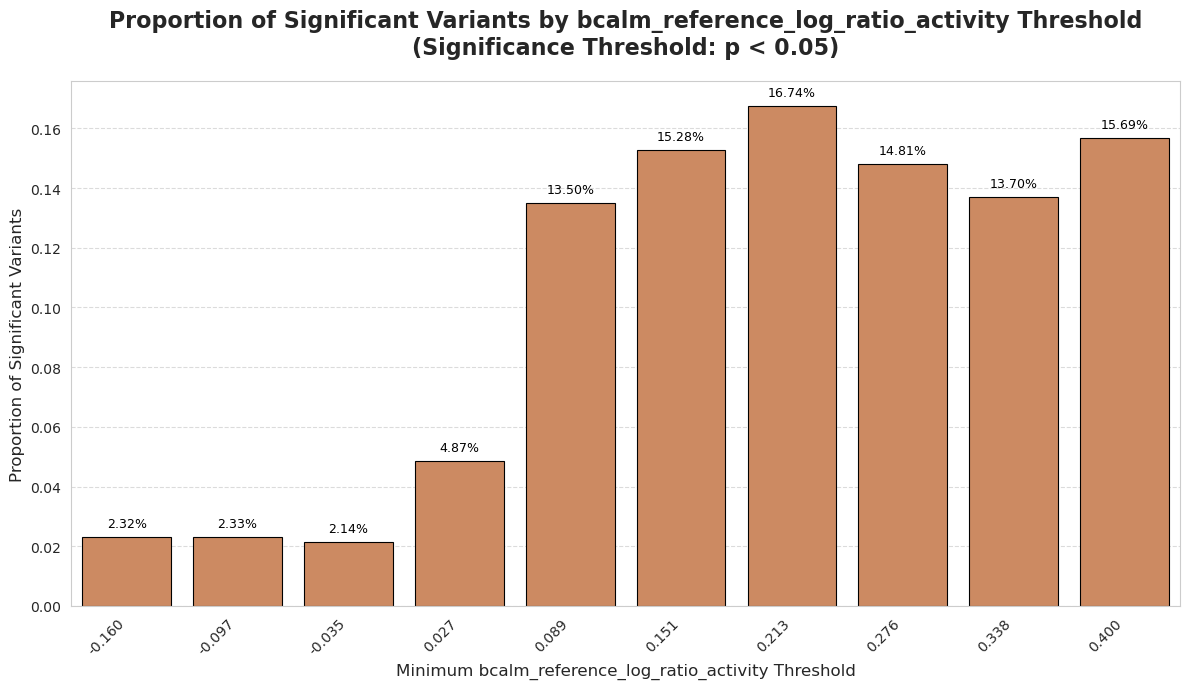

In [ ]:
import seaborn as sns
results_df = plot_proportion_significant_by_activity(
    variant_info_80k_gnomad,
    num_activity_thresholds=10, # Fewer bars
    custom_bar_color='#DE8650', # Tomato red
    min_activity=variant_info_80k_gnomad['bcalm_reference_log_ratio_activity'].min(),
    max_activity=0.4
)

In [44]:
results_df

,Reference Activity Threshold,Proportion of Significant Variants,Total Variants in Bin,Significant Variants in Bin
0,-0.159550,0.023220,41602,966
1,-0.097378,0.023271,41082,956
2,-0.035206,0.021436,29996,643
3,0.026966,0.048658,4768,232
4,0.089139,0.135036,822,111
5,0.151311,0.152815,373,57
6,0.213483,0.167382,233,39
7,0.275655,0.148148,162,24
8,0.337828,0.136986,73,10
9,0.400000,0.156863,51,8


With normalized activity scores: 

In [23]:
all_ref_with_normalized_activity_screen_info = pd.read_csv("/home/kisa/coding/80K_MPRA/cCREs_overlap/SCREEN_tissue/ngn2_80k_no_alternative_normalized_scrambled_activity_screen_info.tsv.gz", sep="\t")
all_ref_with_normalized_activity_screen_info.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl',
       'is_NPC_SCREEN_cCRE', 'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE',
       'is_neural_stem_SCREEN_cCRE', 'is_excitatory_neuron_SCREEN_cCRE',
       'is_npc_or_excitatory_NSC_SCREEN_cre',
       'is_significantly_different_scrambled_ctrl'],
      dtype='object')

In [33]:
all_ref_with_normalized_activity_screen_info.shape[0]

25578

In [ ]:
all_ref_with_normalized_activity_screen_info

In [ ]:
variant_info_80k_gnomad['ref_sequence'].nunique() # 18572

18572

In [26]:
variant_info_80k_gnomad

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label,gnomad_AC,gnomad_AF,variant_group,effect_bin,is_singleton
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,0.022133,0.131536,5.965362e-07,0.190591,cardiac_neuro_cava_random,71917.0,0.472883,common,NaN,False
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random,2617.0,0.017203,ultra-rare,NaN,False
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random,1.0,0.000007,singleton,NaN,True
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,-0.068107,1.000000e+00,-0.072051,cardiac_neuro_cava_random,1.0,0.000007,singleton,"(-0.225, 0.0557]",True
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,0.001944,1.000000e+00,-0.005889,cardiac_neuro_cava_random,7205.0,0.047348,ultra-rare,"(-0.225, 0.0557]",False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.911154,-0.076406,0.015993,0.100370,4.511542e-01,0.065547,cardiac_neuro_cava_random,1.0,0.000009,singleton,"(-0.225, 0.0557]",True
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.748684,-0.153448,1.000000,-0.080632,9.174673e-02,-0.090558,cardiac_neuro_cava_random,1.0,0.000009,singleton,"(-0.225, 0.0557]",True
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.989551,0.007846,0.409652,0.056209,4.362900e-01,0.052674,cardiac_neuro_cava_random,1.0,0.000009,singleton,"(-0.225, 0.0557]",True
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.514030,-0.243036,0.409652,0.056209,1.000000e+00,0.016824,cardiac_neuro_cava_random,2.0,0.000018,ultra-rare,"(-0.505, -0.225]",False


In [38]:
variant_info_80k_gnomad_tested = variant_info_80k_gnomad.loc[variant_info_80k_gnomad['bcalm_variant_effect_data_exists']].copy()

In [39]:
variant_info_80k_gnomad_ref_normalized = variant_info_80k_gnomad_tested.merge(all_ref_with_normalized_activity_screen_info[['sequence', 'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl']], left_on='ref_sequence', right_on='sequence', how='left')
variant_info_80k_gnomad_ref_normalized["bcalm_element_log_ratio_activity_z_score_scrambled_ctrl"].isna().sum()

0

In [40]:
variant_info_80k_gnomad_ref_normalized.loc[variant_info_80k_gnomad_ref_normalized["bcalm_element_log_ratio_activity_z_score_scrambled_ctrl"].isna()]

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,...,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label,gnomad_AC,gnomad_AF,variant_group,effect_bin,is_singleton,sequence,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl


In [ ]:
variant_info_80k_gnomad_ref_normalized['bcalm_element_log_ratio_activity_z_score_scrambled_ctrl']

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,...,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label,gnomad_AC,gnomad_AF,variant_group,effect_bin,is_singleton,sequence,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,...,1.000000,-0.072051,cardiac_neuro_cava_random,1.0,0.000007,singleton,"(-0.225, 0.0557]",True,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,-1.369454
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,...,1.000000,-0.005889,cardiac_neuro_cava_random,7205.0,0.047348,ultra-rare,"(-0.225, 0.0557]",False,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,0.442077
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[71],True,0.779710,-0.130556,1.000000,...,1.000000,-0.065999,cardiac_neuro_cava_random,1.0,0.000007,singleton,"(-0.225, 0.0557]",True,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,-0.981619
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[144],True,0.953076,-0.034817,1.000000,...,1.000000,-0.074918,cardiac_neuro_cava_random,4.0,0.000026,ultra-rare,"(-0.225, 0.0557]",False,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,-0.981619
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[183],True,0.632794,-0.167928,1.000000,...,1.000000,-0.060033,cardiac_neuro_cava_random,6.0,0.000039,ultra-rare,"(-0.225, 0.0557]",False,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,-0.981619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37865,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.911154,-0.076406,0.015993,...,0.451154,0.065547,cardiac_neuro_cava_random,1.0,0.000009,singleton,"(-0.225, 0.0557]",True,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,2.987397
37866,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.748684,-0.153448,1.000000,...,0.091747,-0.090558,cardiac_neuro_cava_random,1.0,0.000009,singleton,"(-0.225, 0.0557]",True,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,-1.693358
37867,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.989551,0.007846,0.409652,...,0.436290,0.052674,cardiac_neuro_cava_random,1.0,0.000009,singleton,"(-0.22

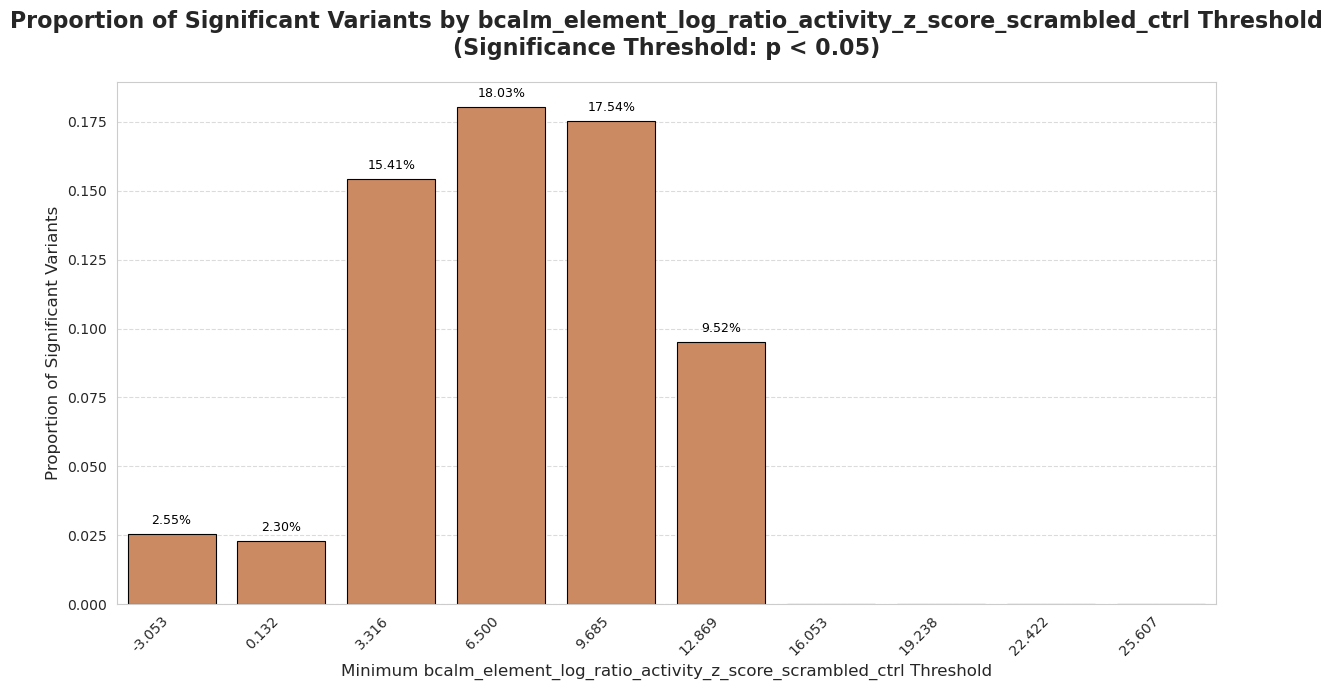

In [46]:
import seaborn as sns
results_df = plot_proportion_significant_by_activity(
    variant_info_80k_gnomad_ref_normalized,
    num_activity_thresholds=10, # Fewer bars
    custom_bar_color='#DE8650', # Tomato red
    activity_col='bcalm_element_log_ratio_activity_z_score_scrambled_ctrl',
    min_activity=variant_info_80k_gnomad_ref_normalized['bcalm_element_log_ratio_activity_z_score_scrambled_ctrl'].min(),
    max_activity=variant_info_80k_gnomad_ref_normalized['bcalm_element_log_ratio_activity_z_score_scrambled_ctrl'].max()
)

In [48]:
variant_info_80k_gnomad_bcalm_exists['bcalm_reference_log_ratio_activity'].max()

0.975037422249622

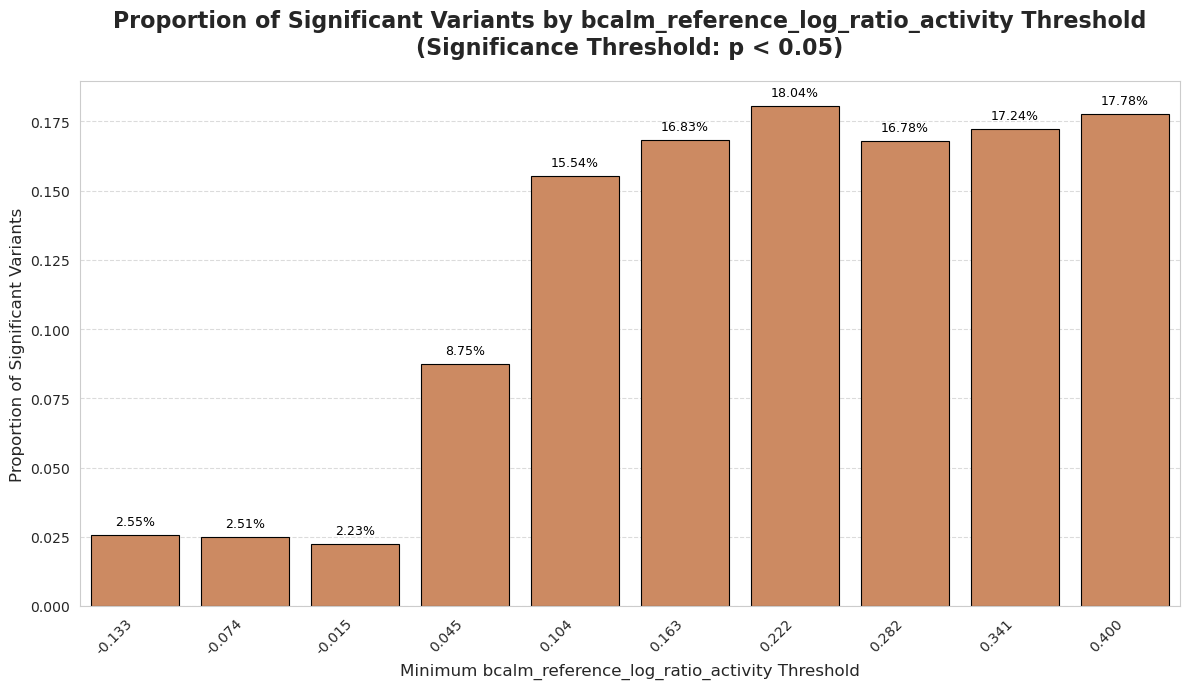

In [50]:
results_df = plot_proportion_significant_by_activity(
    variant_info_80k_gnomad_bcalm_exists,
    num_activity_thresholds=10, # Fewer bars
    custom_bar_color='#DE8650', # Tomato red
    min_activity=variant_info_80k_gnomad_bcalm_exists['bcalm_reference_log_ratio_activity'].min(),
    max_activity=0.4
)

In [70]:
results_df

,Reference Activity Threshold,Proportion of Significant Variants,Total Variants in Bin,Significant Variants in Bin
0,-0.133192,0.025508,37870,966
1,-0.073948,0.025070,35501,890
2,-0.014705,0.022306,21698,484
3,0.044539,0.087518,2091,183
4,0.103782,0.155372,605,94
5,0.163026,0.168285,309,52
6,0.222269,0.180412,194,35
7,0.281513,0.167832,143,24
8,0.340756,0.172414,58,10
9,0.400000,0.177778,45,8


In [22]:
def plot_volcano(BCalm_table, title, logFC_col, adj_p_val_col, significants_niveau=0.1, ylim_max=11, ylim_min=-0.025, xlim_min=-1, xlim_max=1, sig_dot_size=8):
    BCalm_table['BCalm_true'] = np.where((BCalm_table[logFC_col] > 0) & (BCalm_table[adj_p_val_col] < significants_niveau), 'positive', 'neutral')
    BCalm_table['BCalm_true'] = np.where((BCalm_table[logFC_col] < 0) & (BCalm_table[adj_p_val_col] < significants_niveau), 'negative', BCalm_table['BCalm_true'])

    significant_BCalm_table = BCalm_table[BCalm_table[adj_p_val_col] < significants_niveau]
    up = BCalm_table[BCalm_table['BCalm_true'] == 'positive']
    down = BCalm_table[BCalm_table['BCalm_true'] == 'negative']

    plt.figure(figsize=(15,10))
    # make background dark for the plot
    # plt.style.use('dark_background')
    # plt.style.use("Solarize_Light2")
    ax = plt.gca()
    plt.style.use("ggplot")
    plt.scatter(x=BCalm_table[logFC_col],y=BCalm_table[adj_p_val_col].apply(lambda x:-np.log10(x)),s=1,label=f"BCalm not significant ({int(round(significants_niveau*100, 2))}% FDR)", color="grey")
    plt.scatter(x=down[logFC_col],y=down[adj_p_val_col].apply(lambda x:-np.log10(x)),s=sig_dot_size,label="BCalm negative effect" + " (n=" + str(down.shape[0]) + ")",color="black")
    plt.scatter(x=up[logFC_col],y=up[adj_p_val_col].apply(lambda x:-np.log10(x)),s=sig_dot_size,label="BCalm positive effect"+ " (n=" + str(up.shape[0]) + ")",color="orange")
    # scatter for controls
    # plt.scatter()


    # Keep x-axis between -4, 4
    # keep y-axis between 0, 4
    ax.set_xlim([xlim_min,xlim_max])
    ax.set_ylim([ylim_min,ylim_max])
    # increase font size
    plt.rcParams.update({'font.size': 15})
    # increase font size of labels and ticks
    plt.tick_params(axis='both', which='major', labelsize=15)
    # plt.style.use('dark_background')
    # plt.style.use("Solarize_Light2")
    plt.style.use("ggplot")
    plt.xlabel("logFC")
    plt.ylabel("-logFDR")
    plt.axhline(-math.log10(significants_niveau),color="grey",linestyle="--")
    plt.title(f"{title} (n={BCalm_table.shape[0]}, sig: {round(significant_BCalm_table.shape[0]/BCalm_table.shape[0]*100, 0)}%)", fontsize=20)
    plt.legend()
    plt.show()

In [23]:
variant_info_80k_gnomad.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_AC',
       'gnomad_AF', 'variant_group'],
      dtype='object')

In [24]:
variant_info_80k_gnomad_bcalm_exists = variant_info_80k_gnomad.loc[variant_info_80k_gnomad['bcalm_variant_effect_data_exists']].copy()

In [ ]:
669 + 635

1304

In [ ]:
669/1304


0.5130368098159509

In [ ]:
635

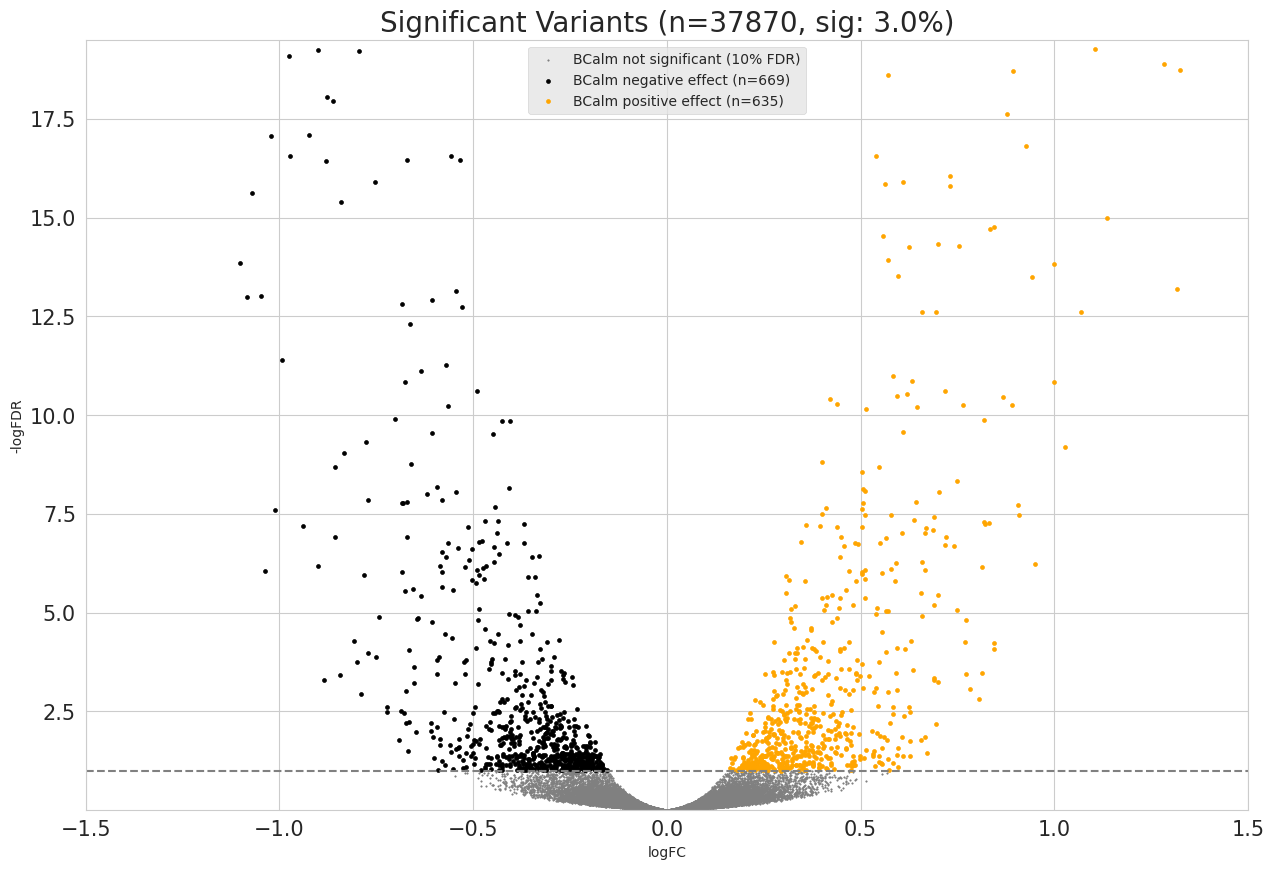

In [25]:
plot_volcano(variant_info_80k_gnomad_bcalm_exists, "Significant Variants", logFC_col="bcalm_variant_effect_log_ratio_activity", adj_p_val_col="bcalm_variant_effect_adjusted_p_value", significants_niveau=0.1, xlim_min=-1.5, xlim_max=1.5, ylim_min=0.01, ylim_max=19.5)

In [26]:
ref_sig_threshold = 0.05
variants_with_active_reference = variant_info_80k_gnomad.loc[variant_info_80k_gnomad["bcalm_reference_adjusted_p_value"] < ref_sig_threshold]
variants_with_active_reference # 2,311
print("Minimum reference activity of significant sequences: ", variants_with_active_reference['bcalm_reference_log_ratio_activity'].min())

Minimum reference activity of significant sequences:  -0.159550342614432


In [27]:
(variants_with_active_reference['bcalm_variant_effect_adjusted_p_value'] < 0.1).sum()

207

In [ ]:
130/207

0.6280193236714976

/tmp/ipykernel_513675/3691669484.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BCalm_table['BCalm_true'] = np.where((BCalm_table[logFC_col] > 0) & (BCalm_table[adj_p_val_col] < significants_niveau), 'positive', 'neutral')
/tmp/ipykernel_513675/3691669484.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BCalm_table['BCalm_true'] = np.where((BCalm_table[logFC_col] < 0) & (BCalm_table[adj_p_val_col] < significants_niveau), 'negative', BCalm_table['BCalm_true'])


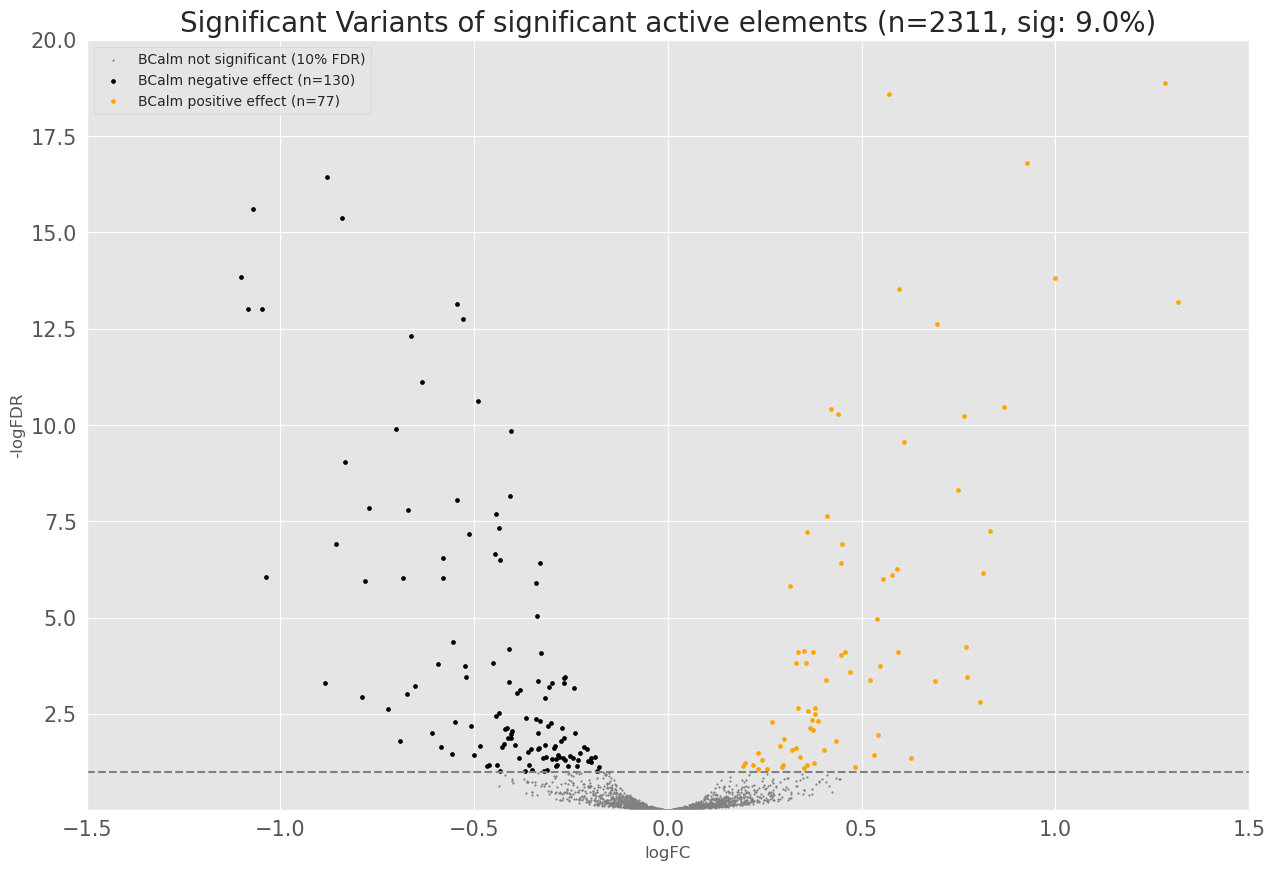

In [28]:
plot_volcano(variants_with_active_reference, "Significant Variants of significant active elements", logFC_col="bcalm_variant_effect_log_ratio_activity", adj_p_val_col="bcalm_variant_effect_adjusted_p_value", significants_niveau=0.1, xlim_min=-1.5, xlim_max=1.5, ylim_min=0.01, ylim_max=20)

In [29]:
variant_info_80k_gnomad_high_ref = variant_info_80k_gnomad.loc[variant_info_80k_gnomad['bcalm_reference_log_ratio_activity'] >= reference_threshold].copy()

In [30]:
print("Number of variants with measurements: ", variant_info_80k_gnomad.shape[0])
variant_info_80k_gnomad['variant_group'].value_counts()

Number of variants with measurements:  46374


variant_group
ultra-rare    12236
common        12145
singleton     12137
rare           9856
Name: count, dtype: int64

In [31]:
print(f"Number of variants with a high reference allele (threshold {round(reference_threshold,3)}): ", variant_info_80k_gnomad_high_ref.shape[0])
variant_info_80k_gnomad_high_ref['variant_group'].value_counts()

Number of variants with a high reference allele (threshold -0.01):  20801


variant_group
singleton     5642
ultra-rare    5465
common        5373
rare          4321
Name: count, dtype: int64

#### Singleton enrichment

/tmp/ipykernel_513675/823045617.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = variant_df.groupby('effect_bin').agg(
/tmp/ipykernel_513675/823045617.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='effect_bin', y='proportion_variants', data=bin_summary, palette='viridis')


Summary of Common Proportion per Effect Bin:
         effect_bin  total_variants  sum_variants  proportion_variants
0  (-1.347, -1.065]               8             2             0.250000
1  (-1.065, -0.785]              18             5             0.277778
2  (-0.785, -0.505]              58            16             0.275862
3  (-0.505, -0.225]             930           238             0.255914
4  (-0.225, 0.0557]           14205          3863             0.271946
5   (0.0557, 0.336]            4309          1229             0.285217
6    (0.336, 0.616]             115            44             0.382609
7    (0.616, 0.897]              14             4             0.285714
8    (0.897, 1.177]              12             5             0.416667
9    (1.177, 1.457]               5             3             0.600000


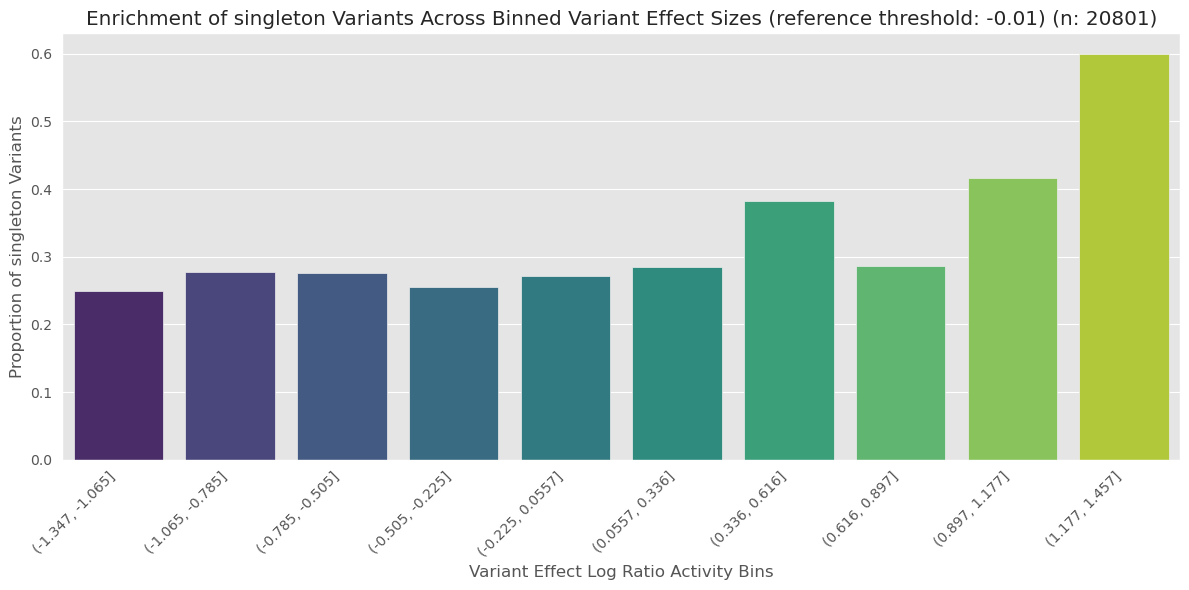

/tmp/ipykernel_513675/823045617.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = variant_df.groupby('effect_bin').agg(
/tmp/ipykernel_513675/823045617.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='effect_bin', y='proportion_variants', data=bin_summary, palette='viridis')


Summary of Common Proportion per Effect Bin:
         effect_bin  total_variants  sum_variants  proportion_variants
0  (-1.347, -1.065]               8             2             0.250000
1  (-1.065, -0.785]              31            11             0.354839
2  (-0.785, -0.505]             103            28             0.271845
3  (-0.505, -0.225]            1739           447             0.257044
4  (-0.225, 0.0557]           24628          6608             0.268312
5   (0.0557, 0.336]           10778          2831             0.262665
6    (0.336, 0.616]             494           141             0.285425
7    (0.616, 0.897]              68            26             0.382353
8    (0.897, 1.177]              15             6             0.400000
9    (1.177, 1.457]               6             4             0.666667


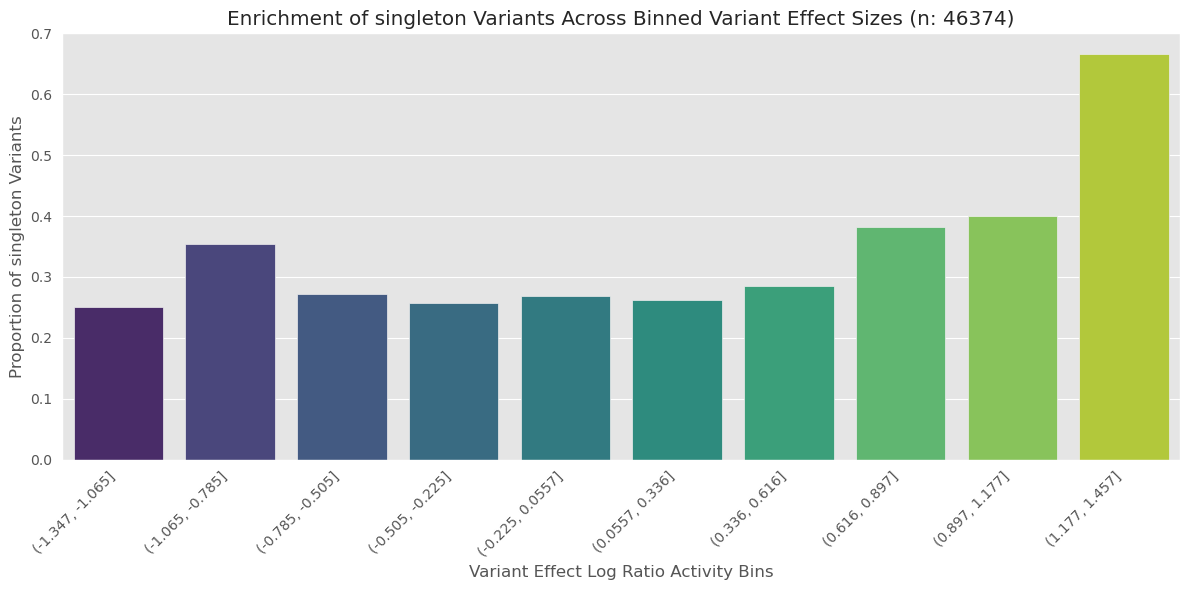

In [32]:
plot_binned_variant_group_specific_enrichment(variant_info_80k_gnomad_high_ref, variant_group_list=["singleton"], plot_title = f"Enrichment of singleton Variants Across Binned Variant Effect Sizes (reference threshold: {round(reference_threshold,3)})", plot_y_axis_title="Proportion of singleton Variants")
plot_binned_variant_group_specific_enrichment(variant_info_80k_gnomad, variant_group_list=["singleton"], plot_title = "Enrichment of singleton Variants Across Binned Variant Effect Sizes", plot_y_axis_title="Proportion of singleton Variants")

#### Common enrichment

/tmp/ipykernel_513675/823045617.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = variant_df.groupby('effect_bin').agg(
/tmp/ipykernel_513675/823045617.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='effect_bin', y='proportion_variants', data=bin_summary, palette='viridis')


Summary of Common Proportion per Effect Bin:
         effect_bin  total_variants  sum_variants  proportion_variants
0  (-1.347, -1.065]               8             3             0.375000
1  (-1.065, -0.785]              18             4             0.222222
2  (-0.785, -0.505]              58            10             0.172414
3  (-0.505, -0.225]             930           248             0.266667
4  (-0.225, 0.0557]           14205          3671             0.258430
5   (0.0557, 0.336]            4309          1078             0.250174
6    (0.336, 0.616]             115            15             0.130435
7    (0.616, 0.897]              14             2             0.142857
8    (0.897, 1.177]              12             2             0.166667
9    (1.177, 1.457]               5             1             0.200000


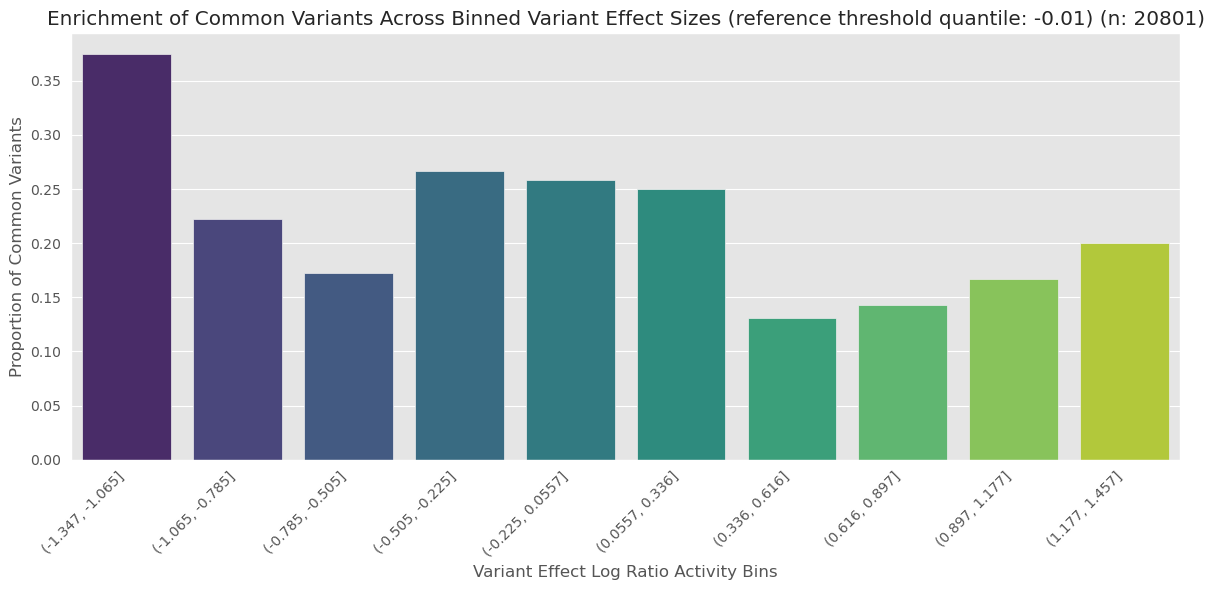

/tmp/ipykernel_513675/823045617.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = variant_df.groupby('effect_bin').agg(
/tmp/ipykernel_513675/823045617.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='effect_bin', y='proportion_variants', data=bin_summary, palette='viridis')


Summary of Common Proportion per Effect Bin:
         effect_bin  total_variants  sum_variants  proportion_variants
0  (-1.347, -1.065]               8             3             0.375000
1  (-1.065, -0.785]              31             7             0.225806
2  (-0.785, -0.505]             103            23             0.223301
3  (-0.505, -0.225]            1739           459             0.263945
4  (-0.225, 0.0557]           24628          6405             0.260070
5   (0.0557, 0.336]           10778          2816             0.261273
6    (0.336, 0.616]             494           112             0.226721
7    (0.616, 0.897]              68             7             0.102941
8    (0.897, 1.177]              15             3             0.200000
9    (1.177, 1.457]               6             1             0.166667


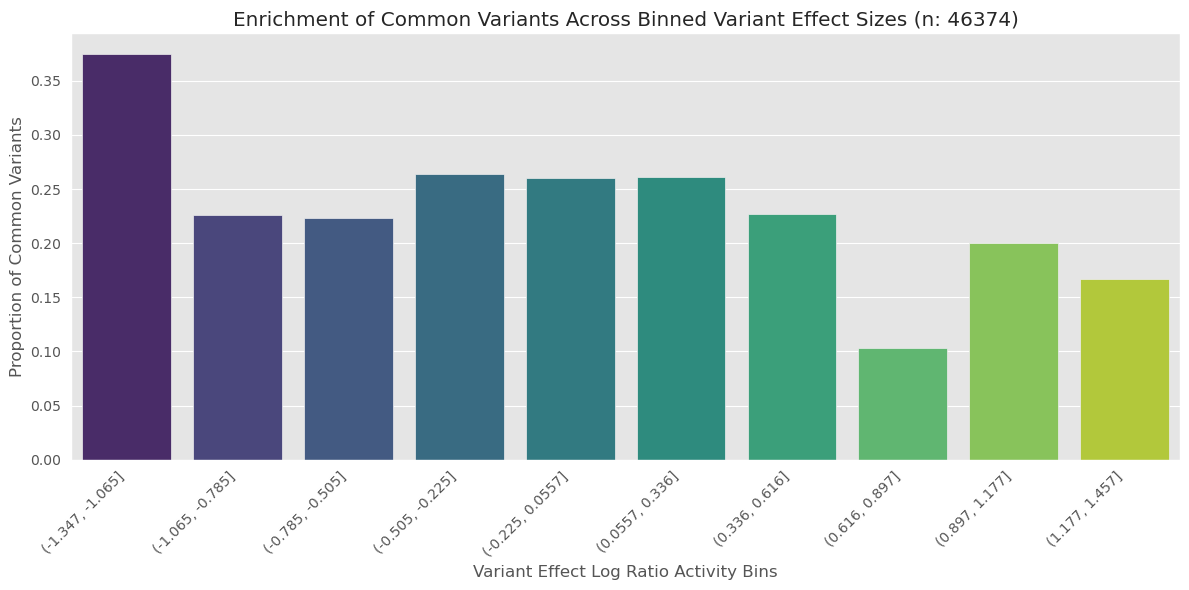

In [33]:
plot_binned_variant_group_specific_enrichment(variant_info_80k_gnomad_high_ref, variant_group_list=["common"], plot_title = f"Enrichment of Common Variants Across Binned Variant Effect Sizes (reference threshold quantile: {round(reference_threshold,3)})", plot_y_axis_title="Proportion of Common Variants")
plot_binned_variant_group_specific_enrichment(variant_info_80k_gnomad, variant_group_list=["common"], plot_title = "Enrichment of Common Variants Across Binned Variant Effect Sizes", plot_y_axis_title="Proportion of Common Variants")

/tmp/ipykernel_513675/823045617.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = variant_df.groupby('effect_bin').agg(
/tmp/ipykernel_513675/823045617.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='effect_bin', y='proportion_variants', data=bin_summary, palette='viridis')


Summary of Common Proportion per Effect Bin:
         effect_bin  total_variants  sum_variants  proportion_variants
0  (-1.347, -1.065]               8             0             0.000000
1  (-1.065, -0.785]              31             5             0.161290
2  (-0.785, -0.505]             103            16             0.155340
3  (-0.505, -0.225]            1739           367             0.211041
4  (-0.225, 0.0557]           24628          5169             0.209883
5   (0.0557, 0.336]           10778          2218             0.205790
6    (0.336, 0.616]             494            97             0.196356
7    (0.616, 0.897]              68            12             0.176471
8    (0.897, 1.177]              15             0             0.000000
9    (1.177, 1.457]               6             1             0.166667


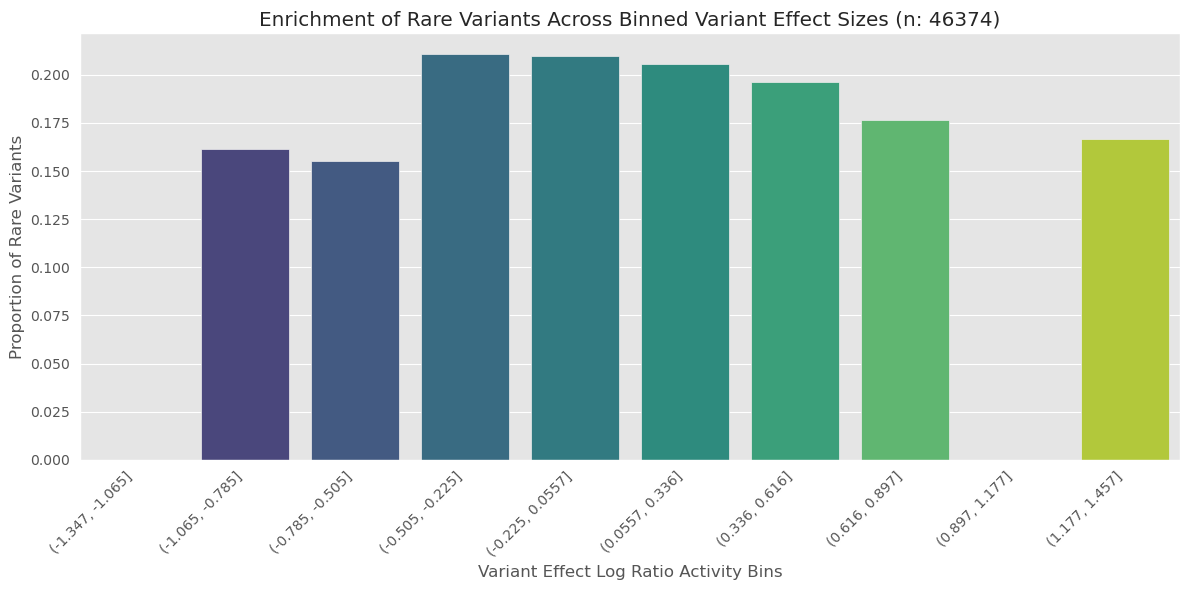

In [34]:
plot_binned_variant_group_specific_enrichment(variant_info_80k_gnomad, variant_group_list=["rare"], plot_title = "Enrichment of Rare Variants Across Binned Variant Effect Sizes", plot_y_axis_title="Proportion of Rare Variants")

#### Use the enformer class information: 
- Only enformer random singleton and ultra rare variants

In [35]:
variant_info_80k_gnomad['chr_pos_ref_alt'] = variant_info_80k_gnomad['ALT'].apply(hf.get_chrom_pos_ref_alt_pattern)
# concat all files and compute the enrichment
from os import listdir
path_to_enformer_files = "/home/kisa/coding/80K_MPRA/enformer_data/adjusted_random_sampling"
all_enformer_prioritization_files = [os.path.join(path_to_enformer_files, file) for file in listdir(path_to_enformer_files) if file.startswith("enformer_prio_class_")]
all_enformer_prio_df = pd.concat([pd.read_csv(file, sep="\t", low_memory=False) for file in all_enformer_prioritization_files])

In [36]:
all_enformer_prio_df.columns

Index(['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO',
       'chr_pos_ref_alt', 'DNase_max', 'max_col', 'enformer_variant_info',
       'enformer_class_list', 'gene_set_list', 'variant_type_list', 'gene_set',
       'variant_type', 'enformer_class', 'new_enformer_class'],
      dtype='object')

In [37]:
variant_info_80k_gnomad

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label,gnomad_AC,gnomad_AF,variant_group,effect_bin,is_variant_group,chr_pos_ref_alt
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,0.022133,0.131536,5.965362e-07,0.190591,cardiac_neuro_cava_random,71917.0,0.472883,common,NaN,False,1-2179591-T-C
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random,2617.0,0.017203,rare,NaN,True,1-2191444-G-A
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random,1.0,0.000007,singleton,NaN,False,1-2192015-G-T
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,-0.068107,1.000000e+00,-0.072051,cardiac_neuro_cava_random,1.0,0.000007,singleton,"(-0.225, 0.0557]",False,1-2192366-T-G
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,0.001944,1.000000e+00,-0.005889,cardiac_neuro_cava_random,7205.0,0.047348,rare,"(-0.225, 0.0557]",True,1-2193142-G-A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.911154,-0.076406,0.015993,0.100370,4.511542e-01,0.065547,cardiac_neuro_cava_random,1.0,0.000009,singleton,"(-0.225, 0.0557]",False,X-154545206-A-G
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.748684,-0.153448,1.000000,-0.080632,9.174673e-02,-0.090558,cardiac_neuro_cava_random,1.0,0.000009,singleton,"(-0.225, 0.0557]",False,X-154549923-T-G
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.989551,0.007846,0.409652,0.056209,4.362900e-01,0.052674,cardiac_neuro_cava_random,1.0,0.000009,singleton,"(-0.225, 0.0557]",False,X-154552289-C-T
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.514030,-0.243036,0.409652,0.056209,1.000000e+00,0.016824,cardiac_neuro_cava_random,2.0,0.000

In [38]:
variant_info_80k_gnomad.columns
variant_info_80k_gnomad['variant_group'].value_counts()

variant_group
ultra-rare    12236
common        12145
singleton     12137
rare           9856
Name: count, dtype: int64

In [39]:
variant_info_80k_gnomad.shape[0]

46374

In [40]:
all_enformer_prio_df['chr_pos_ref_alt'].duplicated().sum() # 0

900

In [41]:
all_enformer_prio_df_duplicates = all_enformer_prio_df.loc[all_enformer_prio_df['chr_pos_ref_alt'].duplicated(keep=False)].copy()
all_enformer_prio_df_duplicates


# Group by 'chr_pos_ref_alt' and aggregate 'new_enformer_class' into a list
resolved_df = all_enformer_prio_df_duplicates.groupby('chr_pos_ref_alt')['new_enformer_class'].apply(lambda x: sorted(list(x.unique()))).reset_index()

# You might want to rename the aggregated column for clarity
resolved_df.rename(columns={'new_enformer_class': 'enformer_classes_list'}, inplace=True)

resolved_df

,chr_pos_ref_alt,enformer_classes_list
0,1-114669283-T-C,[enformer_high]
1,1-114670717-T-C,[enformer_high]
2,1-114702865-G-A,[enformer_high]
3,1-114703398-A-G,[enformer_high]
4,1-114703527-A-C,[enformer_high]
...,...,...
854,7-140727734-C-A,[enformer_high]
855,7-140773444-T-A,[enformer_low]
856,7-140908711-G-C,[enformer_low]
857,7-140913199-A-C,[enformer_high]


I deduplicated the enformer class information, because of the fixing of the random sampling some variants were now enformer random in the one case and enformer high/ enformer low in the other case.

In [42]:
# Group by 'chr_pos_ref_alt' and aggregate 'new_enformer_class' into a list
resolved_df = all_enformer_prio_df.groupby('chr_pos_ref_alt')['new_enformer_class'].apply(lambda x: sorted(list(x.unique()))).reset_index()

# You might want to rename the aggregated column for clarity
resolved_df.rename(columns={'new_enformer_class': 'enformer_classes_list'}, inplace=True)


resolved_df
all_enformer_prio_df_deduplicated = pd.merge(
    all_enformer_prio_df,
    resolved_df,
    on='chr_pos_ref_alt',
    how='left'
)

# drop gene_info, enformer_class
all_enformer_prio_df_deduplicated = all_enformer_prio_df_deduplicated.drop(columns=['gene_set', 'enformer_class', 'new_enformer_class'])
# drop all duplicates
all_enformer_prio_df_deduplicated = all_enformer_prio_df_deduplicated.drop_duplicates(subset='chr_pos_ref_alt', keep='first').copy()


In [43]:
all_enformer_prio_df_deduplicated

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list,variant_type,enformer_classes_list
0,chr1,156124748,LMNA|ENSG00000160789.24|EH38E1387661|1-1561247...,G,C,1,PASS,AF=6.57307e-06;AC=1,1-156124748-G-C,1504.938200,"177_DNASE:CD8-positive,","('cava', 'singleton', 'enformer_high')",['enformer_high'],"['cava', 'cardiac']",['singleton'],singleton,[enformer_high]
1,chr1,156156383,LMNA|ENSG00000160789.24|EH38E2840566|1-1561563...,C,T,1,PASS,AF=6.57108e-06;AC=1,1-156156383-C-T,1496.744800,588_DNASE:hematopoietic,"('cava', 'singleton', 'enformer_high')",['enformer_high'],"['cava', 'cardiac']",['singleton'],singleton,[enformer_high]
2,chr1,156150903,LMNA|ENSG00000160789.24|EH38E2840557|1-1561509...,G,T,1,PASS,AF=6.57454e-06;AC=1,1-156150903-G-T,1260.145100,392_DNASE:CD14-positive,"('cava', 'singleton', 'enformer_high')",['enformer_high'],"['cava', 'cardiac']",['singleton'],singleton,[enformer_high]
3,chr1,156106910,LMNA|ENSG00000160789.24|EH38E1387629|1-1561069...,T,C,1,PASS,AF=6.57255e-06;AC=1,1-156106910-T-C,1013.583000,"177_DNASE:CD8-positive,","('cava', 'singleton', 'enformer_high')",['enformer_high'],"['cava', 'cardiac']",['singleton'],singleton,[enformer_high]
4,chr16,2015389,TSC2|ENSG00000103197.18|EH38E3162684|16-201538...,C,T,1,PASS,AF=6.57687e-06;AC=1,16-2015389-C-T,1011.779360,392_DNASE:CD14-positive,"('cava', 'singleton', 'enformer_high')",['enformer_high'],"['neuro', 'cava', 'cardiac']",['singleton'],singleton,[enformer_high]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34993,chr8,89982689,NBN|ENSG00000104320.15|EH38E3844153|8-89982689...,C,G,1,PASS,AF=2.62878e-05;AC=4,8-89982689-C-G,0.393892,24_DNASE:HeLa-S3 treate,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],['cava'],['ultra-rare'],ultra-rare,[enformer_low]
34994,chrX,154549094,G6PD|ENSG00000160211.20|EH38E3949743|X-1545490...,C,T,1,PASS,AF=2.8056e-05;AC=3,X-154549094-C-T,0.373219,27_DNASE:HepG2,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],['cava'],['ultra-rare'],ultra-rare,[enformer_low]
34995,chr22,42130581,CYP2D6|ENSG00000100197.23|EH38E3484171|22-4213...,C,G,1,PASS,AF=1.47037e-05;AC=2,22-42130581-C-G,0.372479,119_DNASE:fibroblast of,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],['cava'],['ultra-rare'],ultra-rare,[enformer_low]
34996,chr10,94800854,CYP2C19|ENSG00000165841.11|EH38E2917481|10-948...,C,T,1,PASS,AF=3.94177e-05;AC=6,10-94800854-C-T,0.361084,88_DNASE:HCT116,"('cava', 'ultra-rare', 'enformer_low')",['enformer_low'],['cava'],['ultra-rare'],ultra-rare,[enformer_low]


In [44]:
all_enformer_prio_df_deduplicated['enformer_class_list'][0]
all_enformer_prio_df_deduplicated['enformer_class_list'] = all_enformer_prio_df_deduplicated['enformer_class_list'].apply(safe_eval)
type(all_enformer_prio_df_deduplicated['enformer_class_list'][0])

list

In [45]:
enformer_fixed_random = "/home/kisa/coding/80K_MPRA/enformer_data/enformer_prioritized_variants_fixed_random_sampling.tsv.gz"
writing=False
if writing:
    all_enformer_prio_df_deduplicated.to_csv(enformer_fixed_random, sep="\t", index=None)


In [46]:
all_enformer_prio_df_deduplicated['chr_pos_ref_alt'].duplicated().sum()

0

In [126]:
variant_info_80k_gnomad.shape

(46374, 20)

In [125]:
variant_info_80k_enformer = variant_info_80k_gnomad.merge(all_enformer_prio_df_deduplicated[['chr_pos_ref_alt', 'DNase_max', 'max_col', 'enformer_variant_info', 'enformer_class_list', 'gene_set_list', 'variant_type_list', 'variant_type', 'enformer_classes_list']], on="chr_pos_ref_alt", how="left").copy()

In [127]:
variant_info_80k_enformer.shape

(46374, 28)

### Compute the enformer enrichment and plot it

In [87]:
variant_info_80k_enformer.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_AC',
       'gnomad_AF', 'variant_group', 'effect_bin', 'is_variant_group',
       'chr_pos_ref_alt', 'DNase_max', 'max_col', 'enformer_variant_info',
       'enformer_class_list', 'gene_set_list', 'variant_type_list',
       'variant_type', 'enformer_classes_list'],
      dtype='object')

In [128]:
variant_info_80k_enformer['variant_type'].value_counts()

variant_type
ultra-rare    12236
singleton     12137
Name: count, dtype: int64

In [89]:
variant_info_80k_enformer['variant_group'].value_counts()

variant_group
ultra-rare    12236
common        12145
singleton     12137
rare           9856
Name: count, dtype: int64

In [90]:
variant_info_80k_enformer['max_col'].isna().sum()
# which sequences can not be matched: expectation only sequences which are in the variant group "common"
variant_info_80k_enformer_no_match = variant_info_80k_enformer.loc[variant_info_80k_enformer['max_col'].isna()].copy()
variant_info_80k_enformer_no_match['variant_group'].value_counts()

variant_group
common    12145
rare       9856
Name: count, dtype: int64

In [91]:
variant_info_80k_enformer_no_match

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,...,is_variant_group,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list,variant_type,enformer_classes_list
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,0.022133,...,False,1-2179591-T-C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,...,True,1-2191444-G-A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,...,True,1-2193142-G-A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,ATTCGATGGTGCGGGAGGTGGCCGGCAGGGTTGGGGGAAGGGCTGC...,ATTCGATGGTGCGGGAGGTGGCCGGCAGGGTTGGGGGAAGGGCTGC...,[95],False,NaN,NaN,NaN,...,True,1-2194344-T-G,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GCCTGGCAACCTTCCCCGGGGCCAGAGGGCAGCCCAGGGTCCCGAG...,GCCTGGCAACCTTCCCCGGGGCCAGAGGGCAGCCCAGGGTCCCGAG...,[120],False,NaN,NaN,1.000000,...,True,1-2203222-G-A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46323,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGGACTGGGTTCCGGTTCATCCTCCTCCACCCTGCCGTGTGTGTG...,ATGGACTGGGTTCCGGTTCATCCTCCTCCACCCTGCCGTGTGTGTG...,[203],False,NaN,NaN,NaN,...,True,X-154484350-A-T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46326,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATAGAATTTAACGATGGACTTCAGGTAGACTTAGTCTGAGTGCAAC...,ATAGAATTTAACGATGGACTTCAGGTAGACTTAGTCTGAGTGCAAC...,[62],True,0.597014,-0.157300,1.000000,...,False,X-154497009-A-G,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46332,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATTTTATATCAGGGACTTGAGCATCCCTGGACTTTGGCAGCTATAG...,ATTTTATATCAGGGACTTGAGCATCCCTGGACTTTGGCAGCTATAG...,[55],True,0.892308,-0.037095,1.000000,...,False,X-154503246-C-T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46364,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ACCCCACTGCTGCACCAGATTGAGCTGGAGAAGCCCAAGCCCATCC...,ACCCCACTGCTGCACCAGATTGAGCTGGAGAAGCCTAAGCCCATCC...,[35],False,NaN,NaN,1.000000,...,True,X-154532214-G-A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
variant_info_80k_enformer_matched = variant_info_80k_enformer.loc[variant_info_80k_enformer['max_col'].notna()].copy()
variant_info_80k_enformer_matched['variant_group'].value_counts()

variant_group
ultra-rare    12236
singleton     12137
Name: count, dtype: int64

In [129]:
def get_enformer_class_from_list(enformer_class_list):
    """"""
    if isinstance(enformer_class_list, list):
        if len(enformer_class_list) == 0:
            raise ValueError("enformer_class_list is empty, please check the input data.")
        elif len(enformer_class_list) == 1:
            return enformer_class_list[0]
        else:
            if "enformer_random" in enformer_class_list:
                # If the list contains "enformer_random", we return it as the class
                return "enformer_random"
            else:
                print(enformer_class_list)
                raise ValueError("enformer_class_list contains multiple classes, please check the input data.")
    else:
        raise ValueError("enformer_class_list should be a list")


variant_info_80k_enformer['enformer_class'] = variant_info_80k_enformer['enformer_classes_list'].apply(lambda x: pd.NA if x != x else get_enformer_class_from_list(x))

In [ ]:
variant_info_80k_enformer_prioritized = variant_info_80k_enformer.loc[variant_info_80k_enformer['enformer_class'].notna()].copy()
# write the enformer prioritized variant set to file for the new enformer scores
enformer_prioritized_path = "/home/kisa/coding/80K_MPRA/enformer_data/enformer_prioritized_variants_2025_04_adjusted_random_sampling.tsv.gz"

writing=False
if writing:
    variant_info_80k_enformer_prioritized[['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
        'bcalm_variant_effect_data_exists',
        'bcalm_variant_effect_adjusted_p_value',
        'bcalm_variant_effect_log_ratio_activity',
        'bcalm_reference_adjusted_p_value',
        'bcalm_reference_log_ratio_activity',
        'bcalm_alternative_adjusted_p_value',
        'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_AC',
        'gnomad_AF', 'variant_group',
        'chr_pos_ref_alt', 'DNase_max', 'max_col', 'enformer_variant_info', 'gene_set_list', 'variant_type_list',
        'variant_type', 'enformer_classes_list', 'enformer_class']].to_csv(enformer_prioritized_path, sep="\t", index=None)


In [ ]:
variant_info_80k_enformer_prioritized.columns



Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_AC',
       'gnomad_AF', 'variant_group', 'effect_bin', 'is_variant_group',
       'chr_pos_ref_alt', 'DNase_max', 'max_col', 'enformer_variant_info',
       'enformer_class_list', 'gene_set_list', 'variant_type_list',
       'variant_type', 'enformer_classes_list', 'enformer_class'],
      dtype='object')

In [ ]:
variant_info_80k_enformer['enformer_class'].value_counts()

variant_info_80k_enformer = variant_info_80k_enformer.loc[variant_info_80k_enformer['enformer_class'] != "deleted"].copy()

enformer_class
enformer_high      17176
enformer_random     3587
enformer_low        3092
deleted              518
Name: count, dtype: int64

In [131]:
variant_info_80k_enformer.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_AC',
       'gnomad_AF', 'variant_group', 'effect_bin', 'is_variant_group',
       'chr_pos_ref_alt', 'DNase_max', 'max_col', 'enformer_variant_info',
       'enformer_class_list', 'gene_set_list', 'variant_type_list',
       'variant_type', 'enformer_classes_list', 'enformer_class'],
      dtype='object')

In [106]:
variant_info_80k_enformer_prioritized = variant_info_80k_enformer_prioritized.loc[variant_info_80k_enformer_prioritized['bcalm_variant_effect_data_exists']].copy()

In [108]:
variant_info_80k_enformer_prioritized['enformer_class'].value_counts()

enformer_class
enformer_high      14291
enformer_random     2945
enformer_low        2490
Name: count, dtype: int64

In [109]:
variant_info_80k_enformer_prioritized["is_significant"] = variant_info_80k_enformer_prioritized['bcalm_variant_effect_adjusted_p_value'] < 0.1


In [122]:
n_sig_for_variant_group_prioritized = variant_info_80k_enformer_prioritized.groupby(["enformer_class", "is_significant"]).size().unstack(fill_value=0).reset_index()
n_sig_for_variant_group_prioritized['proportion'] = n_sig_for_variant_group_prioritized[True] / n_sig_for_variant_group_prioritized[False]
n_sig_for_variant_group_prioritized

is_significant,enformer_class,False,True,proportion
0,enformer_high,13700,591,0.043139
1,enformer_low,2426,64,0.026381
2,enformer_random,2864,81,0.028282


In [123]:
print("Enformer enrichment: For all variants: high vs all")

import scipy.stats as stats


# Count occurrences in total dataset
total_high = (variant_info_80k_enformer_prioritized["enformer_class"] == "enformer_high").sum()
total_non_high = len(variant_info_80k_enformer_prioritized) - total_high
print("Number of variants considered: ", variant_info_80k_enformer_prioritized.shape[0])
# Count occurrences in significant subset
sig_level = 0.05
sig_df = variant_info_80k_enformer_prioritized.loc[variant_info_80k_enformer_prioritized["bcalm_variant_effect_adjusted_p_value"] < sig_level].copy() # 175
print("Number of significant variants considered: ", sig_df.shape[0])

sig_high = (sig_df["enformer_class"] == "enformer_high").sum()
sig_non_high = len(sig_df) - sig_high


# Compute proportions
prop_high_sig = sig_high / len(sig_df)  # Proportion of "high" in significant rows
prop_high_total = total_high / len(variant_info_80k_enformer_prioritized)  # Proportion of "high" in total dataset
# Compute enrichment factor
enrichment_factor = prop_high_sig / prop_high_total if prop_high_total > 0 else np.nan


# Contingency table for Fisher’s exact test or Chi-square test
contingency_table = [[sig_high, sig_non_high], [total_high, total_non_high]]

# Perform Fisher’s exact test (use chi2_contingency for large datasets)
odds_ratio_enformer, p_value = stats.fisher_exact(contingency_table)

# Output results
print(f"Proportion of 'high' in significant: {sig_high / len(sig_df):.4f}")
print(f"Proportion of 'high' in total: {total_high / len(variant_info_80k_enformer_prioritized):.4f}")
print(f"Fisher's exact test p-value: {p_value:.4e}")  # Small p-value indicates enrichment
print(f"Enrichment Factor: {enrichment_factor:.4f}")
print(f"odds Factor: {odds_ratio_enformer:.4f}")

# Create a contingency table
contingency_table = pd.DataFrame({
    'high': [sig_high, total_high],
    'not_high': [sig_non_high, total_non_high]
}, index=["Significant", "Not Significant"])

contingency_table

Enformer enrichment: For all variants: high vs all
Number of variants considered:  19726
Number of significant variants considered:  557
Proportion of 'high' in significant: 0.8133
Proportion of 'high' in total: 0.7245
Fisher's exact test p-value: 1.6886e-06
Enrichment Factor: 1.1226
odds Factor: 1.6565


,high,not_high
Significant,453,104
Not Significant,14291,5435


Investigate how it performs with high and low vs random
- remove the missing values
- compare enformer high and enformer low vs random

In [100]:
variant_info_80k_enformer_prioritized_bcalm_exists = variant_info_80k_enformer_prioritized.loc[variant_info_80k_enformer_prioritized["bcalm_variant_effect_data_exists"]].copy()
variant_info_80k_enformer_prioritized_bcalm_exists


,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,...,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list,variant_type,enformer_classes_list,enformer_class
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,...,1-2192366-T-G,578.039200,470_DNASE:pancreas femal,"('neuro', 'singleton', 'enformer_high')",[enformer_high],['neuro'],['singleton'],singleton,[enformer_high],enformer_high
6,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[71],True,0.779710,-0.130556,1.000000,...,1-2197934-C-A,556.129460,625_DNASE:K562,"('neuro', 'singleton', 'enformer_high')",[enformer_high],['neuro'],['singleton'],singleton,[enformer_high],enformer_high
7,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[144],True,0.953076,-0.034817,1.000000,...,1-2198007-C-G,489.087520,625_DNASE:K562,"('neuro', 'ultra-rare', 'enformer_high')",[enformer_high],['neuro'],['ultra-rare'],ultra-rare,[enformer_high],enformer_high
8,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[183],True,0.632794,-0.167928,1.000000,...,1-2198046-G-A,642.802860,625_DNASE:K562,"('neuro', 'ultra-rare', 'enformer_high')",[enformer_high],['neuro'],['ultra-rare'],ultra-rare,[enformer_high],enformer_high
9,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,CCTCCACTTGTCAGGAAGCCTGACCCCCAATCCCCTCCCGCCTGAC...,[185],True,0.923668,-0.049624,1.000000,...,1-2198048-T-C,11.985529,2_DNASE:chorion,"('neuro', 'singleton', 'enformer_random')",[enformer_random],['neuro'],['singleton'],singleton,[enformer_random],enformer_random
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.911154,-0.076406,0.015993,...,X-154545206-A-G,22.891985,"177_DNASE:CD8-positive,","('cava', 'singleton', 'enformer_random')",[enformer_random],['cava'],['singleton'],singleton,[enformer_random],enformer_random
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.748684,-0.153448,1.000000,...,X-154549923-T-G,213.413990,89_DNASE:epithelial cel,"('cava', 'singleton', 'enformer_high')",[enformer_high],['cava'],['singleton'],singleton,[enformer_high],enformer_high
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.989551,0.007846,0.409652,...,X-

In [124]:
print("Enformer enrichment: For all variants: high vs all")

import scipy.stats as stats


# Count occurrences in total dataset
total_high = (variant_info_80k_enformer_prioritized_bcalm_exists["enformer_class"].isin(["enformer_high", "enformer_low"])).sum()
total_non_high = len(variant_info_80k_enformer_prioritized_bcalm_exists) - total_high
print("Number of variants considered: ", variant_info_80k_enformer_prioritized_bcalm_exists.shape[0])
# Count occurrences in significant subset
sig_level = 0.1
sig_df = variant_info_80k_enformer_prioritized_bcalm_exists.loc[variant_info_80k_enformer_prioritized_bcalm_exists["bcalm_variant_effect_adjusted_p_value"] < sig_level].copy() # 175
print("Number of significant variants considered: ", sig_df.shape[0])

sig_high = (sig_df["enformer_class"].isin(["enformer_high", "enformer_low"])).sum()
sig_non_high = len(sig_df) - sig_high


# Compute proportions
prop_high_sig = sig_high / len(sig_df)  # Proportion of "high" in significant rows
prop_high_total = total_high / len(variant_info_80k_enformer_prioritized_bcalm_exists)  # Proportion of "high" in total dataset
# Compute enrichment factor
enrichment_factor = prop_high_sig / prop_high_total if prop_high_total > 0 else np.nan

# Contingency table for Fisher’s exact test or Chi-square test
contingency_table = [[sig_high, sig_non_high], [total_high, total_non_high]]

# Perform Fisher’s exact test (use chi2_contingency for large datasets)
odds_ratio_enformer, p_value = stats.fisher_exact(contingency_table)

# Output results
print(f"Proportion of 'high' in significant: {sig_high / len(sig_df):.4f}")
print(f"Proportion of 'high' in total: {total_high / len(variant_info_80k_enformer_prioritized_bcalm_exists):.4f}")
print(f"Fisher's exact test p-value: {p_value:.4e}")  # Small p-value indicates enrichment
print(f"Enrichment Factor: {enrichment_factor:.4f}")
print(f"odds Factor: {odds_ratio_enformer:.4f}")

# Create a contingency table
contingency_table = pd.DataFrame({
    'high': [sig_high, total_high],
    'not_high': [sig_non_high, total_non_high]
}, index=["Significant", "Not Significant"])

contingency_table

Enformer enrichment: For all variants: high vs all
Number of variants considered:  20149
Number of significant variants considered:  750
Proportion of 'high' in significant: 0.8733
Proportion of 'high' in total: 0.8328
Fisher's exact test p-value: 3.1235e-03
Enrichment Factor: 1.0486
odds Factor: 1.3838


,high,not_high
Significant,655,95
Not Significant,16781,3368


Investigate how vary rare variants are enriched for significant effects

In [56]:
variant_info_80k_enformer.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_AC',
       'gnomad_AF', 'variant_group', 'chr_pos_ref_alt', 'DNase_max', 'max_col',
       'enformer_variant_info', 'enformer_class_list', 'gene_set_list',
       'variant_type_list', 'variant_type', 'enformer_classes_list',
       'enformer_class'],
      dtype='object')

In [57]:
variant_info_80k_enformer

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,...,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list,variant_type,enformer_classes_list,enformer_class
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,0.022133,...,1-2179591-T-C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,...,1-2191444-G-A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,...,1-2192015-G-T,11.757670,34_DNASE:K562 G2 phase,"('neuro', 'singleton', 'enformer_random')",[enformer_random],['neuro'],['singleton'],singleton,[enformer_random],enformer_random
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,...,1-2192366-T-G,578.039200,470_DNASE:pancreas femal,"('neuro', 'singleton', 'enformer_high')",[enformer_high],['neuro'],['singleton'],singleton,[enformer_high],enformer_high
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,...,1-2193142-G-A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.911154,-0.076406,0.015993,...,X-154545206-A-G,22.891985,"177_DNASE:CD8-positive,","('cava', 'singleton', 'enformer_random')",[enformer_random],['cava'],['singleton'],singleton,[enformer_random],enformer_random
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.748684,-0.153448,1.000000,...,X-154549923-T-G,213.413990,89_DNASE:epithelial cel,"('cava', 'singleton', 'enformer_high')",[enformer_high],['cava'],['singleton'],singleton,[enformer_high],enformer_high
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.989551,0.007846,0.409652,...,X-154552289-C-T,0.118935,37_DNASE:LNCaP clone FG,"('cava', 'singleton', 'enformer_low')",[enformer_low],['cava'],['singleton'],singleton,[enformer_low],enformer_low
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTC

In [58]:
variant_info_80k_enformer['variant_group'].isna().sum()

0

Plotting 

Using the enformer random class:

In [59]:
variant_common_and_random_sampled = variant_info_80k_enformer.loc[(variant_info_80k_enformer['variant_group'].isin(["common", "rare"])) | (variant_info_80k_enformer['enformer_class'] == "enformer_random")].copy()

In [60]:
import scipy.stats as stats
# Count occurrences in total dataset
total_high = (variant_common_and_random_sampled["variant_group"] == "singleton").sum()
total_non_high = len(variant_common_and_random_sampled) - total_high
print("Number of variants considered: ", variant_common_and_random_sampled.shape[0])
# Count occurrences in significant subset
sig_level = 0.1
sig_df = variant_common_and_random_sampled.loc[variant_common_and_random_sampled["bcalm_variant_effect_adjusted_p_value"] < sig_level].copy() # 175
print("Number of significant variants considered: ", sig_df.shape[0])

sig_high = (sig_df["variant_group"] == "singleton").sum()
sig_non_high = len(sig_df) - sig_high


# Compute proportions
prop_high_sig = sig_high / len(sig_df)  # Proportion of "high" in significant rows
prop_high_total = total_high / len(variant_common_and_random_sampled)  # Proportion of "high" in total dataset
# Compute enrichment factor
enrichment_factor = prop_high_sig / prop_high_total if prop_high_total > 0 else np.nan


# Contingency table for Fisher’s exact test or Chi-square test
contingency_table = [[sig_high, sig_non_high], [total_high, total_non_high]]

# Perform Fisher’s exact test (use chi2_contingency for large datasets)
odds_ratio_singleton, p_value = stats.fisher_exact(contingency_table)

# Output results
print(f"Proportion of 'singleton' in significant: {sig_high / len(sig_df):.4f}")
print(f"Proportion of 'singleton' in total: {total_high / variant_common_and_random_sampled.shape[0]:.4f}")
print(f"Fisher's exact test p-value: {p_value:.4e}")  # Small p-value indicates enrichment
print(f"Enrichment Factor: {enrichment_factor:.4f}")
print(f"odds Factor: {odds_ratio_singleton:.4f}")

# Create a contingency table
contingency_table = pd.DataFrame({
    'high': [sig_high, total_high],
    'not_high': [sig_non_high, total_non_high]
}, index=["Significant", "Not Significant"])

contingency_table

Number of variants considered:  25546
Number of significant variants considered:  625
Proportion of 'singleton' in significant: 0.0592
Proportion of 'singleton' in total: 0.0689
Fisher's exact test p-value: 3.7873e-01
Enrichment Factor: 0.8598
odds Factor: 0.8509


,high,not_high
Significant,37,588
Not Significant,1759,23787


/tmp/ipykernel_531745/2056232128.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


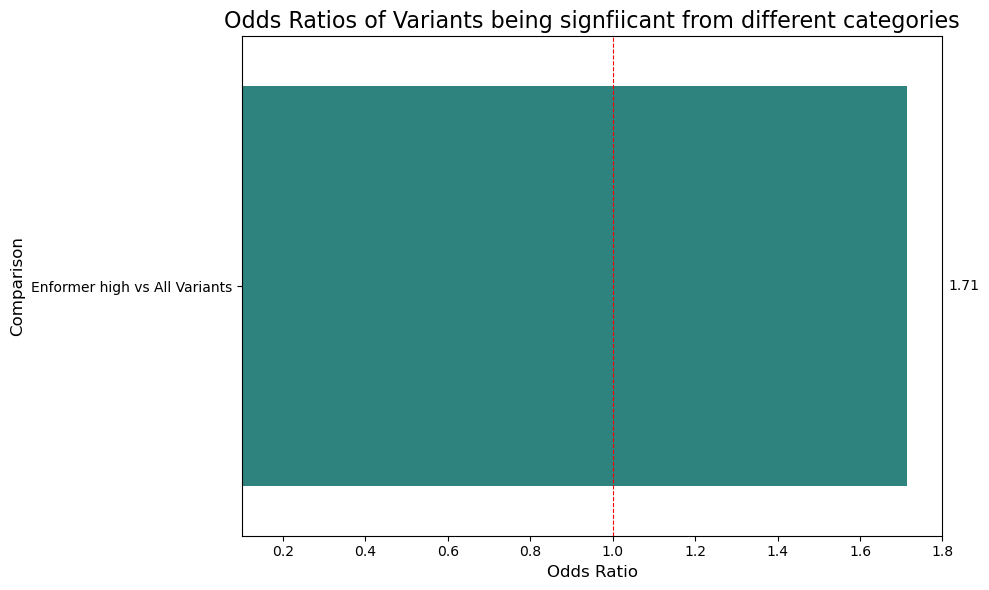

In [ ]:
data_odds = pd.DataFrame({
    'Comparison': [
        'Enformer high vs All Variants',
        'Singleton vs All Variants'
    ],
    'Odds Ratio': [odds_ratio_enformer, odds_ratio_singleton],
})

data_all_odds_sorted = data_odds.sort_values(by='Odds Ratio', ascending=True).reset_index(drop=True)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='Odds Ratio',
    y='Comparison',
    data=data_all_odds_sorted,
    palette='viridis'
)

plt.title('Odds Ratios of Variants being signfiicant from different categories', fontsize=16)
plt.xlabel('Odds Ratio', fontsize=12)
plt.ylabel('Comparison', fontsize=12)

# Add value labels on the bars, using the *new* index from the sorted DataFrame
for index, row in data_all_odds_sorted.iterrows():
    ax.text(row['Odds Ratio'] + 0.1, index, f"{row['Odds Ratio']:.2f}", color='black', ha="left", va="center")

# Add a vertical line at Odds Ratio = 1
plt.axvline(1, color='red', linestyle='--', linewidth=0.8, label='No Association (OR=1)')
# label legend outside the plot
# plt.legend(bbox_to_anchor=(1, 1), fontsize=10)

plt.xlim(0.1,1.8)
plt.tight_layout()
plt.show()


In [ ]:
import scipy.stats as stats
# Count occurrences in total dataset
total_high = (variant_info_80k_enformer["variant_group"] == "ultra-rare").sum()
total_non_high = len(variant_info_80k_enformer) - total_high
print("Number of variants considered: ", variant_info_80k_enformer.shape[0])
# Count occurrences in significant subset
sig_level = 0.1
sig_df = variant_info_80k_enformer.loc[variant_info_80k_enformer["bcalm_variant_effect_adjusted_p_value"] < sig_level].copy() # 175
print("Number of significant variants considered: ", sig_df.shape[0])

sig_high = (sig_df["variant_group"] == "ultra-rare").sum()
sig_non_high = len(sig_df) - sig_high


# Compute proportions
prop_high_sig = sig_high / len(sig_df)  # Proportion of "high" in significant rows
prop_high_total = total_high / len(variant_info_80k_enformer)  # Proportion of "high" in total dataset
# Compute enrichment factor
enrichment_factor = prop_high_sig / prop_high_total if prop_high_total > 0 else np.nan


# Contingency table for Fisher’s exact test or Chi-square test
contingency_table = [[sig_high, sig_non_high], [total_high, total_non_high]]

# Perform Fisher’s exact test (use chi2_contingency for large datasets)
odds_ratio, p_value = stats.fisher_exact(contingency_table)

# Output results
print(f"Proportion of 'ultra-rare' in significant: {sig_high / len(sig_df):.4f}")
print(f"Proportion of 'ultra-rare' in total: {total_high / len(variant_info_80k_enformer_prioritized):.4f}")
print(f"Fisher's exact test p-value: {p_value:.4e}")  # Small p-value indicates enrichment
print(f"Enrichment Factor: {enrichment_factor:.4f}")
print(f"odds Factor: {odds_ratio:.4f}")

# Create a contingency table
contingency_table = pd.DataFrame({
    'high': [sig_high, total_high],
    'not_high': [sig_non_high, total_non_high]
}, index=["Significant", "Not Significant"])

contingency_table

Number of variants considered:  46374
Number of significant variants considered:  1304
Proportion of 'ultra-rare' in significant: 0.2814
Proportion of 'ultra-rare' in total: 0.5020
Fisher's exact test p-value: 1.6121e-01
Enrichment Factor: 1.0667
odds Factor: 1.0928


,high,not_high
Significant,367,937
Not Significant,12236,34138


In [ ]:
variant_info_80k_enformer_bcalm = variant_info_80k_enformer.loc[variant_info_80k_enformer['bcalm_variant_effect_data_exists']].copy()
variant_info_80k_enformer_bcalm

In [ ]:
variant_common_and_random_sampled = variant_info_80k_enformer.loc[(variant_info_80k_enformer['variant_group'].isin(["common", "rare"])) | (variant_info_80k_enformer['enformer_class'] == "enformer_random")].copy()

In [ ]:
variant_common_and_random_sampled['variant_group'].value_counts()

variant_group
common        12145
rare           9856
ultra-rare     1786
singleton      1759
Name: count, dtype: int64

/tmp/ipykernel_293107/823045617.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = variant_df.groupby('effect_bin').agg(
/tmp/ipykernel_293107/823045617.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='effect_bin', y='proportion_variants', data=bin_summary, palette='viridis')


Summary of Common Proportion per Effect Bin:
         effect_bin  total_variants  sum_variants  proportion_variants
0  (-1.152, -0.897]               8             0             0.000000
1  (-0.897, -0.643]              23             1             0.043478
2  (-0.643, -0.389]             133             8             0.060150
3  (-0.389, -0.135]            2627           214             0.081462
4   (-0.135, 0.119]           14840          1031             0.069474
5    (0.119, 0.373]            2809           188             0.066928
6    (0.373, 0.627]             154             8             0.051948
7    (0.627, 0.881]              19             3             0.157895
8    (0.881, 1.135]               4             0             0.000000
9    (1.135, 1.389]               2             0             0.000000


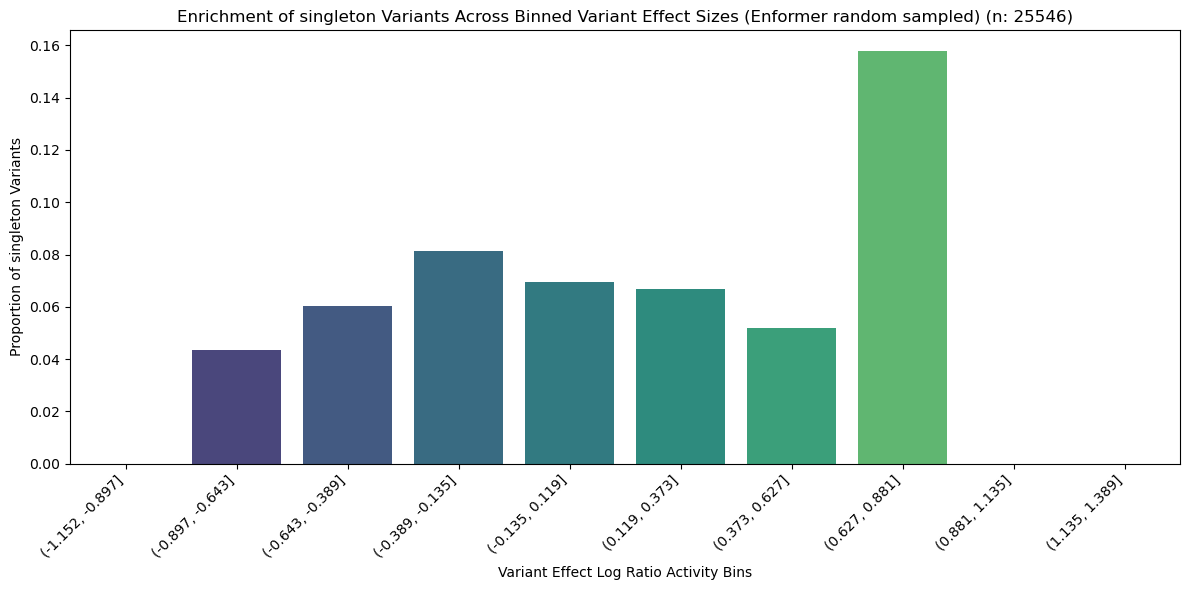

In [ ]:
plot_binned_variant_group_specific_enrichment(variant_common_and_random_sampled, variant_group_list=["singleton"], plot_title = f"Enrichment of singleton Variants Across Binned Variant Effect Sizes (Enformer random sampled)", plot_y_axis_title="Proportion of singleton Variants")

In [ ]:
variant_common_and_random_sampled['variant_group'].value_counts()

variant_group
common        12145
rare           9856
ultra-rare     1786
singleton      1759
Name: count, dtype: int64

/tmp/ipykernel_293107/823045617.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = variant_df.groupby('effect_bin').agg(
/tmp/ipykernel_293107/823045617.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='effect_bin', y='proportion_variants', data=bin_summary, palette='viridis')


Summary of Common Proportion per Effect Bin:
         effect_bin  total_variants  sum_variants  proportion_variants
0  (-1.152, -0.897]               8             7             0.875000
1  (-0.897, -0.643]              23            21             0.913043
2  (-0.643, -0.389]             133           114             0.857143
3  (-0.389, -0.135]            2627          2228             0.848116
4   (-0.135, 0.119]           14840         12775             0.860849
5    (0.119, 0.373]            2809          2421             0.861873
6    (0.373, 0.627]             154           133             0.863636
7    (0.627, 0.881]              19            16             0.842105
8    (0.881, 1.135]               4             4             1.000000
9    (1.135, 1.389]               2             2             1.000000


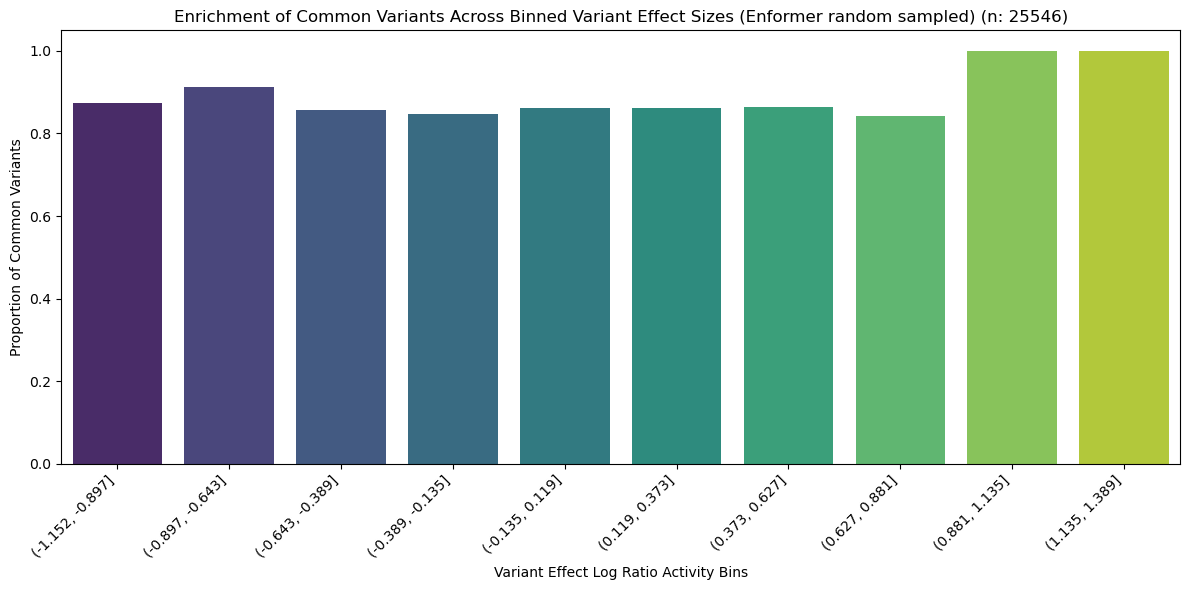

variant_group
common        12145
rare           9856
ultra-rare     1786
singleton      1759
Name: count, dtype: int64

In [ ]:
plot_binned_variant_group_specific_enrichment(variant_common_and_random_sampled, variant_group_list=["common", "rare"], plot_title = f"Enrichment of Common Variants Across Binned Variant Effect Sizes (Enformer random sampled)", plot_y_axis_title="Proportion of Common Variants")


/tmp/ipykernel_293107/1993406172.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = variant_df.groupby('effect_bin').agg(
/tmp/ipykernel_293107/1993406172.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='effect_bin', y='proportion_variants', data=bin_summary, palette='viridis')


Summary of Common Proportion per Effect Bin:
         effect_bin  total_variants  sum_variants  proportion_variants
0  (-1.347, -1.065]               8             3             0.375000
1  (-1.065, -0.785]              31             7             0.225806
2  (-0.785, -0.505]             103            23             0.223301
3  (-0.505, -0.225]            1739           459             0.263945
4  (-0.225, 0.0557]           24628          6405             0.260070
5   (0.0557, 0.336]           10778          2816             0.261273
6    (0.336, 0.616]             494           112             0.226721
7    (0.616, 0.897]              68             7             0.102941
8    (0.897, 1.177]              15             3             0.200000
9    (1.177, 1.457]               6             1             0.166667


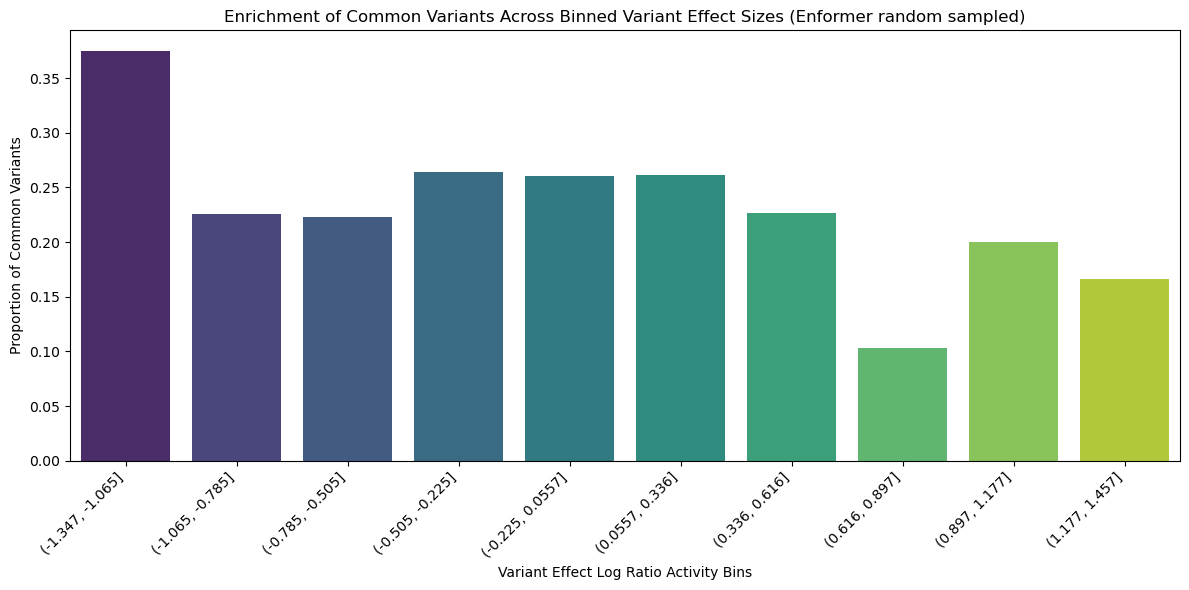

In [ ]:
plot_binned_variant_group_specific_enrichment(variant_info_80k_gnomad, variant_group_list=["common"], plot_title = f"Enrichment of Common Variants Across Binned Variant Effect Sizes (Enformer random sampled)", plot_y_axis_title="Proportion of Common Variants")

In [ ]:
variant_info_80k_gnomad

In [ ]:
variant_info_80k_enformer

In [ ]:
writing = False
if writing:
    variant_info_80k_gnomad_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/NGN2_all_variant_gnomad_info.tsv.gz"
    variant_info_80k_gnomad.to_csv(variant_info_80k_gnomad_path, sep="\t", index=None)

### Investigate the significant variants: 


In [ ]:
variant_common_and_random_sampled_sig = variant_common_and_random_sampled.loc[variant_common_and_random_sampled['bcalm_variant_effect_adjusted_p_value'] < 0.1].copy()

/tmp/ipykernel_293107/823045617.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = variant_df.groupby('effect_bin').agg(
/tmp/ipykernel_293107/823045617.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='effect_bin', y='proportion_variants', data=bin_summary, palette='viridis')


Summary of Common Proportion per Effect Bin:
         effect_bin  total_variants  sum_variants  proportion_variants
0  (-1.152, -0.897]               8             7             0.875000
1  (-0.897, -0.643]              23            21             0.913043
2  (-0.643, -0.389]              99            86             0.868687
3  (-0.389, -0.135]             225           197             0.875556
4   (-0.135, 0.119]               0             0             0.000000
5    (0.119, 0.373]             144           133             0.923611
6    (0.373, 0.627]             101            88             0.871287
7    (0.627, 0.881]              19            16             0.842105
8    (0.881, 1.135]               4             4             1.000000
9    (1.135, 1.389]               2             2             1.000000


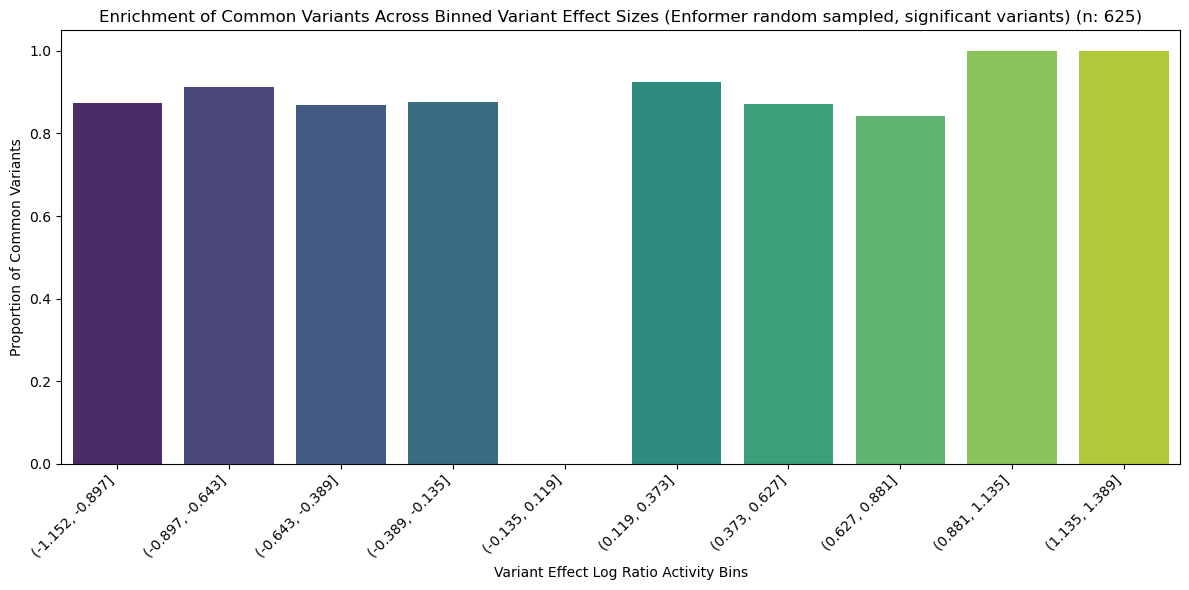

In [ ]:
plot_binned_variant_group_specific_enrichment(variant_common_and_random_sampled_sig, variant_group_list=["common"], plot_title = f"Enrichment of Common Variants Across Binned Variant Effect Sizes (Enformer random sampled, significant variants)", plot_y_axis_title="Proportion of Common Variants")

In [63]:
# variant_info_80k_enformer_measured = variant_info_80k_enformer.loc[variant_info_80k_enformer['bcalm_variant_effect_data_exists'].notna()].copy()
# variant_info_80k_enformer_measured['effect_direction'] = variant_info_80k_enformer_measured['bcalm_variant_effect_log_ratio_activity'].apply(lambda x: "pos" if x > 0 else ("neg" if x < 0 else "neutral"))
variant_common_and_random_sampled['effect_direction'] = variant_common_and_random_sampled['bcalm_variant_effect_log_ratio_activity'].apply(lambda x: "pos" if x > 0 else ("neg" if x < 0 else "neutral"))


/tmp/ipykernel_117022/3751693573.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_axis_order, rotation=45)


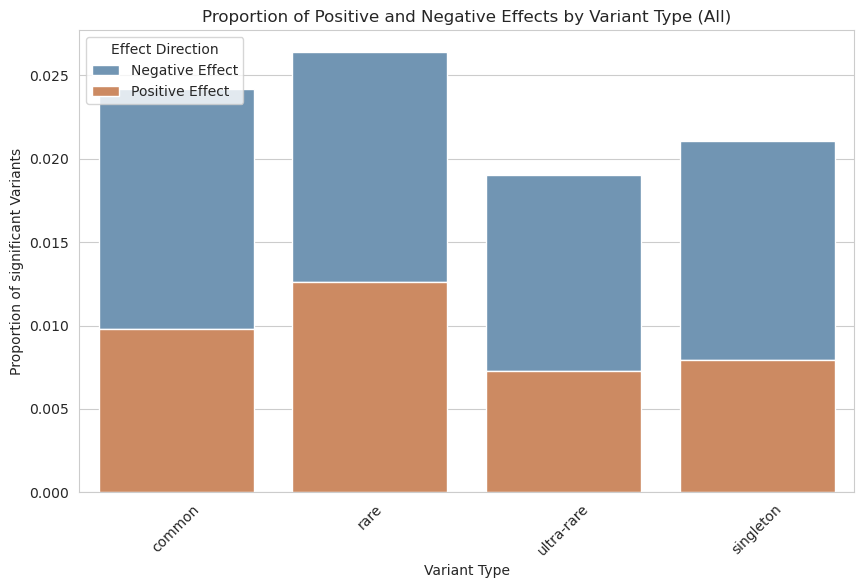

In [64]:

def plot_variant_group_barplot(matched_df, gene_set=None, x_axis_order=['common', 'rare', 'ultra-rare', 'singleton'], adjusted_p_col="bcalm_variant_effect_adjusted_p_value", sig_level = 0.1):
    """Plot the variant type proportion of significant variants with positive and negative effects"""

    if gene_set == None:
        gene_set = 'All'

    # Get the significant df
    significant_variants_df = matched_df.loc[matched_df[adjusted_p_col] < sig_level].copy()

    # Group by variant_group and effect_direction and count the occurrences
    effect_counts = significant_variants_df.groupby(['variant_group', 'effect_direction']).size().unstack(fill_value=0)
    # print(effect_counts)
    # Calculate the proportions of positive and negative effects within each variant type
    effect_proportions = effect_counts.div(effect_counts.sum(axis=1), axis=0).reset_index()
    # Add total counts and significant counts to the DataFrame for annotation
    total_variant_counts = matched_df['variant_group'].value_counts()
    effect_proportions['Total Variants'] = effect_proportions['variant_group'].map(total_variant_counts)
    significant_variant_counts = significant_variants_df['variant_group'].value_counts()
    effect_proportions['Sig Variants'] = effect_proportions['variant_group'].map(significant_variant_counts)
    # df_plot['Total Variants'] = df_plot['Variant Type'].map(total_variant_counts)
    # effect_proportions['Significant Variants'] = effect_proportions['variant_group'].map(significant_variant_counts)
        # Compute the ratio of significant variants to total variants
    effect_proportions['sig_to_total_ratio'] = effect_proportions['Sig Variants'] / effect_proportions['Total Variants']

    effect_proportions['pos_scaled'] = effect_proportions['sig_to_total_ratio'] * effect_proportions['pos']
    effect_proportions['neg_scaled'] = effect_proportions['sig_to_total_ratio'] * effect_proportions['neg']


    # # sort df
    effect_proportions = effect_proportions.set_index('variant_group').loc[x_axis_order].reset_index()
    # print(df_sorted)

    # # Plot
    fig, ax = plt.subplots(figsize=(10, 6))  # Adjust figure size for better fit
    colors = ['#70acc0', '#db2486']  # Colors for 'pos' and 'neg'
    colors = ['#6696BE', '#DE8650']  # Colors for 'pos' and 'neg'
    # # df_sorted[['positive effect', 'negative effect']].plot(kind='bar', stacked=True, color=colors)
    sns.barplot(x='variant_group', y='neg_scaled', data=effect_proportions, color=colors[0], label='Negative Effect', bottom=effect_proportions['pos_scaled'], ax=ax)
    sns.barplot(x='variant_group', y='pos_scaled', data=effect_proportions, color=colors[1], label='Positive Effect', ax=ax)
    plt.ylabel('Proportion of significant Variants')
    plt.xlabel('Variant Type')
    plt.legend(title='Effect Direction', loc='upper left', facecolor='white')
    # plt.ylim(0, 1.1)  # Slightly higher than 1 for better visualization

    # print(effect_proportions)
    # Plot
    # plt.figure(figsize=(10, 6))  # Adjust figure size for better fit
    # colors = ['#db2486', '#70acc0']  # Colors for 'pos' and 'neg'
    # effect_proportions[['pos', 'neg']].plot(kind='bar', stacked=True, color=colors)
    plt.title(f'Proportion of Positive and Negative Effects by Variant Type ({gene_set})')

    # # Add annotations
    # ax = plt.gca()
    # for p in ax.patches:
    #     width = p.get_width()
    #     height = p.get_height()
    #     x, y = p.get_xy()
    #     ax.text(x + width/2,
    #             y + height/2,
    #             f'{height:.2f}',
    #             ha='center',
    #             va='center')



    # Set the custom x-axis order if provided
    if x_axis_order is not None:
        ax.set_xticklabels(x_axis_order, rotation=45)



    # # Annotate bars with the "number_significant/total_number"
    # patch_counter = 0
    # for i, patch in enumerate(ax.patches):
    #     if patch_counter >= effect_proportions.shape[0]:
    #         break
    #     # consider x_axis_order
    #     variant_group = x_axis_order[i]
    #     # get index
    #     variant_group_idx = effect_proportions.loc[effect_proportions['variant_group'] == variant_group].index.values[0]
    #     print(variant_group_idx)
    #     patch_counter += 1
    #     # height = 1.05
    #     ax.text(
    #         patch.get_x() + patch.get_width() / 2,  # x coordinate
    #         height * 1.05,  # y coordinate
    #         # f'{effect_proportions["Total Variants"].iloc[i]}',  # annotation text
    #         f'{effect_proportions.iloc[variant_group_idx]["Sig Variants"]}/{effect_proportions.iloc[variant_group_idx]["Total Variants"]}',  # annotation text
    #         ha='center',  # horizontal alignment
    #         va='top'  # vertical alignment
    #     )


    plt.show()
    return effect_proportions

effect_proportions = plot_variant_group_barplot(variant_common_and_random_sampled, gene_set=None)
# effect_proportions = plot_variant_group_barplot(variant_info_80k_enformer_measured, gene_set=None)

In [ ]:
effect_proportions

effect_direction,variant_group,neg,pos,Total Variants,Sig Variants,sig_to_total_ratio,pos_scaled,neg_scaled
0,common,0.595238,0.404762,12145,294,0.024207,0.009798,0.014409
1,rare,0.523077,0.476923,9856,260,0.026380,0.012581,0.013799
2,ultra-rare,0.482289,0.517711,12236,367,0.029993,0.015528,0.014466
3,singleton,0.472585,0.527415,12137,383,0.031556,0.016643,0.014913


In [ ]:
variant_info_80k_enformer_gnomad = variant_info_80k_enformer.merge(gnomad_info[["ALT", "gnomad_AC", "gnomad_AF"]], on="ALT", how="inner").copy()
variant_info_80k_enformer_gnomad

In [ ]:
variant_info_80k_enformer_gnomad["variant_type"].value_counts()

In [ ]:
variant_info_80k_enformer_gnomad["variant_type"].unique()

In [ ]:
variant_info_80k_enformer_gnomad.columns